# Proyecto: Dinámica del USD/MXN en periodos de estrés y Regímenes de Mercado

Este proyecto analiza el comportamiento del tipo de cambio USD/MXN desde una perspectiva macroeconómica y cuantitativa, con énfasis en periodos de crisis global como la pandemia de COVID-19. El objetivo no es establecer relaciones rígidas o permanentes entre variables, sino entender cómo estas cambian dependiendo del entorno económico.

* No estamos tratando de encontrar una ley universal
* Estamos analizando cómo cambian las relaciones en distintos regímenes

Bajo este enfoque, la investigación se centra en la siguiente pregunta:

**¿Cómo cambia la dinámica del tipo de cambio USD/MXN y su volatilidad durante periodos de crisis global en comparación con periodos normales?**

A partir de esta, se derivan preguntas clave: si el peso mexicano se deprecia sistemáticamente en crisis, qué variables explican ese movimiento, si la volatilidad aumenta de forma estructural y si las relaciones macroeconómicas cambian entre periodos (antes, durante y después de la crisis).

El análisis se estructura en torno a la pandemia de COVID-19 como un evento de estrés extremo para los mercados financieros. Se considera el contexto macroeconómico, incluyendo la política monetaria de la Federal Reserve y el Banco de México, así como los cambios en tasas de interés, liquidez global y comportamiento de mercados emergentes.

Para capturar estos efectos, se definen distintos regímenes de análisis: un periodo base (2018–2019), un periodo de crisis concentrado (febrero a abril de 2020, incluyendo el pánico de marzo), un periodo post-crisis (2020–2021) y una ventana ampliada (2018–2026) que permite contextualizar el comportamiento de largo plazo. Esta segmentación permite comparar dinámicas bajo diferentes condiciones de mercado.

Las variables analizadas incluyen el tipo de cambio USD/MXN y su volatilidad, así como factores macroeconómicos como el diferencial de tasas entre México y Estados Unidos, tasas reales (UDIBONOS vs TIPS) e inflación. A través de estas, se busca conectar la teoría macroeconómica con el comportamiento observado en los mercados.

El núcleo del proyecto consiste en comparar cómo evolucionan estas relaciones entre regímenes. En condiciones normales, variables como las tasas pueden tener poder explicativo sobre el tipo de cambio; sin embargo, en periodos de crisis, estos vínculos pueden debilitarse o desaparecer, siendo reemplazados por factores globales como la aversión al riesgo.

El análisis de volatilidad juega un papel central, evaluando si esta aumenta de manera estructural durante episodios de estrés, lo cual es consistente con dinámicas conocidas de los mercados financieros.

Es importante destacar que:

* Los resultados no implican causalidad universal, sino comportamiento condicionado al régimen

Esto posiciona el análisis dentro de un marco realista y profesional, evitando conclusiones simplistas.

Finalmente, aunque el estudio se centra en la pandemia, su relevancia trasciende este evento específico. No se busca explicar el COVID-19 en sí, sino entender el comportamiento del mercado bajo condiciones de estrés, lo cual es aplicable a futuras crisis. **En este sentido, el proyecto también permite, de forma exploratoria, identificar qué tipo de activos podrían resultar más sensibles o atractivos bajo distintos entornos macro-financieros, sin constituir recomendaciones de inversión.**

En síntesis:

* Este trabajo analiza cómo el tipo de cambio USD/MXN y su volatilidad responden a shocks globales, comparando periodos normales y de crisis para identificar cambios en las relaciones macro-financieras.

Partimos de la siguiente *información macro-financiera*:

* Tasa real de Estados Unidos
* Tasa real de México
* Cierre diario del índice del dólar (DXY)
* Cierre diario del tipo de cambio USD/MXN
* Inflación esperada implícita de Estados Unidos a 5 y 10 años (derivada de la diferencia entre tasas nominales y reales)
* Inflación esperada implícita de México a 5 y 10 años (derivada de la diferencia entre tasas nominales y reales)

Esta selección de variables permite capturar tanto el entorno macroeconómico como la dinámica de mercado, facilitando el análisis de relaciones entre tasas, expectativas de inflación, tipo de cambio y volatilidad bajo distintos regímenes.


In [2]:
import importlib
import macro_analysis.macro_tools as rrm
importlib.reload(rrm)

import Quant_Finance_Project.capm as capm
importlib.reload(capm)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [279]:
t = rrm.load_timeseries('EXP_INF_MX10', 'Diferencia', zscore=True)
t

,Fecha,Diferencia,rate_previous,dif_bps_EXP_INF_MX10,standard_EXP_INF_MX10
0,2018-01-03,3.50,3.55,5.0,0.550518
1,2018-01-04,3.44,3.50,6.0,0.658905
2,2018-01-05,3.45,3.44,-1.0,-0.099803
3,2018-01-08,3.43,3.45,2.0,0.225357
4,2018-01-09,3.48,3.43,-5.0,-0.533351
...,...,...,...,...,...
2028,2026-03-23,5.45,5.32,-13.0,-1.400446
2029,2026-03-24,5.45,5.45,0.0,0.008584
2030,2026-03-25,5.45,5.45,0.0,0.008584
2031,2026-03-26,5.45,5.45,0.0,0.008584


In [261]:
t = rrm.load_timeseries('TIPS10', 'Tasa', zscore=True)
t

,Fecha,Tasa,rate_previous,dif_bps_TIPS10,standard_TIPS10
0,2018-01-03,0.46,0.46,0.0,0.014257
1,2018-01-04,0.45,0.46,1.0,0.208853
2,2018-01-05,0.46,0.45,-1.0,-0.180339
3,2018-01-08,0.47,0.46,-1.0,-0.180339
4,2018-01-09,0.52,0.47,-5.0,-0.958724
...,...,...,...,...,...
2056,2026-03-27,2.13,2.08,-5.0,-0.958724
2057,2026-03-30,2.04,2.13,9.0,1.765623
2058,2026-03-31,2.00,2.04,4.0,0.792642
2059,2026-04-01,2.02,2.00,-2.0,-0.374935


In [278]:

sin = rrm.synchronise_timseries_df('DXY', 'TIPS10', 'Cierre', 'Tasa', zscore=True)
print(sin)

modelo = rrm.model('DXY', 'EXP_INF_MX10')
print((modelo.y_type_column))
modelo.synchronise_timeseries()
modelo.timeseries


          Fecha       DXY    TIPS10
0    2018-01-03  0.753501  0.014257
1    2018-01-04 -0.825282  0.208853
2    2018-01-05  0.252796 -0.180339
3    2018-01-08  1.068831 -0.180339
4    2018-01-09  0.434853 -0.958724
...         ...       ...       ...
2047 2026-03-16 -1.579030  0.987238
2048 2026-03-17 -0.350790  0.792642
2049 2026-03-18  1.253702 -0.569532
2050 2026-03-19 -2.091279 -0.374935
2051 2026-03-20  1.014024 -2.515494

[2052 rows x 3 columns]
Index(['Fecha', 'BONOM10', 'UDIBONOS10', 'Diferencia'], dtype='object') EXP_INF_MX10
Diferencia
Index(['Fecha', 'Cierre', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object') DXY


,Fecha,DXY,EXP_INF_MX10
0,2018-01-03,0.753501,0.550518
1,2018-01-04,-0.825282,0.658905
2,2018-01-05,0.252796,-0.099803
3,2018-01-08,1.068831,0.225357
4,2018-01-09,0.434853,-0.533351
...,...,...,...
2020,2026-03-13,1.494309,-1.942381
2021,2026-03-17,-0.350790,-2.592702
2022,2026-03-18,1.253702,0.008584
2023,2026-03-19,-2.091279,0.008584


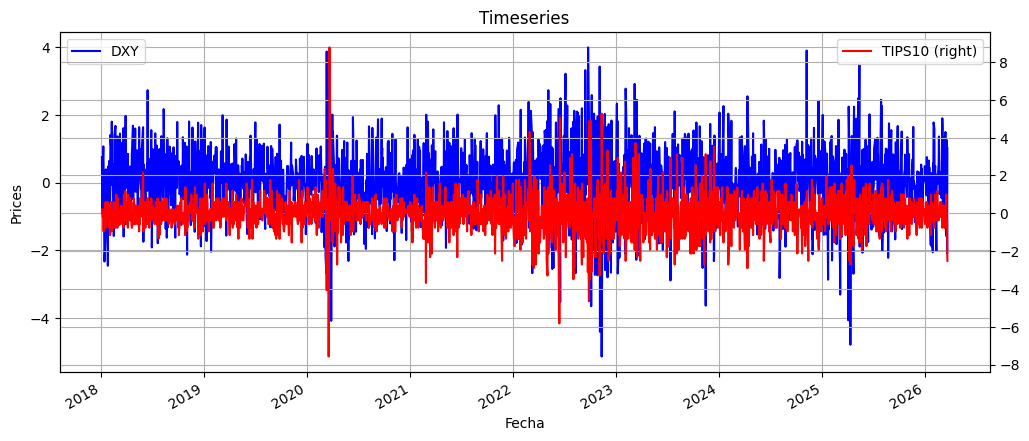

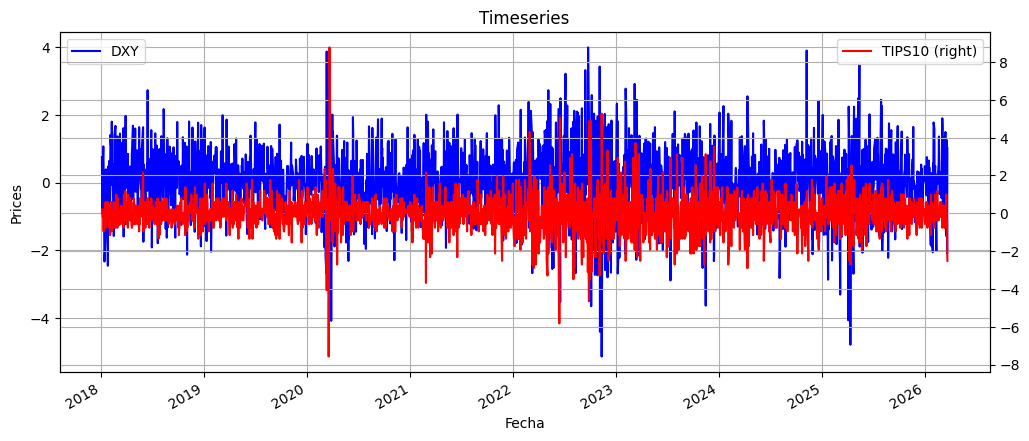

In [227]:
rrm.plot_timeseries(sin, 'DXY', 'TIPS10')
modelo.plot_timeseries()

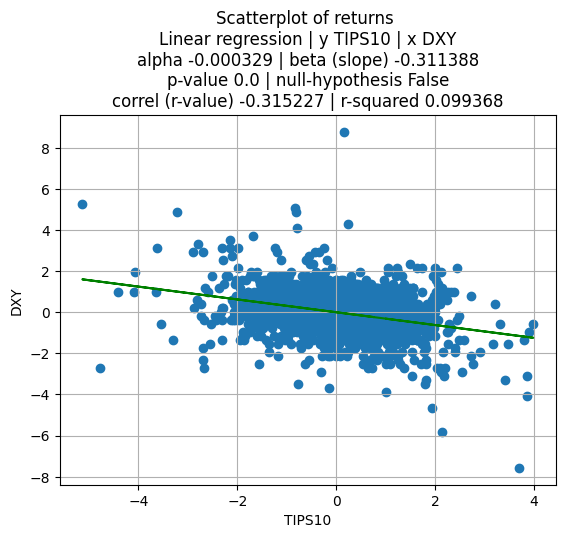

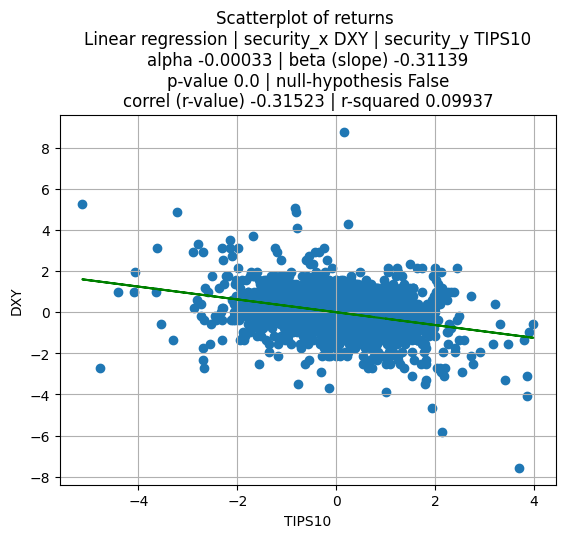

In [226]:
rrm.compute_linear_reg(sin, x= 'DXY', y = 'TIPS10')

modelo.compute_linear_reg()
modelo.r_squared
modelo.plot_linear_reg()

          Fecha  TIPS5  TIPS10
0    2018-01-03   -3.0     0.0
1    2018-01-04    3.0     1.0
2    2018-01-05    1.0    -1.0
3    2018-01-08   -4.0    -1.0
4    2018-01-09    0.0    -5.0
...         ...    ...     ...
2056 2026-03-27    2.0    -5.0
2057 2026-03-30   10.0     9.0
2058 2026-03-31    2.0     4.0
2059 2026-04-01   -4.0    -2.0
2060 2026-04-02    5.0     5.0

[2061 rows x 3 columns]


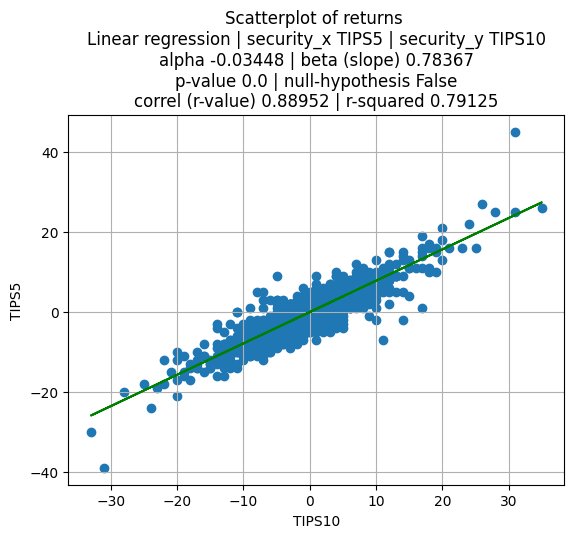

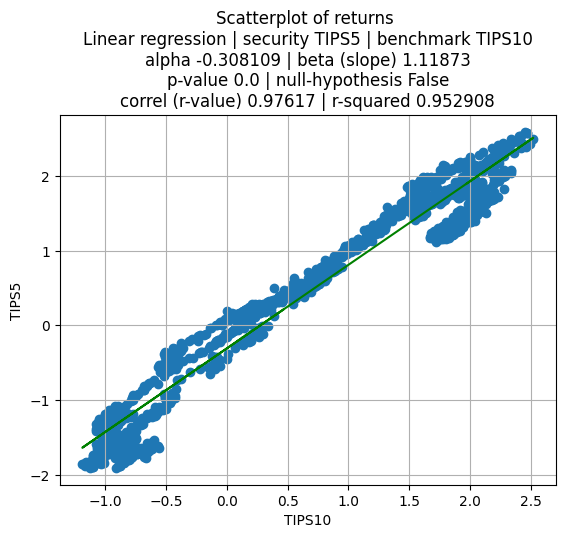

In [243]:

sin_2 = rrm.synchronise_timseries_df('TIPS5', 'TIPS10', 'Tasa', 'Tasa', zscore=False)
print(sin_2)

modelo_2 = rrm.model('TIPS5', 'TIPS10')
modelo_2.synchronise_timeseries()
modelo_2.timeseries
modelo_2.compute_linear_reg()
modelo_2.plot_linear_reg()

#From: 2018-01-03 00:00:00 - To: 2026-03-27 00:00:00
# Beta: 1.018407, Corr: 0.798069, R2: 0.636915

m = capm.model('TIPS5', 'TIPS10', 6)
m.synchronise_timeseries()
m.compute_linear_reg(target_column='closing')
m.plot_linear_reg()

# Análisis de Estados Unidos
Para el caso de Estados Unidos, trabajamos con TIPS a 5 y 10 años, además de los U.S. T Notes (DGS) de 5 y 10 años, en adición a nuestros índices de interés, que son el principal *scoop* del proyecto.

*Cabe mencionar que todo el código y nuestras herramientas permiten de forma dinámica agregar cualquier varialbe nueva que sea de nuestro interés.*

# Consistencia de expectativas inflacionarias: análisis 5Y vs 10Y de Estados Unidos

## Diferenciación por horizonte: expectativas de inflación a 5 y 10 años

Con el objetivo de profundizar en el análisis de la dinámica macro-financiera, se extiende el estudio de inflación esperada incorporando dos horizontes temporales: mediano plazo (5 años) y largo plazo (10 años).

Esta distinción es relevante, ya que las expectativas de inflación no son homogéneas a lo largo de la curva temporal. Mientras que los horizontes de menor plazo tienden a ser más sensibles a condiciones económicas actuales, política monetaria y episodios de estrés, los horizontes de largo plazo suelen reflejar expectativas más estables y ancladas.

Bajo este enfoque, se analiza si la relación entre tasas reales e inflación esperada presenta comportamientos diferenciados dependiendo del horizonte considerado, particularmente durante el episodio de crisis asociado a 2020.

Este análisis permite evaluar no solo la existencia de cambios en las relaciones macro-financieras, sino también si dichos cambios son homogéneos a lo largo de la estructura temporal de expectativas.


Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/EXP_INF_USA10.csv


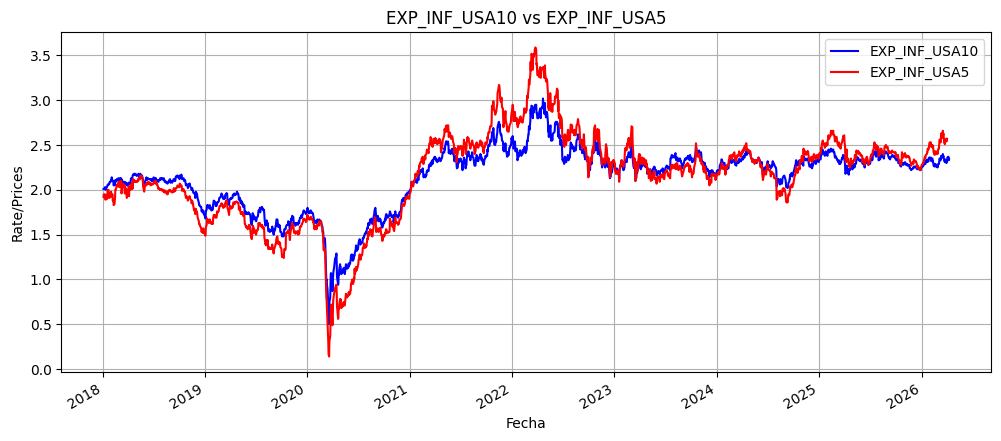

In [305]:
# Obtener la inflación esperada implícita de Estados Unidos a 5 años (derivada de la diferencia entre tasas nominales y reales)
expected_inflation_usa_5 = rrm.synchronise_timseries_df('DGS5', 'TIPS5', 'Tasa', 'Tasa', dif = True)
# rrm.cargar_archivo(expected_inflation_usa_5, archivo = 'EXP_INF_USA5')

# Obtener la inflación esperada implícita de Estados Unidos a 10 años (derivada de la diferencia entre tasas nominales y reales)
expected_inflation_usa_10 = rrm.synchronise_timseries_df('DGS10', 'TIPS10', 'Tasa', 'Tasa', dif = True)
rrm.cargar_archivo(expected_inflation_usa_10, archivo = 'EXP_INF_USA10')


rrm.plot_two_timeseries('EXP_INF_USA10', 'EXP_INF_USA5', 'Diferencia', 'Diferencia', titulo = "EXP_INF_USA10 vs EXP_INF_USA5", secondary_y=False)

In [126]:
m = capm.model('EXP_INF_USA10', 'EXP_INF_USA5', 6)
m.synchronise_timeseries()
m.compute_linear_reg('closing')

print(f"From: {m.timeseries['date'].min()} - To: {m.timeseries['date'].max()}")        
print(f"Beta: {m.beta}, Corr: {m.correlation}, R2: {m.r_squared}")

From: 2018-01-03 00:00:00 - To: 2026-03-26 00:00:00
Beta: 0.693336, Corr: 0.979909, R2: 0.960221


# Análisis de expectativas de inflación por horizonte temporal

Con el objetivo de complementar el análisis previo, se incorpora el estudio de la inflación esperada considerando distintos horizontes temporales, específicamente a 5 y 10 años. Esta extensión permite evaluar si las dinámicas observadas en el comportamiento macro-financiero son consistentes a lo largo de la estructura temporal de expectativas o si presentan diferencias relevantes dependiendo del plazo considerado.

En particular, se evalúan correlaciones, ajustes lineales y pruebas de significancia, así como la posible presencia de cambios estructurales en distintos periodos del tiempo.

El propósito de este análisis no es únicamente identificar relaciones entre variables, sino entender cómo estas pueden variar en función del horizonte temporal, permitiendo distinguir entre dinámicas de corto, mediano y largo plazo. Esto resulta clave para interpretar el comportamiento del mercado, ya que las expectativas inflacionarias pueden responder de manera diferenciada ante cambios en el entorno económico, política monetaria y episodios de estrés financiero.

En este sentido, el análisis por horizontes introduce una nueva dimensión al estudio, permitiendo evaluar si las relaciones entre información macro-financieras son homogéneas o si, por el contrario, presentan comportamientos distintos dependiendo del plazo considerado.


# Análisis Exploratorio y Evidencia Empírica Inicial - Enfoque sobre EUA a 5 años

Con el objetivo de comprender la dinámica general de las variables analizadas, se inicia con un análisis exploratorio utilizando la totalidad de los datos disponibles (2018–2026). Este enfoque permite establecer un comportamiento base o “normal” del mercado, previo a cualquier evento de estrés.

En una primera etapa, se analizan visualmente distintas combinaciones entre variables macro-financieras, tales como:

* Tasa real vs tasa nominal (TIPS vs DGS)
* Tasa real de Estados Unidos vs inflación
* Tasa real de Estados Unidos vs DXY y USD/MXN
* Inflación esperada vs DXY y USD/MXN


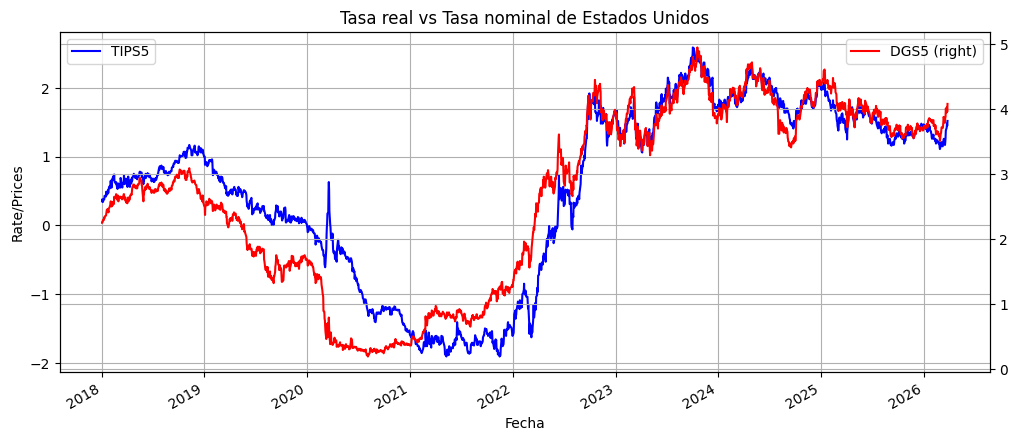

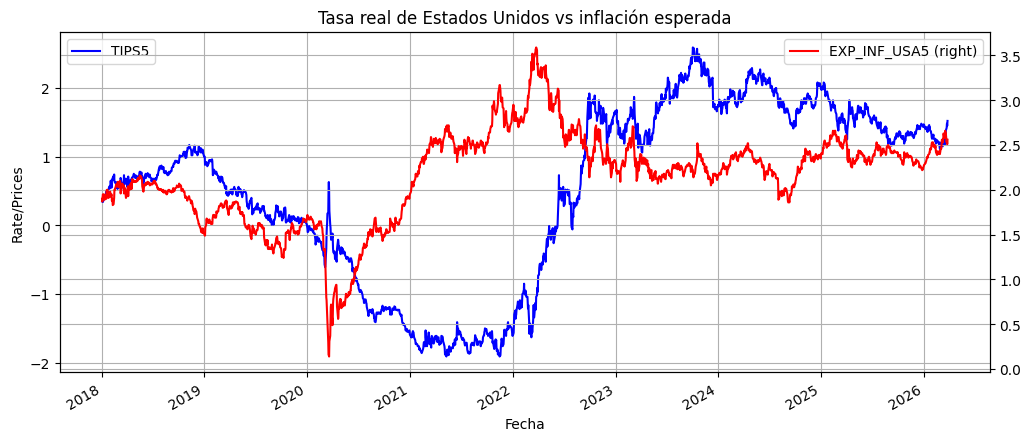

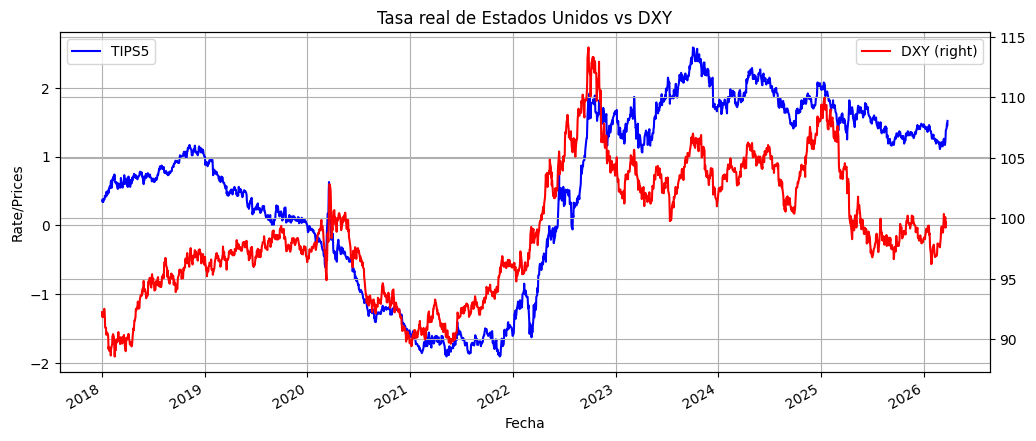

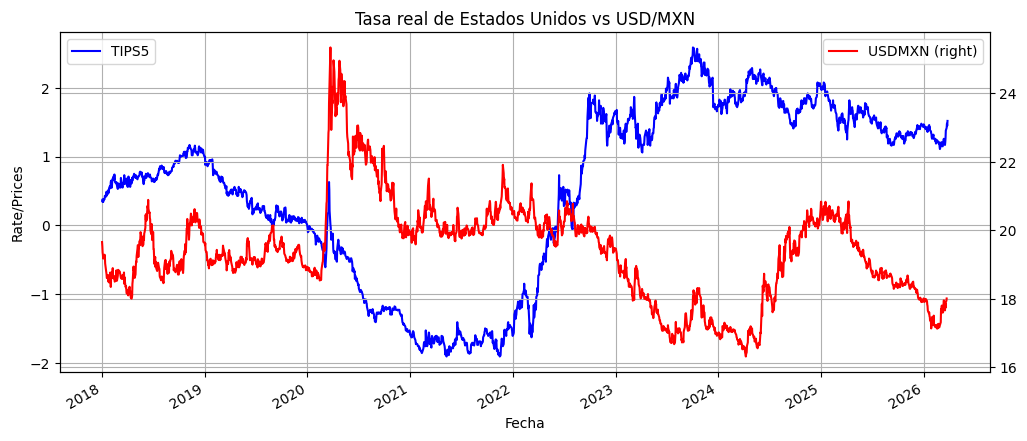

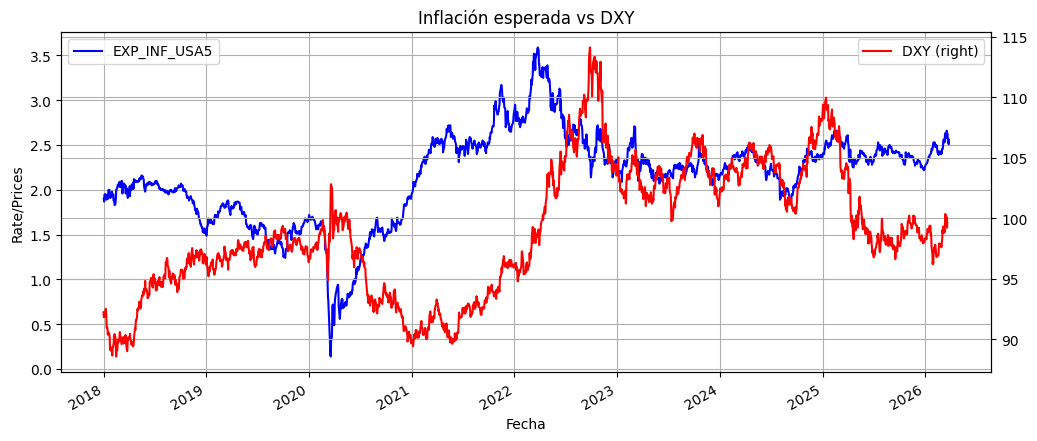

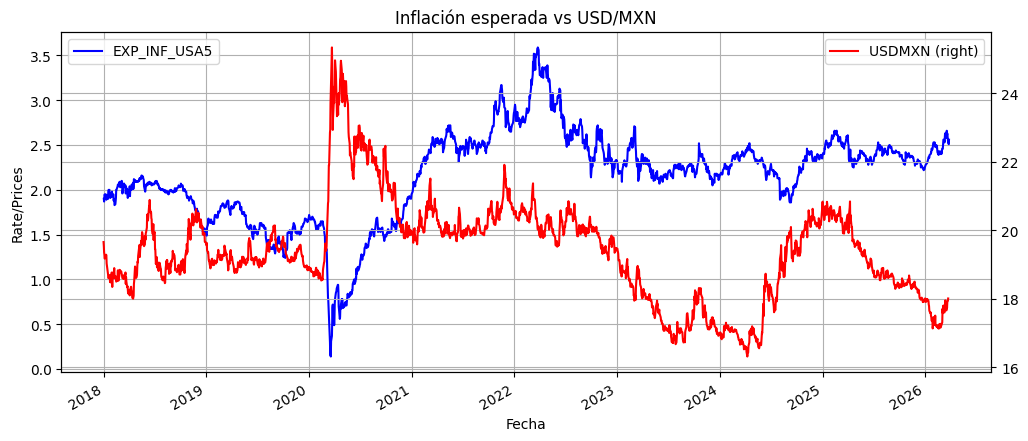

In [162]:
rrm.plot_two_timeseries('TIPS5', 'DGS5', 'Tasa', 'Tasa', titulo = 'Tasa real vs Tasa nominal de Estados Unidos')
rrm.plot_two_timeseries('TIPS5', 'EXP_INF_USA5', 'Tasa', 'Diferencia', titulo = 'Tasa real de Estados Unidos vs inflación esperada') # from_date='2020-01-01', to_date='2020-12-01
rrm.plot_two_timeseries('TIPS5', 'DXY', 'Tasa', 'Cierre', titulo = 'Tasa real de Estados Unidos vs DXY')
rrm.plot_two_timeseries('TIPS5', 'USDMXN', 'Tasa', 'Cierre', titulo = 'Tasa real de Estados Unidos vs USD/MXN')
rrm.plot_two_timeseries('EXP_INF_USA5', 'DXY', 'Diferencia', 'Cierre', titulo = 'Inflación esperada vs DXY')
rrm.plot_two_timeseries('EXP_INF_USA5', 'USDMXN', 'Diferencia', 'Cierre', titulo = 'Inflación esperada vs USD/MXN')



A nivel gráfico, algunas de estas combinaciones sugieren la posible existencia de casos con relaciones proporcionales y casos con relaciones inversas, tanto en periodos limitados así como en toda la *timeserie*; sin embargo, dichas asociaciones no resultan concluyentes ni consistentemente visibles a lo largo del tiempo. Esto motiva una evaluación más formal de la relación entre variables.

Para ello, se emplea un análisis de correlación con el Coeficiente de correlación de Pearson, cuyos valores oscilan entre -1 y 1, junto con **modelos de regresión lineal simple** y gráficos de dispersión para los distintos horizontes temporales.

# Consideraciones metodológicas: niveles vs variaciones
Trabajar con las variaciones diarias (retornos) de las variables es común en contextos de alta frecuencia o análisis de corto plazo, su aplicación en variables macroeconómicas como tasas de interés e inflación esperada puede resultar problemática, ya que introduce un alto nivel de ruido y dificulta la identificación de relaciones estructurales.

En este sentido, se optó por realiza el análisis principal utilizando directamente los niveles de las variables (yields), lo que permite capturar de manera más adecuada las relaciones económicas subyacentes entre ellas.

No se rechaza el enfoque de poder trabajar posteriormente con variaciones para analizar cambios marginales de corto plazo, pero inicialmente el enfoque será centrarse en la relación entre variables en términos de equilibrio macro-financiero.

# Evaluación estadística 
Los siguientes resultados se obtendrán usando la inflación esperada implícita de Estados Unidos a 5 años bajo diferentes periodos de interés.

In [58]:
benchmarks = ['EXP_INF_USA5', 'DXY', 'USDMXN']
securities = ['TIPS5', 'EXP_INF_USA5']

## Observaciones del periodo 2018-2026
Bajo inflación esperada implícita de Estados Unidos a 5 años

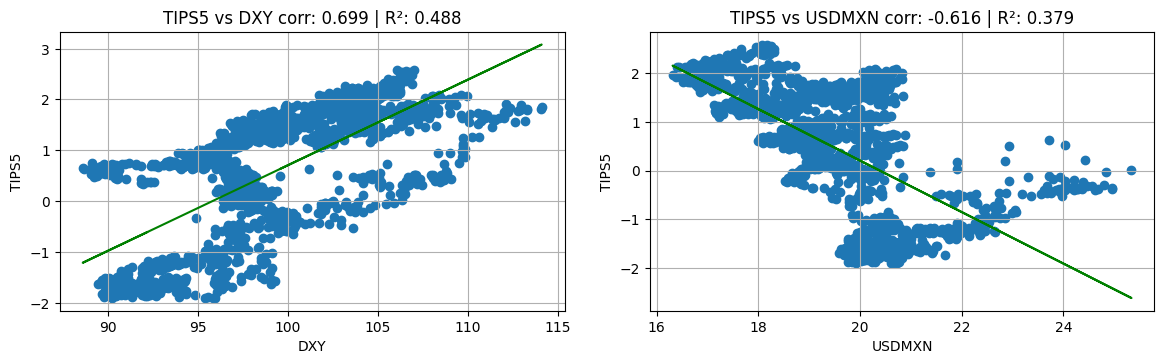

,security,benchmark,beta,correlation,r2
1,TIPS5,DXY,0.168367,0.698843,0.488382
3,EXP_INF_USA5,DXY,0.021499,0.221917,0.049247
0,TIPS5,EXP_INF_USA5,0.119590,0.048301,0.002333
4,EXP_INF_USA5,USDMXN,-0.104245,-0.300312,0.090187
2,TIPS5,USDMXN,-0.529610,-0.616025,0.379487


In [ ]:
results = []
models_to_plot = []

for sec in securities:
    for bench in benchmarks:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries()
        m.compute_linear_reg(target_column='closing')
        
        results.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)
    plt.show()

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='correlation', ascending=False)

df_results


## Observaciones del periodo 2019–2021
Bajo inflación esperada implícita de Estados Unidos a 5 años

In [76]:
results = []
models_to_plot = []

for sec in securities:
    for bench in benchmarks:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries(from_date='2019-01-01', to_date='2021-12-31')
        m.compute_linear_reg('returns')
        results.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)
    plt.show()

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='correlation', ascending=False)

df_results

No hay modelos que cumplan el criterio para graficar


,security,benchmark,beta,correlation,r2
1,TIPS5,DXY,11.251624,0.089781,0.008061
2,TIPS5,USDMXN,-3.554643,-0.068251,0.004658
3,EXP_INF_USA5,DXY,-1.288161,-0.072900,0.005314
0,TIPS5,EXP_INF_USA5,-0.717186,-0.103370,0.010685
4,EXP_INF_USA5,USDMXN,-1.078032,-0.145132,0.021063


## Observaciones del periodo de mayor estrés (abril de 2020 - diciembre 2020)
Bajo inflación esperada implícita de Estados Unidos a 5 años

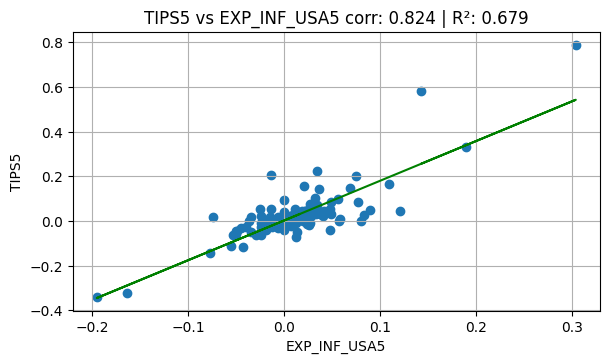

,security,benchmark,beta,correlation,r2
0,TIPS5,EXP_INF_USA5,1.777217,0.823963,0.678915
1,TIPS5,DXY,1.137233,0.042182,0.001779
2,TIPS5,USDMXN,0.130057,0.014528,0.000211
3,EXP_INF_USA5,DXY,-1.000072,-0.082543,0.006813
4,EXP_INF_USA5,USDMXN,-0.492472,-0.119108,0.014187


In [61]:
results = []
models_to_plot = []

for sec in securities:
    for bench in benchmarks:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries(from_date='2020-04-01', to_date='2020-12-31')
        m.compute_linear_reg()
        results.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)
# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)
    plt.show()

# Presentar datos en un df
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='correlation', ascending=False)

df_results

### Resultados del análisis 

Una vez capturada las relaciones económicas subyacentes entre tasas reales, inflación esperada y variables financieras, los resultados muestran que bajo este enfoque, emergen patrones claros y consistentes particularmente en periodos de estabilidad, mientras que durante episodios de crisis estas relaciones tienden a debilitarse o desaparecer, reflejando la disrupción del entorno económico.

### Interpretación económica de resultados 

El análisis en niveles (yields) permite identificar patrones consistentes en la relación entre variables macro-financieras, particularmente en condiciones normales de mercado, así como su disrupción en periodos de estrés. Los resultados muestran que emergen patrones claros y consistentes particularmente en periodos de estabilidad, mientras que durante episodios de crisis estas relaciones tienden a debilitarse o desaparecer, reflejando la disrupción del entorno económico.

### Periodo base (2018–2020): presencia de estructura macro-financiera

Durante este periodo se observan relaciones claras y económicamente coherentes:

* **El fortalecimiento del dólar (DXY) está correlacionado con el aumento de las tasas reales (TIPS)**
  Una correlación positiva elevada (0.70) sugiere que un fortalecimiento del dólar está asociado con un entorno de tasas reales más altas en Estados Unidos. Esto es consistente con condiciones de mayor atractivo relativo de activos denominados en dólares.

* **El tipo de cambio USD/MXN sube, mientras que las tasas reales bajan.**
  La correlación negativa (-0.61) indica que una depreciación del peso mexicano está asociada con caídas en tasas reales, lo que puede interpretarse como una salida de capitales o menor atractivo relativo de activos en economías emergentes.

* **Inflación esperada y tasas reales**
  La baja correlación observada sugiere que, en condiciones normales, ambos componentes se ajustan de forma relativamente independiente, reflejando un equilibrio más estable entre expectativas y condiciones financieras.

---

### Periodo de transición (2019–2021): debilitamiento de relaciones

Al incorporar el periodo de crisis, las relaciones previamente identificadas se deterioran de forma significativa:

* Las correlaciones entre variables clave se reducen a niveles cercanos a cero
* La capacidad explicativa de los modelos (r_squared) disminuye considerablemente

Esto sugiere que, en presencia de alta incertidumbre, los vínculos tradicionales entre variables dejan de operar con normalidad. En este entorno, factores como la liquidez global, intervenciones de política monetaria y choques exógenos dominan el comportamiento del mercado.

---

### Periodo de pánico (abril–diciembre 2020): emergencia de dinámicas específicas

Durante el episodio de mayor estrés se observa un fenómeno particular:

* **Existe una alta correlación (aproximadamente 0.82) entre las tasas reales y la inflación esperada**
  Aparece una relación fuerte y dominante entre ambas variables, lo que sugiere que los movimientos en tasas reales están altamente influenciados por cambios en expectativas de inflación.

* El resto de las relaciones (DXY, USD/MXN) pierden completamente su poder explicativo
  Esto indica que, en este periodo, los mecanismos tradicionales de transmisión (tipo de cambio, dólar) dejan de ser determinantes principales.

En este contexto, el mercado parece estar **dominado por ajustes internos en expectativas macroeconómicas**, más que por relaciones externas entre activos.

---

A partir de estos resultados, es posible extraer las siguientes interpretaciones aplicables al análisis del entorno actual:

* En condiciones normales, movimientos en el dólar o en tasas reales pueden ser interpretados como señales consistentes del entorno macro-financiero. Por ejemplo:

    * Un fortalecimiento del dólar acompañado de un aumento en tasas reales *sugiere condiciones restrictivas/dólar fuerte estructural* o mayor atractivo relativo de activos en USD.
    * Una depreciación del MXN junto con caídas en tasas reales puede reflejar salida de capitales o deterioro en expectativas.

* En entornos de crisis, estas señales pierden confiabilidad. La desaparición de correlaciones indica que los mercados dejan de responder a relaciones estructurales y **pasan a reaccionar a factores de corto plazo, como liquidez o eventos extremos.**

* La aparición de una relación dominante (como tasas reales e inflación esperada) sugiere que, bajo estrés, el mercado tiende a simplificar su dinámica, concentrándose en un número reducido de variables clave.

En conjunto, estos hallazgos permiten entender que la interpretación de los mercados debe adaptarse al régimen en el que se encuentra. Las señales que son válidas en periodos de estabilidad pueden dejar de serlo en momentos de crisis, *lo que resalta la importancia de identificar el contexto antes de extraer conclusiones o tomar decisiones*.


En conjunto, estos resultados sugieren que:

* En condiciones normales, existen relaciones macro-financieras relativamente estables cuando se analizan en niveles.
* Durante episodios de crisis, estas relaciones tienden a debilitarse o romperse, reflejando disrupciones en el funcionamiento del mercado.
* En ciertos casos específicos, pueden emerger relaciones/factores de corto plazo, como liquidez o eventos extremos particulares en periodos de estrés, **lo que indica que no todas las dinámicas desaparecen, sino que algunas se intensifican o se vuelven dominantes temporalmente.**

Este hallazgo refuerza la idea de que las relaciones entre variables no son estáticas, sino que dependen del régimen de mercado, y que el uso de niveles permite identificar con mayor claridad estas dinámicas estructurales en comparación con el análisis basado en variaciones.


# Validación estadística
Las pruebas estadísticas se utilizan de manera puntual para validar los hallazgos más relevantes del análisis, reforzar una historia, evitando una sobrecarga de inferencia que pueda distraer de la interpretación económica principal.

## Pruebas de significancia


### Prueba de cambio estructural: Chow Test

Con el objetivo de evaluar si la relación entre las variables cambia de forma significativa en el tiempo, se emplea la prueba de Chow. Esta prueba permite identificar la presencia de un quiebre estructural en un modelo de regresión, comparando si los parámetros estimados antes y después de un punto específico difieren de manera significativa.

La hipótesis nula (H_0) establece que no existe cambio estructural, es decir, que la relación entre las variables se mantiene constante en todo el periodo analizado. Por otro lado, la hipótesis alternativa (H_1) plantea que sí existe un cambio estructural, lo que implica que los coeficientes del modelo difieren entre subperiodos.

En este contexto, el test permite determinar si el periodo posterior al shock de mercado (abril de 2020) presenta una dinámica distinta en comparación con el periodo previo, validando formalmente la presencia de distintos regímenes en el comportamiento de las variables.

*El punto de quiebre utilizado en la prueba de Chow se define a partir de un evento económico identificado exógenamente (la crisis de COVID-19), evitando la selección de periodos basada en los resultados estadísticos. Esto permite mantener la validez del análisis y reducir el riesgo de sesgo por sobreajuste.*


Hay evidencia de cambio estructural (rechazamos H0)


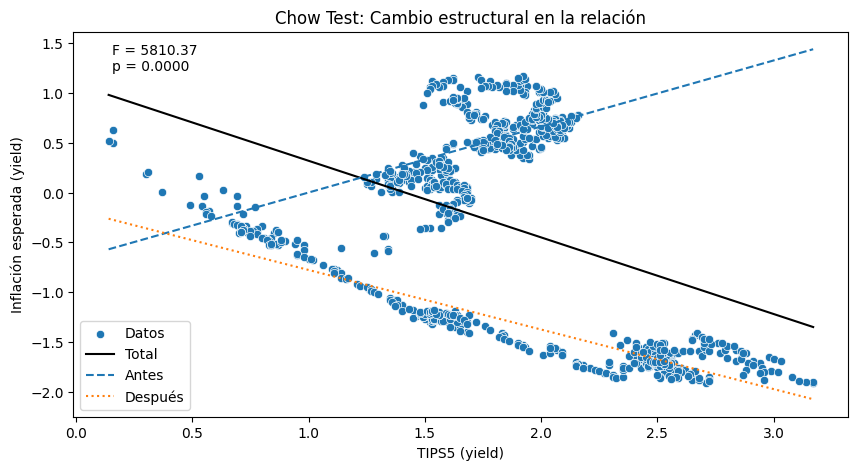

In [88]:
from scipy.stats import f

break_date = '2020-04-01'

# MODELO TOTAL
m_total = capm.model('TIPS5', 'EXP_INF_USA5', 20)
m_total.synchronise_timeseries(from_date='2018-01-01', to_date='2021-12-31')
m_total.compute_linear_reg(target_column='closing')

y_hat_total = m_total.alpha + m_total.beta * m_total.x
RSS_total = np.sum((m_total.y - y_hat_total)**2)
n_total = len(m_total.y)

# MODELO ANTES DEL QUIEBRE
m_1 = capm.model('TIPS5', 'EXP_INF_USA5', 6)
m_1.synchronise_timeseries(from_date='2018-01-01', to_date=break_date)
m_1.compute_linear_reg(target_column='closing')

y_hat_1 = m_1.alpha + m_1.beta * m_1.x
RSS_1 = np.sum((m_1.y - y_hat_1)**2)
n1 = len(m_1.y)

# MODELO DESPUES DEL QUIEBRE
m_2 = capm.model('TIPS5', 'EXP_INF_USA5', 20)
m_2.synchronise_timeseries(from_date=break_date, to_date='2021-12-31')
m_2.compute_linear_reg(target_column='closing')

y_hat_2 = m_2.alpha + m_2.beta * m_2.x
RSS_2 = np.sum((m_2.y - y_hat_2)**2)
n2 = len(m_2.y)

# CALCULO DEL ESTADÍSTICO
k = 2  # constante + 1 variable

F = ((RSS_total - (RSS_1 + RSS_2)) / k) / ((RSS_1 + RSS_2) / (n1 + n2 - 2*k))

# P VALUE
p_value_chow = 1 - f.cdf(F, k, n1 + n2 - 2*k)

# Interpretación
if p_value_chow < 0.05:
    print("Hay evidencia de cambio estructural (rechazamos H0)")
else:
    print("No hay evidencia suficiente de cambio estructural")

# Visual
plt.figure(figsize=(10,5))

# scatter (usa returns, no close si quieres consistencia con el modelo)
sns.scatterplot(x=m_total.x, y=m_total.y, label='Datos')

# rango de x
x_vals = np.linspace(min(m_total.x), max(m_total.x), 100)

# línea total
y_vals_total = m_total.alpha + m_total.beta * x_vals
plt.plot(x_vals, y_vals_total, color='black', label='Total')

# línea antes
y_vals_1 = m_1.alpha + m_1.beta * x_vals
plt.plot(x_vals, y_vals_1, linestyle='--', label='Antes')

# línea después
y_vals_2 = m_2.alpha + m_2.beta * x_vals
plt.plot(x_vals, y_vals_2, linestyle=':', label='Después')

plt.legend()
plt.title("Chow Test: Cambio estructural en la relación")
plt.xlabel("TIPS5 (yield)")
plt.ylabel("Inflación esperada (yield)")

plt.text(0.05, 0.9, f"F = {F:.2f}\np = {p_value_chow:.4f}", transform=plt.gca().transAxes)

plt.show()


## Evidencia de cambio estructural en niveles - Inflación esperada a 10 años

En primer lugar, al analizar el periodo amplio de 2018 a 2021, se observa la existencia de relaciones significativas entre las variables. En particular, destaca una correlación positiva relevante entre tasas reales (TIPS) y el dólar (DXY), así como una relación negativa entre tasas reales y el tipo de cambio (USDMXN). Estos resultados sugieren un entorno macroeconómico relativamente estable, en el cual las tasas reales funcionan como un ancla del sistema financiero: mayores tasas reales se asocian con un fortalecimiento del dólar y una apreciación relativa de economías emergentes como México.

Sin embargo, al ampliar el análisis al periodo 2019–2021, que incluye la disrupción generada por la pandemia, las relaciones anteriores se debilitan considerablemente. Las correlaciones se aproximan a cero y las pendientes pierden estabilidad, reflejando un entorno de transición en el que los vínculos tradicionales entre variables dejan de ser claros. Este comportamiento es consistente con episodios de incertidumbre, donde múltiples factores afectan simultáneamente a los mercados, generando una aparente pérdida de estructura.

Este cambio en la dinámica es reforzado por la prueba de Chow, la cual permite identificar la existencia de un quiebre estructural en la relación analizada. Al rechazar la hipótesis nula de estabilidad de parámetros (p-value aprox. 0.00),**se confirma que la relación entre tasas reales e inflación esperada no es constante en el tiempo, sino que depende del contexto económico**. 
El análisis gráfico complementa este resultado, mostrando diferencias claras en la pendiente y dispersión de los datos antes y después del shock.

---

**En conjunto, estos hallazgos sugieren que las relaciones macro-financieras no desaparecen durante episodios de crisis, sino que se reconfiguran.** 

* *En condiciones normales*, las tasas reales están estrechamente vinculadas con variables externas como el dólar y el tipo de cambio, reflejando flujos de capital y diferenciales de tasas. 
* *En periodos de estrés*, esta estructura cambia y las tasas reales pasan a estar dominadas por las expectativas de inflación, convirtiéndose en un reflejo directo de la percepción del mercado sobre el entorno económico futuro.

Este resultado tiene implicaciones importantes para la interpretación de los mercados financieros. 

En síntesis, la evidencia empírica muestra que el mercado no pierde estructura durante los episodios de crisis, sino que cambia la naturaleza de sus relaciones. Este hallazgo refuerza la idea central del proyecto: las dinámicas macro-financieras son dependientes del régimen y deben analizarse en función del contexto económico en el que se desarrollan.

*Bajo este horizonte de 5 años, se indica que no es adecuado utilizar modelos lineales estáticos para describir relaciones que dependen del régimen económico.*

# Evaluación estadística - Horizonte de 10 años

In [206]:
benchmarks_10 = ['EXP_INF_USA10', 'DXY', 'USDMXN']
securities_10 = ['TIPS10', 'EXP_INF_USA10']

## Observaciones del periodo 2018-2026
Bajo inflación esperada implícita de Estados Unidos a 10 años

,security,benchmark,beta,correlation,r2
1,TIPS10,DXY,0.138967,0.662091,0.438365
0,TIPS10,EXP_INF_USA10,0.910717,0.298574,0.089147
3,EXP_INF_USA10,DXY,0.018568,0.271039,0.073462
4,EXP_INF_USA10,USDMXN,-0.099675,-0.405683,0.164579
2,TIPS10,USDMXN,-0.475907,-0.634744,0.402900


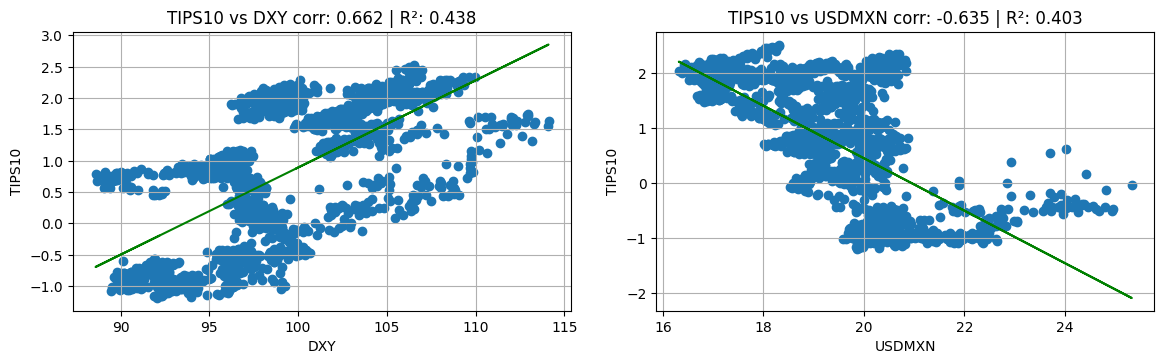

In [210]:
results_10 = []
models_to_plot = []

for sec in securities_10:
    for bench in benchmarks_10:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries()
        m.compute_linear_reg(target_column='closing')
        
        results_10.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })

        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)

df_results_10 = pd.DataFrame(results_10)
df_results_10 = df_results_10.sort_values(by='correlation', ascending=False)

df_results_10


## Observaciones del periodo 2019–2021 
Bajo inflación esperada implícita de Estados Unidos a 10 años

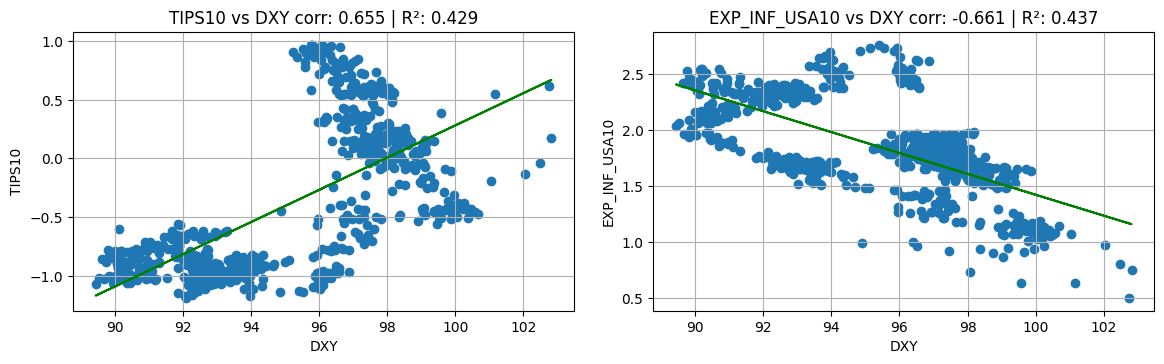

,security,benchmark,beta,correlation,r2
1,TIPS10,DXY,0.137342,0.655098,0.429153
0,TIPS10,EXP_INF_USA10,-0.573901,-0.387330,0.150025
4,EXP_INF_USA10,USDMXN,-0.124051,-0.410951,0.168880
2,TIPS10,USDMXN,-0.198884,-0.445412,0.198392
3,EXP_INF_USA10,DXY,-0.093143,-0.661134,0.437099


In [211]:
results_10 = []
models_to_plot = []

for sec in securities_10:
    for bench in benchmarks_10:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries(from_date='2019-01-01', to_date='2021-12-31')
        m.compute_linear_reg(target_column='closing')
        
        results_10.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })

        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)
    plt.show()

df_results_10 = pd.DataFrame(results_10)
df_results_10 = df_results_10.sort_values(by='correlation', ascending=False)

df_results_10


## Observaciones del periodo de mayor estrés (abril de 2020 - diciembre 2020) 
Bajo inflación esperada implícita de Estados Unidos a 10 años

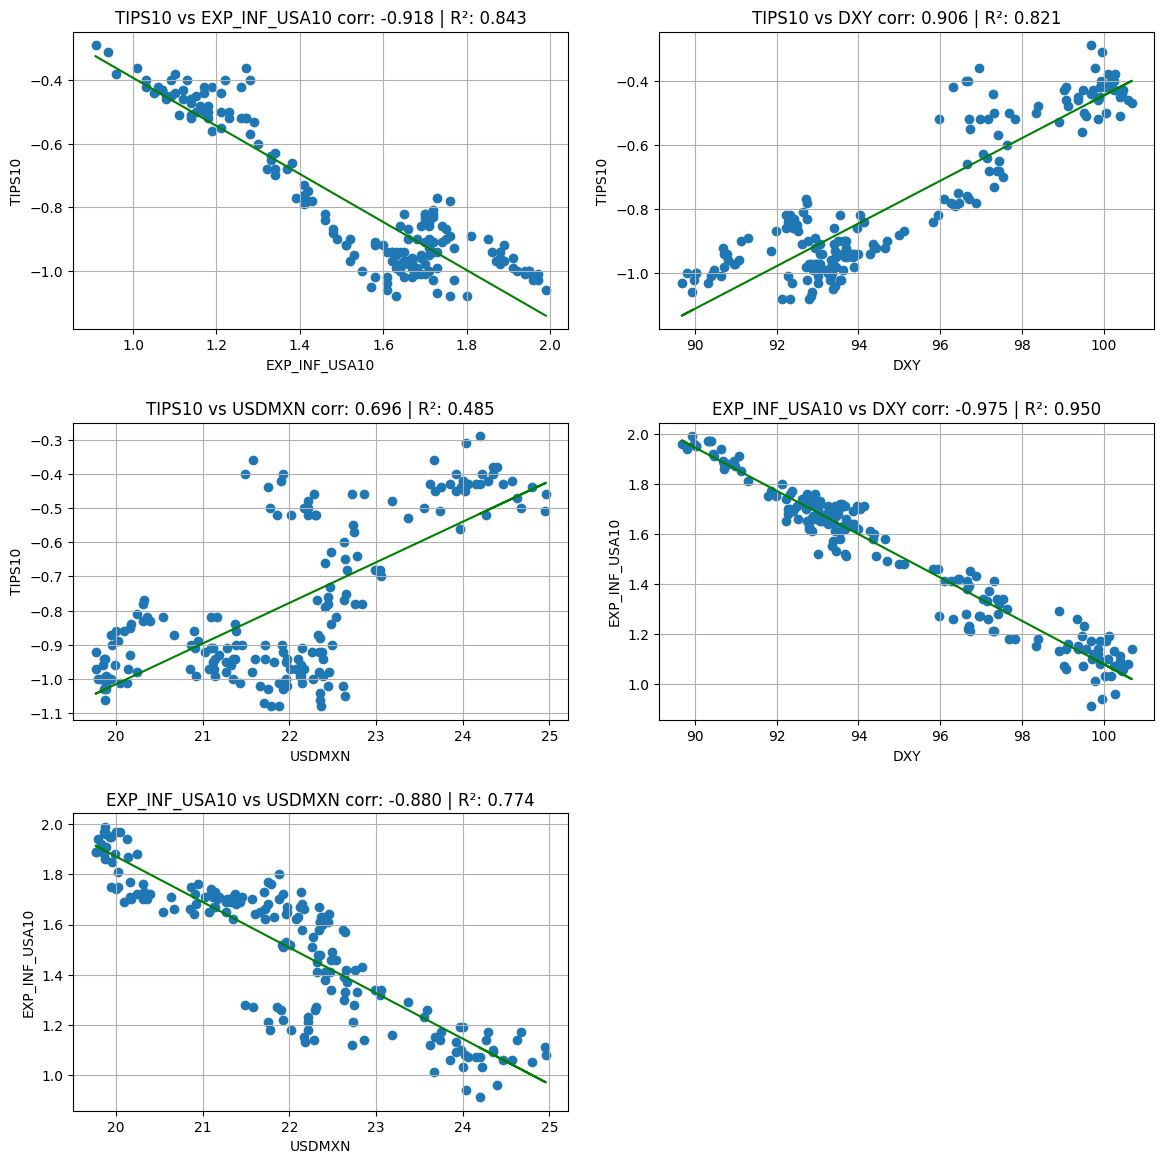

,security,benchmark,beta,correlation,r2
1,TIPS10,DXY,0.066583,0.906360,0.821488
2,TIPS10,USDMXN,0.118607,0.696120,0.484583
4,EXP_INF_USA10,USDMXN,-0.181929,-0.879735,0.773934
0,TIPS10,EXP_INF_USA10,-0.757249,-0.917914,0.842566
3,EXP_INF_USA10,DXY,-0.086697,-0.974720,0.950079


In [212]:
results_10 = []
models_to_plot = []

for sec in securities_10:
    for bench in benchmarks_10:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries(from_date='2020-04-01', to_date='2020-12-31')
        m.compute_linear_reg(target_column='closing')
        
        results_10.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })

        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)
    plt.show()

df_results_10 = pd.DataFrame(results_10)
df_results_10 = df_results_10.sort_values(by='correlation', ascending=False)

df_results_10

## Evidencia de cambio estructural en niveles (yields) -  Inflación esperada a 10 años

El análisis de la inflación esperada implícita a 10 años, en conjunto con las tasas reales (TIPS10), el dólar (DXY) y el tipo de cambio (USDMXN), revela una dinámica distinta y más estable en comparación con el horizonte a 5 años, particularmente en contextos de estrés.

En el periodo amplio de 2018 a 2021, se observa una estructura macro-financiera consistente. Las tasas reales a 10 años mantienen una correlación positiva relevante con el dólar (corr aprox. 0.66) y negativa con el tipo de cambio (corr aprox. -0.63), lo que sugiere que **continúan actuando como un ancla de largo plazo para los flujos de capital**. 
*Asimismo, la inflación esperada a 10 años muestra relaciones moderadas con estas variables, reflejando su papel como componente estructural más estable dentro del sistema.*

Al analizar el periodo 2019–2021, que incorpora el shock de la pandemia, las relaciones no desaparecen, sino que se reconfiguran. A diferencia del horizonte a 5 años donde predominaba el ruido, **en el horizonte a 10 años persisten correlaciones relevantes, incluso con cambios en signo**. 
Destaca, por ejemplo, la relación negativa entre inflación esperada y el dólar (DXY) (corr aprox. -0.66), así como la consistencia en la relación entre tasas reales y el tipo de cambio (USDMXN). Esto sugiere que, aun en un entorno de disrupción, las variables de largo plazo conservan cierto grado de coherencia estructural.

El resultado más relevante se observa en el periodo de abril a diciembre de 2020. En este intervalo, todas las variables presentan correlaciones altas y estadísticamente significativas entre sí. En particular:

* La relación entre tasas reales e inflación esperada es fuerte e inversa (corr aprox. -0.92).
* El dólar (DXY) muestra una correlación positiva elevada con tasas reales (corr aprox. 0.91) y negativa con inflación esperada (corr aprox. -0.97).
* El tipo de cambio (USDMXN) también presenta relaciones consistentes con ambas variables.

**A nivel visual, estas relaciones se reflejan en nubes de puntos claramente alineadas, indicando un alto grado de linealidad entre las variables. A diferencia del horizonte a 5 años donde la linealidad emergía únicamente en una relación específica**, en el horizonte a 10 años la linealidad se vuelve un fenómeno generalizado *durante el periodo de crisis, claro*.

---

Desde una perspectiva económica, esto sugiere que, en momentos de estrés, el mercado no se reduce a una sola relación dominante, sino que **opera como un sistema altamente integrado**, donde tasas reales, inflación esperada, dólar y tipo de cambio se ajustan de manera conjunta. **Este comportamiento es consistente con un entorno en el que los factores macroeconómicos de largo plazo como expectativas de crecimiento, inflación y política monetaria— dominan la dinámica del mercado.**

### Contraste con los resultados a 5 años
Con los resultados a 5 años se identificó un cambio estructural hacia una relación específica (tasas–inflación), el horizonte a 10 años muestra una mayor estabilidad estructural. Las relaciones no desaparecen ni se concentran en una sola dimensión, sino que se mantienen interconectadas, incluso durante episodios de alta volatilidad.

Este hallazgo sugiere que **el horizonte temporal es un elemento clave en el análisis macro-financiero**. 

*Mientras que los instrumentos de corto plazo son más sensibles a cambios de régimen y pueden reflejar dinámicas transitorias o dominadas por expectativas inmediatas, los instrumentos de largo plazo tienden a capturar relaciones más profundas y persistentes, manteniendo coherencia incluso en contextos adversos.*

**En conclusión, la inflación esperada a 10 años aporta una visión más estructural del mercado.** 
La evidencia indica que, a este horizonte, las relaciones macro-financieras no solo persisten, sino que pueden intensificarse en periodos de crisis, mostrando un alto grado de linealidad y consistencia. Esto refuerza la idea de que el análisis en niveles y a distintos horizontes temporales es fundamental para comprender la dinámica real de los mercados financieros.


**El mercado reacciona en el corto plazo, pero mantiene estabilidad en el largo plazo.**

# Comentarios finales - Relación entre inflación esperada a 5 y 10 años de EUA: similitud aparente vs dinámica real

#### Comparativa de horizontes (5Y vs 10Y) — Periodo: 2018–2026

| Security | Benchmark | Beta (5Y) | Corr (5Y) | R² (5Y)  | Beta (10Y) | Corr (10Y) | R² (10Y) |
| -------- | --------- | --------- | --------- | -------- | ---------- | ---------- | -------- |
| TIPS     | DXY       | 0.168275  | 0.699177  | 0.488848 | 0.138967   | 0.662091   | 0.438365 |
| TIPS     | EXP_INF   | 0.116261  | 0.046949  | 0.002204 | 0.910717   | 0.298574   | 0.089147 |
| EXP_INF  | DXY       | 0.021455  | 0.221713  | 0.049157 | 0.018568   | 0.271039   | 0.073462 |
| EXP_INF  | USDMXN    | -0.103587 | -0.298160 | 0.088900 | -0.099675  | -0.405683  | 0.164579 |
| TIPS     | USDMXN    | -0.529295 | -0.614993 | 0.378217 | -0.475907  | -0.634744  | 0.402900 |

---

#### Comparativa de horizontes (5Y vs 10Y) — Periodo: 2019–2021

| Security | Benchmark | Beta (5Y) | Corr (5Y) | R² (5Y)  | Beta (10Y) | Corr (10Y) | R² (10Y) |
| -------- | --------- | --------- | --------- | -------- | ---------- | ---------- | -------- |
| TIPS     | DXY       | 11.251624 | 0.089781  | 0.008061 | 0.137342   | 0.655098   | 0.429153 |
| TIPS     | EXP_INF   | -0.717186 | -0.103370 | 0.010685 | -0.573901  | -0.387330  | 0.150025 |
| EXP_INF  | DXY       | -1.288161 | -0.072900 | 0.005314 | -0.093143  | -0.661134  | 0.437099 |
| EXP_INF  | USDMXN    | -1.078032 | -0.145132 | 0.021063 | -0.124051  | -0.410951  | 0.168880 |
| TIPS     | USDMXN    | -3.554643 | -0.068251 | 0.004658 | -0.198884  | -0.445412  | 0.198392 |

---

#### Comparativa de horizontes (5Y vs 10Y) — Periodo: Abril 2020 – Diciembre 2020

| Security | Benchmark | Beta (5Y) | Corr (5Y) | R² (5Y)  | Beta (10Y) | Corr (10Y) | R² (10Y) |
| -------- | --------- | --------- | --------- | -------- | ---------- | ---------- | -------- |
| TIPS     | DXY       | 1.137233  | 0.042182  | 0.001779 | 0.066583   | 0.906360   | 0.821488 |
| TIPS     | EXP_INF   | 1.777217  | 0.823963  | 0.678915 | -0.757249  | -0.917914  | 0.842566 |
| EXP_INF  | DXY       | -1.000072 | -0.082543 | 0.006813 | -0.086697  | -0.974720  | 0.950079 |
| EXP_INF  | USDMXN    | -0.492472 | -0.119108 | 0.014187 | -0.181929  | -0.879735  | 0.773934 |
| TIPS     | USDMXN    | 0.130057  | 0.014528  | 0.000211 | 0.118607   | 0.696120   | 0.484583 |



Uno de los hallazgos más interesantes del análisis es la alta correlación observada entre la inflación esperada implícita a 5 y 10 años, con valores cercanos a 1 (corr aprox. 0.98, R^2 aprox. 0.96) en el periodo completo. A primera vista, este resultado sugiere que ambas variables contienen prácticamente la misma información, lo que podría llevar a asumir que su comportamiento frente a otros activos debería ser equivalente.

Sin embargo, los resultados del proyecto muestran que esta interpretación es incompleta.

A pesar de su fuerte relación entre sí, las expectativas de inflación a 5 y 10 años interactúan de manera distinta con otras variables financieras, como el dólar (DXY), el tipo de cambio USD/MXN y las tasas reales (TIPS). En particular, se observa que:

* En el horizonte de 5 años, las relaciones tienden a ser más inestables y sensibles a episodios de crisis, mostrando cambios de régimen más marcados.
* En el horizonte de 10 años, las relaciones son más consistentes y estructurales, manteniendo correlaciones significativas incluso en periodos de alta volatilidad.

Este contraste evidencia que, aunque ambas medidas están altamente correlacionadas, no son intercambiables desde una perspectiva económica. Cada una refleja distintos horizontes de expectativas y, por lo tanto, captura diferentes dinámicas del mercado.

Desde un punto de vista conceptual, la inflación esperada a 5 años incorpora en mayor medida el ruido de corto plazo y los shocks inmediatos, mientras que la de 10 años refleja expectativas más ancladas y de largo plazo. Esto explica por qué, ante un mismo evento (como la crisis de 2020), su comportamiento relativo frente a otros activos puede divergir.

**Implicación clave:**
Una alta correlación entre dos variables no implica que tengan el mismo poder explicativo ni el mismo comportamiento dentro de un sistema financiero más amplio.

Este resultado refuerza uno de los principios centrales del proyecto: las relaciones macro-financieras deben analizarse en contexto. Incluso variables aparentemente redundantes pueden aportar información diferenciada dependiendo del horizonte temporal y del régimen de mercado.

En este sentido, el análisis conjunto de ambas curvas de inflación no solo enriquece la interpretación, sino que evita conclusiones simplistas basadas únicamente en métricas agregadas como la correlación.



# Análisis de México
Para el caso de México, trabajaremos con UDIBONOS a 3 y 10 años, además de los bonos a tasa fija correspondiente a bonos M de 3 y 10 años, por último estaremos añadiendo al análisis un nuevo índice de la BMV, el IPC, con ticker MXX, en adición a nuestros índices de interés, que son el principal *scoop* del proyecto.

*Cabe mencionar que todo el código y nuestras herramientas permiten de forma dinámica agregar cualquier varialbe nueva que sea de nuestro interés.*

# Consistencia de expectativas inflacionarias: análisis 3Y vs 10Y de México

A diferencia del caso de Estados Unidos, en México no existe una disponibilidad directa y consistente de instrumentos indexados a la inflación para todos los horizontes de interés, particularmente a 5 años. Por ello, para el análisis se emplea un horizonte a 3 años utilizando BONOS M y UDIBONOS a dicho plazo, junto con una estimación de inflación esperada implícita. 

Este enfoque requiere la construcción de aproximaciones coherentes que permitan capturar la dinámica de expectativas inflacionarias y tasas reales, manteniendo consistencia económica en la interpretación de los resultados, **de momento trabajaremos con los horizontes disponibles a 3 y 10 años.**


## Diferenciación por horizonte: expectativas de inflación a 3 y 10 años

Con el objetivo de profundizar en el análisis de la dinámica macro-financiera, se extiende el estudio de inflación esperada incorporando dos horizontes temporales: mediano plazo (3 años) y largo plazo (10 años) de México.

Bajo este enfoque, se analiza si la relación entre tasas reales e inflación esperada presenta comportamientos diferenciados dependiendo del horizonte considerado, particularmente durante el episodio de crisis asociado a 2020.

Este análisis permite evaluar no solo la existencia de cambios en las relaciones macro-financieras, sino también si dichos cambios son homogéneos a lo largo de la estructura temporal de expectativas.



Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/EXP_INF_MX3.csv
Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/EXP_INF_MX10.csv


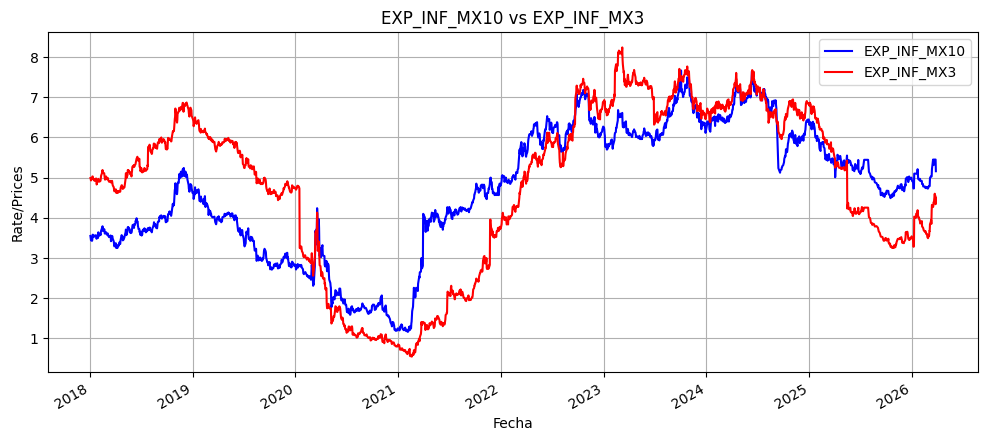

In [131]:
# Obtener la inflación esperada implícita de México a 3 años (derivada de la diferencia entre tasas nominales y reales)
expected_inflation_usa_5 = rrm.synchronise_timseries_df('BONOM3', 'UDIBONOS3', 'Cierre', 'Tasa', dif = True)
rrm.cargar_archivo(expected_inflation_usa_5, archivo = 'EXP_INF_MX3')

# Obtener la inflación esperada implícita de México a 10 años (derivada de la diferencia entre tasas nominales y reales)
expected_inflation_usa_10 = rrm.synchronise_timseries_df('BONOM10', 'UDIBONOS10', 'Cierre', 'Tasa', dif = True)
rrm.cargar_archivo(expected_inflation_usa_10, archivo = 'EXP_INF_MX10')

rrm.plot_two_timeseries('EXP_INF_MX10', 'EXP_INF_MX3', 'Diferencia', 'Diferencia', titulo = "EXP_INF_MX10 vs EXP_INF_MX3", secondary_y=False)

From: 2018-01-03 00:00:00 - To: 2026-03-27 00:00:00
Beta: 1.018407, Corr: 0.798069, R2: 0.636915


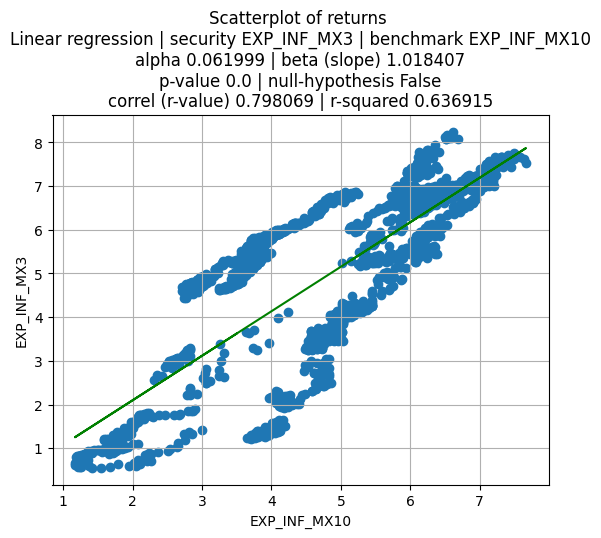

In [236]:
m = capm.model('EXP_INF_MX3', 'EXP_INF_MX10', 6)
m.synchronise_timeseries()
m.compute_linear_reg(target_column='closing')
m.plot_linear_reg()

print(f"From: {m.timeseries['date'].min()} - To: {m.timeseries['date'].max()}")        
print(f"Beta: {m.beta}, Corr: {m.correlation}, R2: {m.r_squared}")

# Análisis de expectativas de inflación por horizonte temporal

Con el objetivo de complementar el análisis previo, se incorpora el estudio de la inflación esperada considerando distintos horizontes temporales, específicamente a 3 y 10 años. Esta extensión permite evaluar si las dinámicas observadas en el comportamiento macro-financiero son consistentes a lo largo de la estructura temporal de expectativas o si presentan diferencias relevantes dependiendo del plazo considerado.

Esto nos permitirá evaluar si las relaciones entre información macro-financieras son homogéneas utilizando la información de México o si por el contrario, presentan comportamientos distintos dependiendo del plazo considerado.

# Análisis Exploratorio y Evidencia Empírica Inicial - Enfoque sobre MX a 3 años

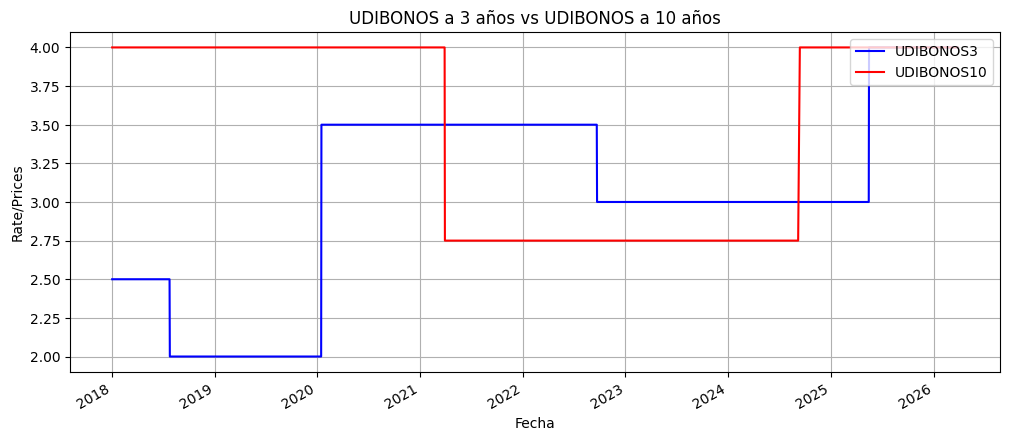

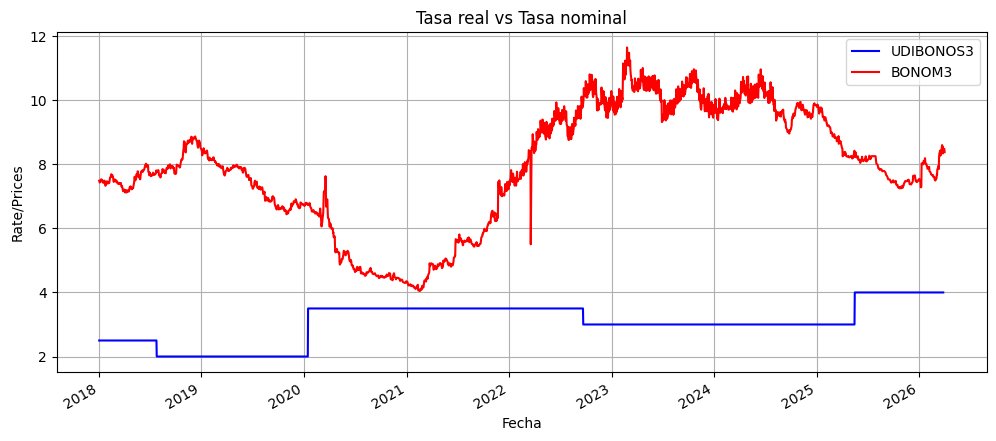

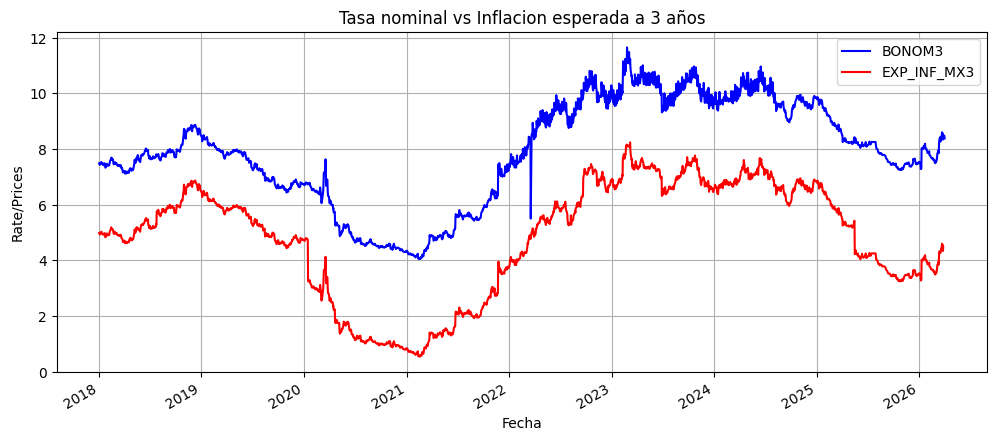

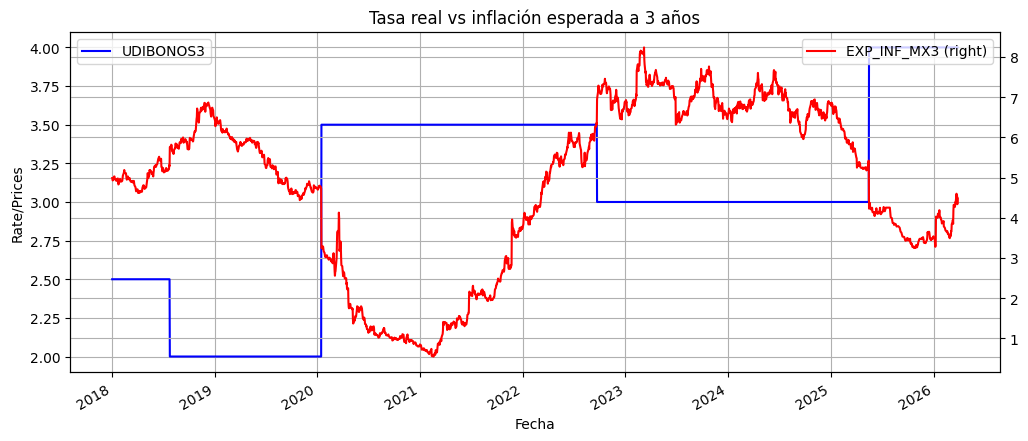

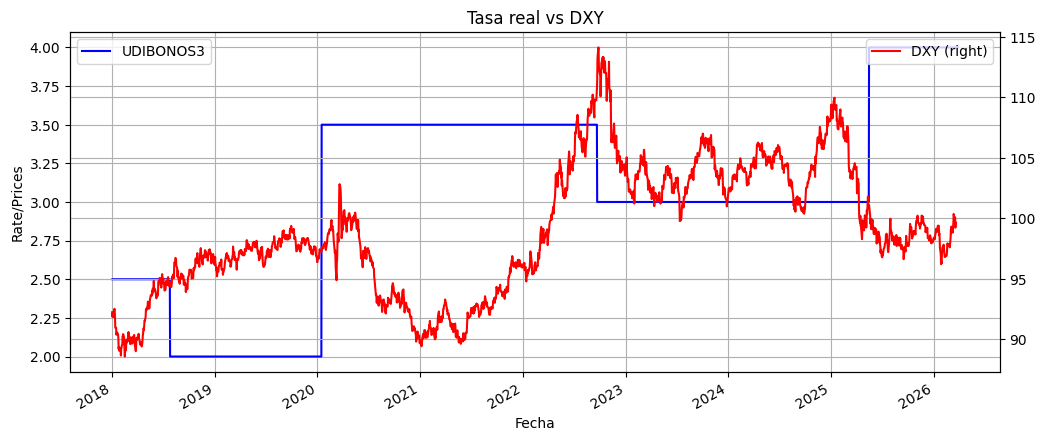

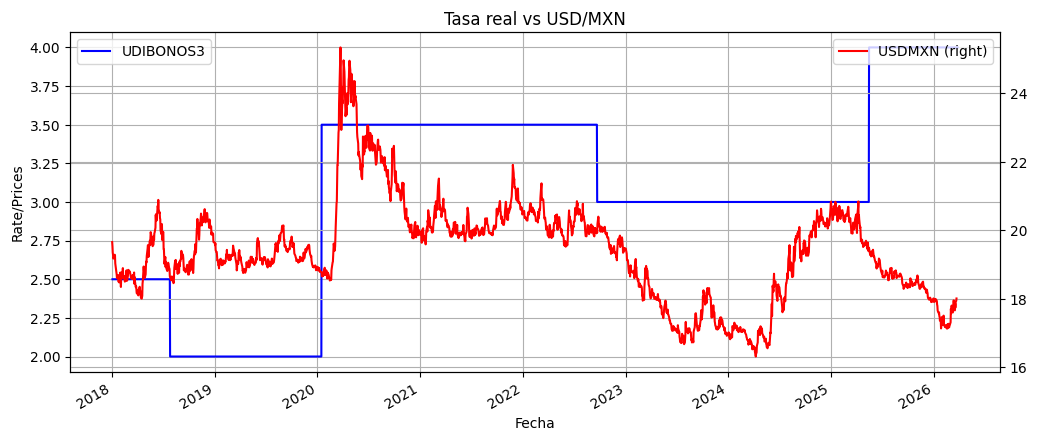

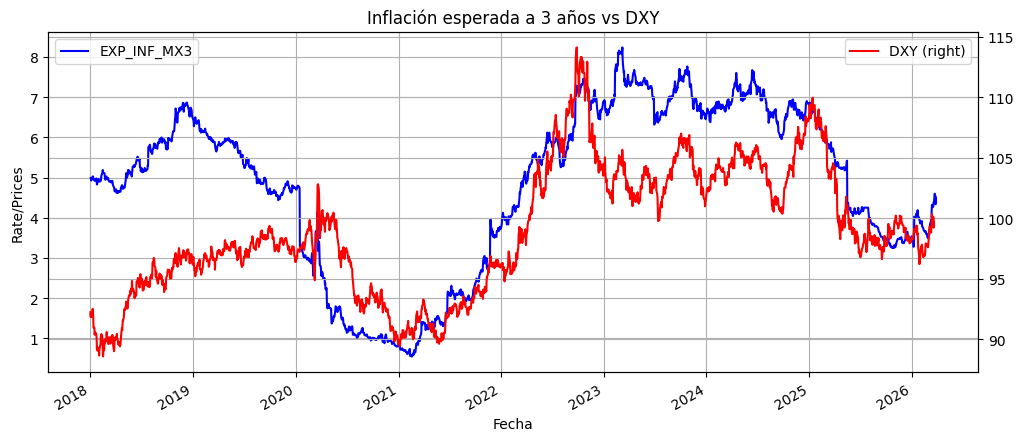

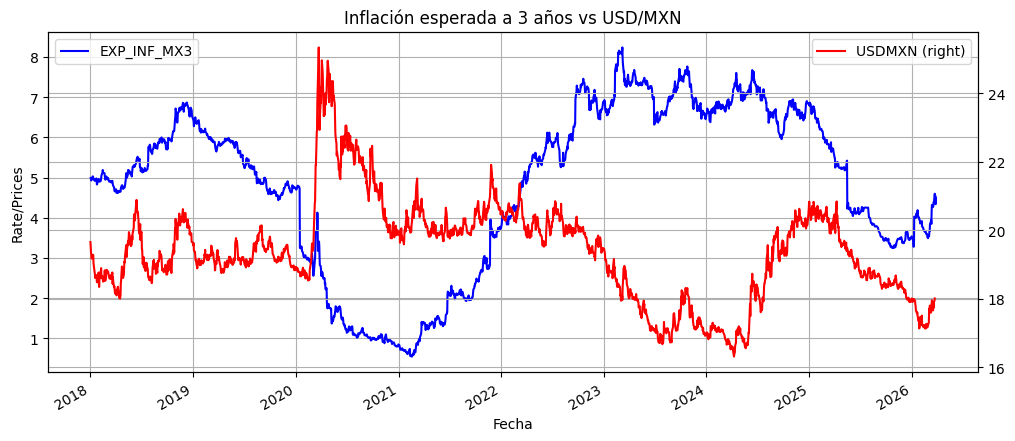

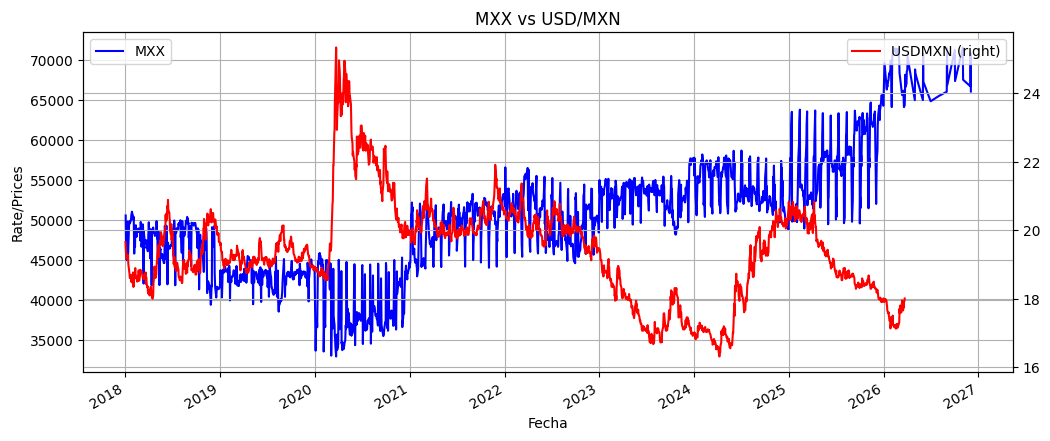

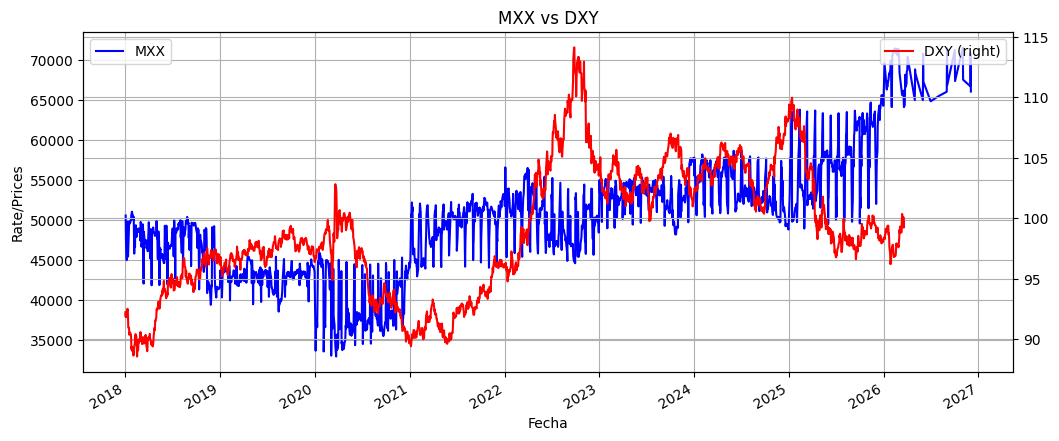

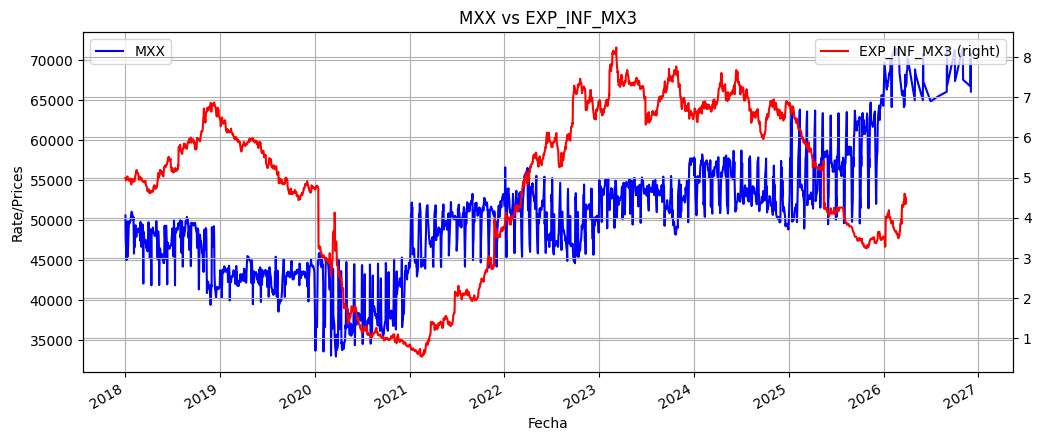

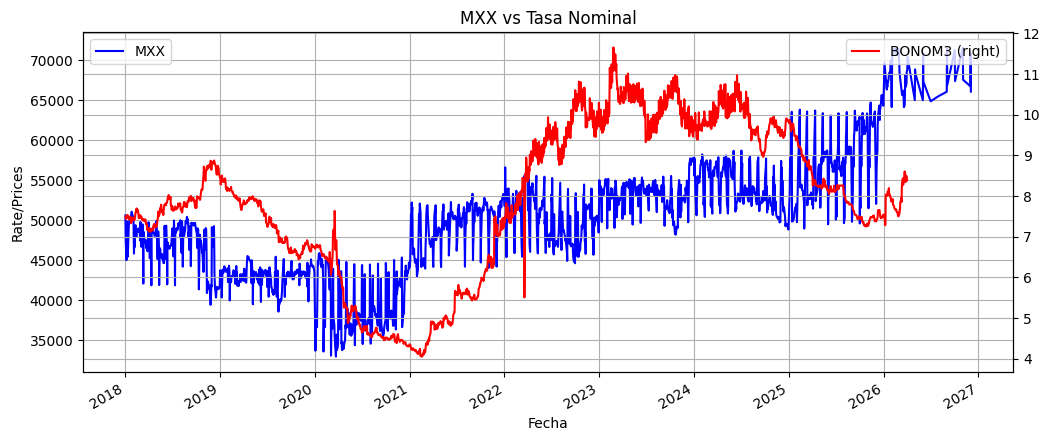

In [285]:
rrm.plot_two_timeseries('UDIBONOS3', 'UDIBONOS10', 'Tasa', 'Tasa', titulo = 'UDIBONOS a 3 años vs UDIBONOS a 10 años', secondary_y=False)
rrm.plot_two_timeseries('UDIBONOS3', 'BONOM3', 'Tasa', 'Cierre', titulo = 'Tasa real vs Tasa nominal', secondary_y=False)

rrm.plot_two_timeseries('BONOM3', 'EXP_INF_MX3', 'Cierre', 'Diferencia', titulo = 'Tasa nominal vs Inflacion esperada a 3 años', secondary_y=False)

rrm.plot_two_timeseries('UDIBONOS3', 'EXP_INF_MX3', 'Tasa', 'Diferencia', titulo = 'Tasa real vs inflación esperada a 3 años') # from_date='2020-01-01', to_date='2020-12-01
rrm.plot_two_timeseries('UDIBONOS3', 'DXY', 'Tasa', 'Cierre', titulo = 'Tasa real vs DXY')
rrm.plot_two_timeseries('UDIBONOS3', 'USDMXN', 'Tasa', 'Cierre', titulo = 'Tasa real vs USD/MXN')
rrm.plot_two_timeseries('EXP_INF_MX3', 'DXY', 'Diferencia', 'Cierre', titulo = 'Inflación esperada a 3 años vs DXY')
rrm.plot_two_timeseries('EXP_INF_MX3', 'USDMXN', 'Diferencia', 'Cierre', titulo = 'Inflación esperada a 3 años vs USD/MXN')

rrm.plot_two_timeseries('MXX', 'USDMXN', 'Cierre', 'Cierre', titulo = 'MXX vs USD/MXN')
rrm.plot_two_timeseries('MXX', 'DXY', 'Cierre', 'Cierre', titulo = 'MXX vs DXY')
rrm.plot_two_timeseries('MXX', 'EXP_INF_MX3', 'Cierre', 'Diferencia', titulo = 'MXX vs EXP_INF_MX3')
rrm.plot_two_timeseries('MXX', 'BONOM3', 'Cierre', 'Cierre', titulo = 'MXX vs Tasa Nominal')





## Tratamiento de UDIBONOS y el supuesto de variabilidad en modelos lineales

Un aspecto metodológico relevante en este análisis es el comportamiento de las tasas reales en México, particularmente las asociadas a UDIBONOS. A diferencia de otras variables financieras, estos instrumentos presentan una dinámica caracterizada por **baja variabilidad temporal**, con cambios poco frecuentes y niveles que permanecen constantes durante largos periodos.

Este comportamiento contrasta con uno de los supuestos implícitos de los modelos de regresión lineal: la existencia de **variabilidad continua en las variables**, lo cual permite capturar relaciones suaves y graduales entre ellas.

En este contexto, surge una pregunta clave: ¿deben tratarse los UDIBONOS de manera diferente?

La respuesta es **no eliminarlos ni transformarlos arbitrariamente**, sino **interpretarlos bajo su naturaleza económica**. La baja variabilidad observada no es un defecto del dato, sino una característica inherente al instrumento, influenciada por factores como la política monetaria, la estructura del mercado y la menor frecuencia de ajustes en tasas reales.

Por tanto, en lugar de modificar los datos, se adopta el siguiente enfoque:

* Se mantienen los niveles (yields) como representación fiel del mercado.
* Se reconoce que la regresión lineal puede no capturar completamente su dinámica.
* Se complementa el análisis con interpretación económica, priorizando el contexto sobre el ajuste estadístico.

En síntesis, los UDIBONOS no requieren un tratamiento distinto en términos de manipulación de datos, pero sí una **lectura más cuidadosa**, entendiendo que su comportamiento puede limitar la aplicabilidad de modelos lineales tradicionales.


# Evaluación estadística - Horizonte de 3 años
Los siguientes resultados se obtendrán usando la inflación esperada implícita de México a 3 años bajo diferentes periodos de interés.

## Observaciones del periodo 2018-2026 
Bajo inflación esperada implícita de México a 3 años

,security,benchmark,beta,correlation,r2
3,EXP_INF_MX3,DXY,0.276658,0.710784,0.505214
5,MXX,EXP_INF_MX3,1071.795196,0.324110,0.105048
6,MXX,DXY,391.970730,0.301116,0.090671
2,UDIBONOS3,USDMXN,0.063899,0.151005,0.022802
1,UDIBONOS3,DXY,0.004349,0.037040,0.001372
0,UDIBONOS3,EXP_INF_MX3,-0.141213,-0.477297,0.227812
4,EXP_INF_MX3,USDMXN,-0.785487,-0.559779,0.313353
7,MXX,USDMXN,-2826.577497,-0.600833,0.361000


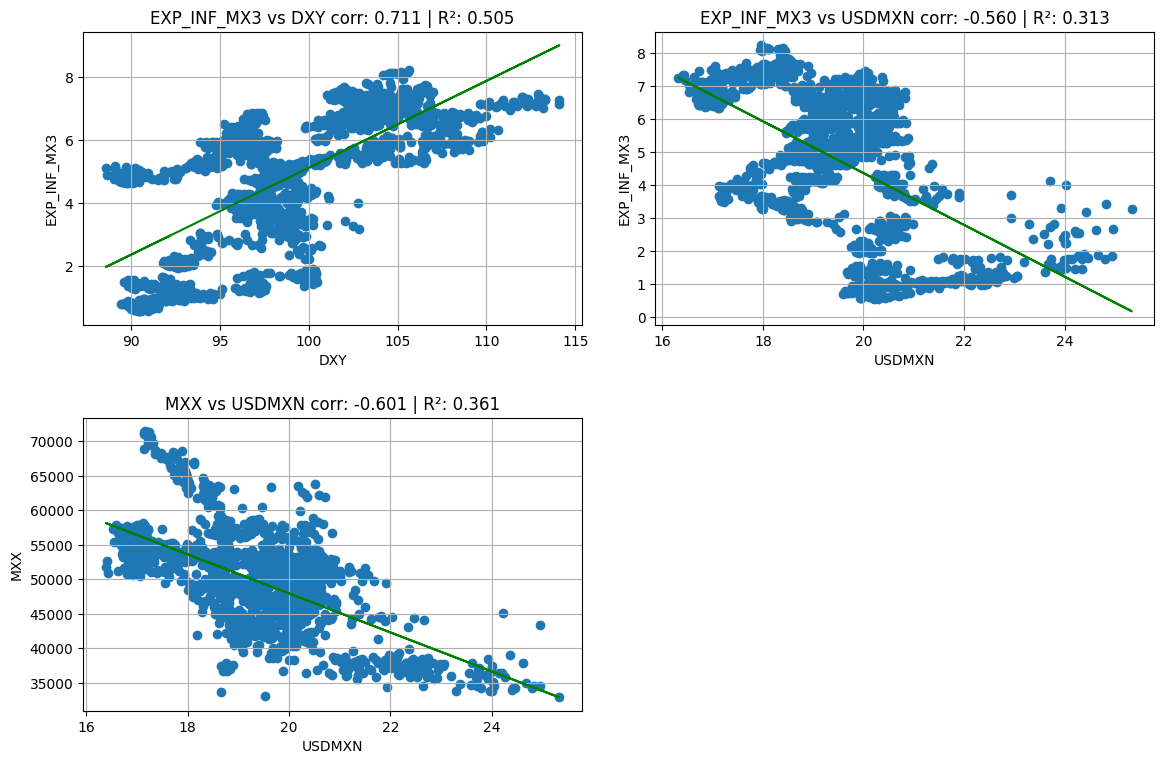

In [ ]:
benchmarks_mx3 = ['EXP_INF_MX3', 'DXY', 'USDMXN']
securities_mx3 = ['UDIBONOS3', 'EXP_INF_MX3', 'MXX']

results_mx3 = []
models_to_plot = []

for sec in securities_mx3:
    for bench in benchmarks_mx3:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries()
        m.compute_linear_reg(target_column='closing')
        
        results_mx3.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)

results_mx3 = pd.DataFrame(results_mx3)
results_mx3 = results_mx3.sort_values(by='correlation', ascending=False)

results_mx3


## Observaciones del periodo 2019-2021 
Bajo inflación esperada implícita de México a 3 años

,security,benchmark,beta,correlation,r2
3,EXP_INF_MX3,DXY,0.402954,0.641719,0.411803
2,UDIBONOS3,USDMXN,0.296419,0.576070,0.331857
5,MXX,EXP_INF_MX3,-59.349860,-0.022098,0.000488
7,MXX,USDMXN,-1546.655069,-0.428623,0.183718
6,MXX,DXY,-773.056654,-0.459816,0.211431
1,UDIBONOS3,DXY,-0.123850,-0.522283,0.272780
4,EXP_INF_MX3,USDMXN,-0.735118,-0.539516,0.291078
0,UDIBONOS3,EXP_INF_MX3,-0.342087,-0.905935,0.820718


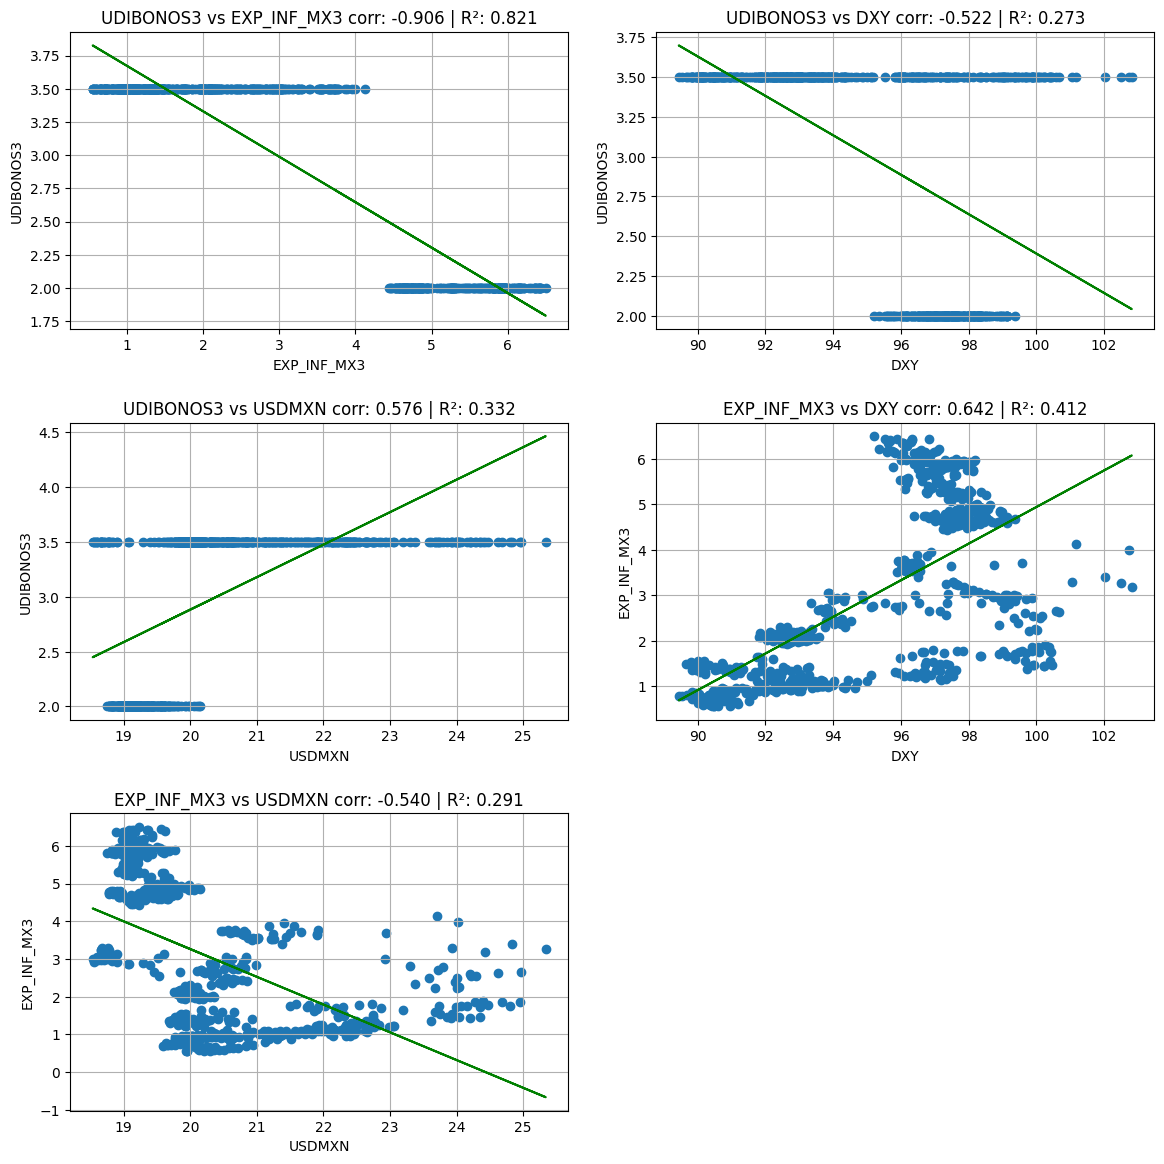

In [ ]:
benchmarks_mx3 = ['EXP_INF_MX3', 'DXY', 'USDMXN']
securities_mx3 = ['UDIBONOS3', 'EXP_INF_MX3', 'MXX']

results_mx3 = []
models_to_plot = []

for sec in securities_mx3:
    for bench in benchmarks_mx3:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries(from_date='2019-01-01', to_date='2021-12-31')
        m.compute_linear_reg(target_column='closing')
        
        results_mx3.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)

results_mx3 = pd.DataFrame(results_mx3)
results_mx3 = results_mx3.sort_values(by='correlation', ascending=False)

results_mx3

## Observaciones del periodo de mayor estrés (abril de 2020 - diciembre 2020) 
Bajo inflación esperada implícita de México a 3 años

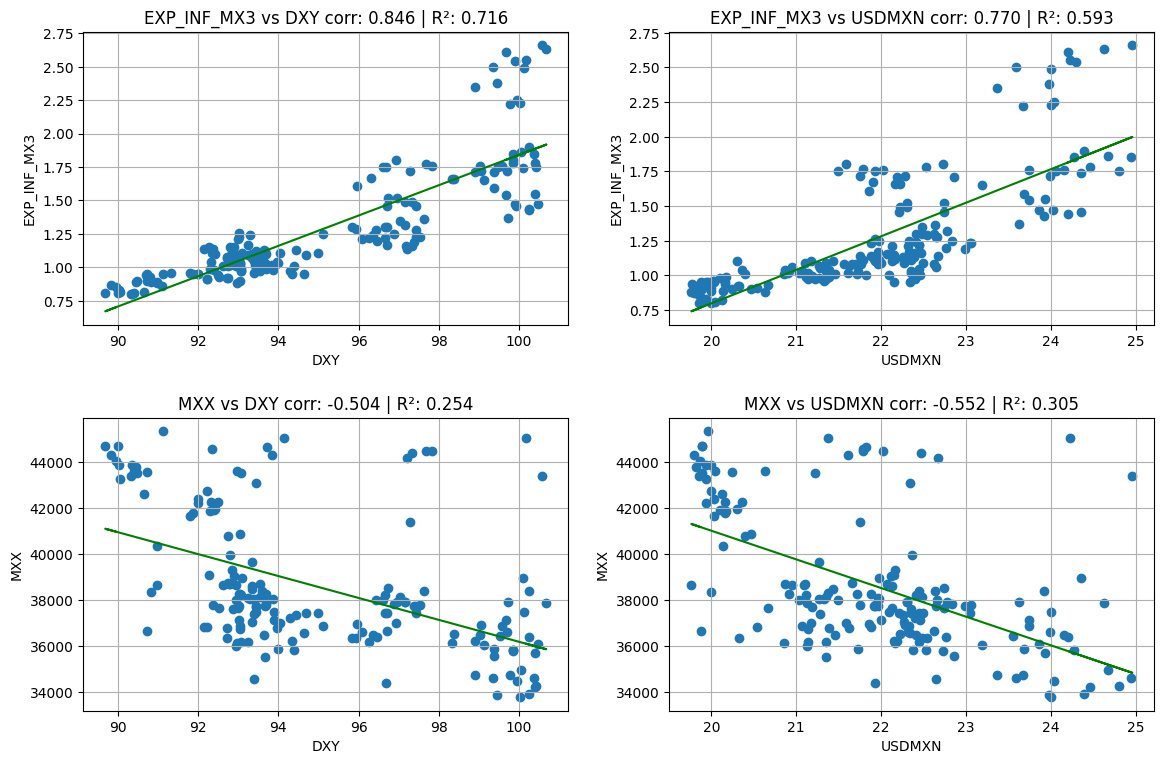

,security,benchmark,beta,correlation,r2
3,EXP_INF_MX3,DXY,0.113228,0.846294,0.716214
4,EXP_INF_MX3,USDMXN,0.242009,0.769848,0.592666
0,UDIBONOS3,EXP_INF_MX3,0.000000,0.000000,0.000000
1,UDIBONOS3,DXY,0.000000,0.000000,0.000000
2,UDIBONOS3,USDMXN,0.000000,0.000000,0.000000
5,MXX,EXP_INF_MX3,-2690.590172,-0.377873,0.142788
6,MXX,DXY,-476.602432,-0.503663,0.253676
7,MXX,USDMXN,-1246.737584,-0.552359,0.305100


In [216]:
import math
benchmarks_mx3 = ['EXP_INF_MX3', 'DXY', 'USDMXN']
securities_mx3 = ['UDIBONOS3', 'EXP_INF_MX3', 'MXX']

results_mx3 = []
models_to_plot = []

for sec in securities_mx3:
    for bench in benchmarks_mx3:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries(from_date='2020-04-01', to_date='2020-12-31')
        m.compute_linear_reg(target_column='closing')
        
        results_mx3.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)
    plt.show()

results_mx3 = pd.DataFrame(results_mx3)
results_mx3 = results_mx3.sort_values(by='correlation', ascending=False)

results_mx3

### Observación

En los gráficos de dispersión asociados a UDIBONOS, se observa la presencia de patrones visuales en forma de líneas horizontales o agrupaciones discretas de puntos. Este fenómeno responde a la baja variabilidad de las tasas reales, que tienden a permanecer constantes durante periodos prolongados como bien mencionamos un apartado antes de realizar la evaluación estadística.

Entonces

Reconocemos la limitación del modelo e interpretar los resultados en consecuencia.

En conclusión, estos patrones no invalidan el análisis, sino que enriquecen su interpretación, evidenciando que las relaciones macro-financieras pueden no ser lineales ni continuas, especialmente en variables estructuralmente rígidas como las tasas reales.

# Prueba de significancia 

## Justificación del uso de la prueba de Chow para cambio estructural

El análisis desarrollado a lo largo de distintos periodos (2018–2026, 2019–2021 y abril–diciembre de 2020) sugiere que las relaciones entre variables no son estables en el tiempo, sino que varían en función del entorno económico.

En particular, se identifican cambios en la intensidad e incluso en el signo de las relaciones entre:

* Inflación esperada y el dólar (DXY)
* Inflación esperada y el tipo de cambio (USDMXN)

Ante esta evidencia, resulta adecuado aplicar la **prueba de Chow**, cuyo objetivo es evaluar formalmente la existencia de un cambio estructural en la relación entre variables.

La elección de esta prueba se justifica por:

* La presencia de distintos regímenes de mercado (pre-crisis, crisis, post-crisis).
* Cambios visibles en los coeficientes de correlación entre periodos.
* La necesidad de validar si estas diferencias son estadísticamente significativas.

Adicionalmente, se seleccionan específicamente estas relaciones debido a su relevancia macroeconómica:

* La inflación esperada refleja las expectativas del mercado.
* El dólar y el tipo de cambio representan factores externos clave, especialmente en economías emergentes.

Por lo tanto, el uso de la prueba de Chow en estos casos permite:

* Confirmar si las relaciones cambian estructuralmente entre periodos.
* Respaldar empíricamente la hipótesis de dependencia del régimen de mercado.
* Evitar conclusiones basadas únicamente en observación gráfica.

Hay evidencia de cambio estructural (rechazamos H0)


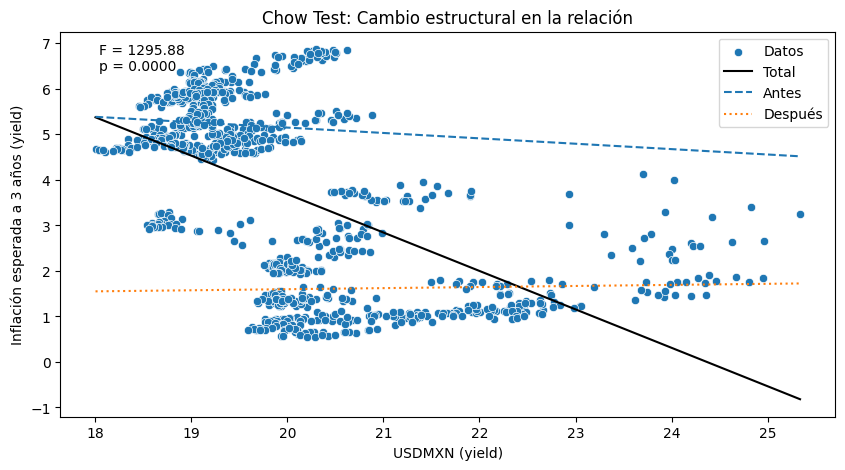

Hay evidencia de cambio estructural (rechazamos H0)


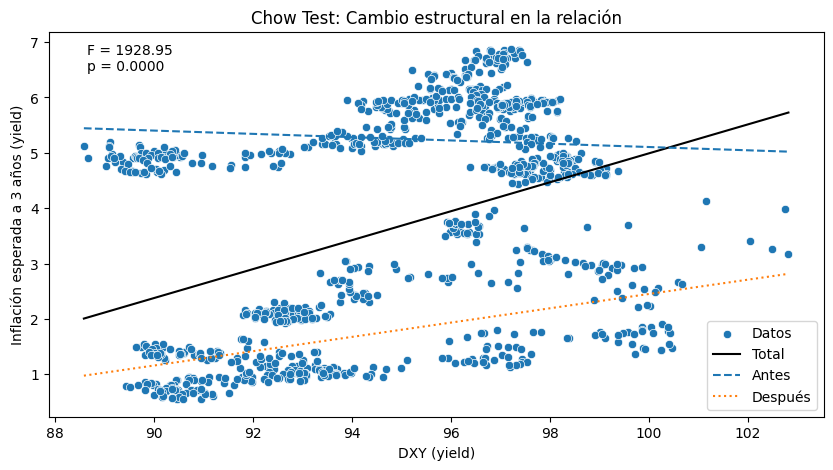

In [222]:
break_date = '2020-04-01'

for i in ['USDMXN', 'DXY']:
    # MODELO TOTAL
    m_total = capm.model('EXP_INF_MX3', i, 20)
    m_total.synchronise_timeseries(from_date='2018-01-01', to_date='2021-12-31')
    m_total.compute_linear_reg(target_column='closing')

    y_hat_total = m_total.alpha + m_total.beta * m_total.x
    RSS_total = np.sum((m_total.y - y_hat_total)**2)
    n_total = len(m_total.y)

    # MODELO ANTES DEL QUIEBRE
    m_1 = capm.model('EXP_INF_MX3', i, 6)
    m_1.synchronise_timeseries(from_date='2018-01-01', to_date=break_date)
    m_1.compute_linear_reg(target_column='closing')

    y_hat_1 = m_1.alpha + m_1.beta * m_1.x
    RSS_1 = np.sum((m_1.y - y_hat_1)**2)
    n1 = len(m_1.y)

    # MODELO DESPUES DEL QUIEBRE
    m_2 = capm.model('EXP_INF_MX3', i, 20)
    m_2.synchronise_timeseries(from_date=break_date, to_date='2021-12-31')
    m_2.compute_linear_reg(target_column='closing')

    y_hat_2 = m_2.alpha + m_2.beta * m_2.x
    RSS_2 = np.sum((m_2.y - y_hat_2)**2)
    n2 = len(m_2.y)

    # CALCULO DEL ESTADÍSTICO
    k = 2  # constante + 1 variable

    F = ((RSS_total - (RSS_1 + RSS_2)) / k) / ((RSS_1 + RSS_2) / (n1 + n2 - 2*k))

    # P VALUE
    p_value_chow = 1 - f.cdf(F, k, n1 + n2 - 2*k)

    # Interpretación
    if p_value_chow < 0.05:
        print("Hay evidencia de cambio estructural (rechazamos H0)")
    else:
        print("No hay evidencia suficiente de cambio estructural")

    # Visual
    plt.figure(figsize=(10,5))

    # scatter (usa returns, no close si quieres consistencia con el modelo)
    sns.scatterplot(x=m_total.x, y=m_total.y, label='Datos')

    # rango de x
    x_vals = np.linspace(min(m_total.x), max(m_total.x), 100)

    # línea total
    y_vals_total = m_total.alpha + m_total.beta * x_vals
    plt.plot(x_vals, y_vals_total, color='black', label='Total')

    # línea antes
    y_vals_1 = m_1.alpha + m_1.beta * x_vals
    plt.plot(x_vals, y_vals_1, linestyle='--', label='Antes')

    # línea después
    y_vals_2 = m_2.alpha + m_2.beta * x_vals
    plt.plot(x_vals, y_vals_2, linestyle=':', label='Después')

    plt.legend()
    plt.title("Chow Test: Cambio estructural en la relación")
    plt.xlabel(i + " (yield)")
    plt.ylabel("Inflación esperada a 3 años (yield)")

    plt.text(0.05, 0.9, f"F = {F:.2f}\np = {p_value_chow:.4f}", transform=plt.gca().transAxes)

    plt.show()

## Evidencia de cambio estructural en niveles – México (horizonte 3 años)

Al analizar el periodo amplio de 2018 a 2026, se observan relaciones relevantes entre las variables macro-financieras en México. **Destaca una correlación positiva significativa entre la inflación esperada a 3 años y el tipo de cambio (USDMXN), así como una relación positiva con el dólar (DXY)**. Esto sugiere un entorno donde las expectativas inflacionarias están estrechamente ligadas a factores externos, particularmente a movimientos cambiarios y presiones provenientes del dólar.

Asimismo, se observa una **relación negativa entre el índice accionario mexicano (MXX) y el tipo de cambio USDMXN**, lo cual es consistente con la intuición económica: una depreciación del peso suele estar asociada a salidas de capital y presión sobre los mercados bursátiles. En este contexto, el mercado mexicano presenta una estructura relativamente clara, donde el tipo de cambio actúa como una variable central de transmisión.

Sin embargo, al enfocar el análisis **en el periodo 2019–2021**, que incorpora el choque de la pandemia, no se observa una simple pérdida generalizada de relaciones, sino una **reconfiguración más compleja y heterogénea** entre las variables macro-financieras en México.

A diferencia de lo que podría esperarse en un entorno de crisis donde las correlaciones tienden a debilitarse (como en el caso de Estados Unidos), los resultados muestran que **algunas relaciones se mantienen e incluso se intensifican**, mientras que otras pierden relevancia o se vuelven prácticamente nulas.

En particular:

* La relación entre **inflación esperada y el dólar (DXY)** se mantiene **positiva y relevante** (corr aprox. 0.64), lo que sugiere que las expectativas inflacionarias continúan respondiendo a factores externos, incluso en un entorno de alta incertidumbre.
  
* De manera consistente, la relación entre **inflación esperada y tipo de cambio (USDMXN)** permanece **negativa y significativa** (corr aprox. -0.54), reforzando la idea de que el canal cambiario sigue siendo un mecanismo clave de transmisión en la economía mexicana.

* Destaca particularmente la relación entre **UDIBONOS y la inflación esperada**, con una **correlación negativa muy alta (aprox. -0.91)** y un **alto poder explicativo (R² aprox. 0.82)**. Este resultado sugiere una fuerte interdependencia entre tasas reales y expectativas inflacionarias, indicando que, en este periodo, el mercado comienza a internalizar de forma más directa las expectativas en la estructura de tasas.

* En contraste, el **mercado accionario (MXX)** mantiene relaciones **moderadas y negativas** con el dólar y el tipo de cambio, reflejando su sensibilidad a condiciones financieras externas y a movimientos de capital.

En conjunto, estos resultados sugieren que el periodo 2019–2021 no se caracteriza por una simple ruptura de relaciones, sino por una **redistribución de la relevancia entre variables**.

Este comportamiento es consistente con un entorno de crisis en economías emergentes, donde los choques externos no eliminan la estructura del mercado, sino que **reordenan los canales de transmisión**, concentrando la dinámica en variables clave como el tipo de cambio y las expectativas inflacionarias.

No obstante, al aislar el periodo de mayor estrés (abril a diciembre de 2020), emerge nuevamente una estructura, pero con características distintas. En este intervalo:

* La relación entre inflación esperada y el dólar se fortalece de manera importante.
* La relación entre inflación esperada y tipo de cambio se mantiene significativa, reflejando la sensibilidad de México a choques externos.
* El mercado accionario (MXX) muestra relaciones más inestables, sugiriendo que en momentos de crisis su comportamiento incorpora múltiples factores simultáneamente, especificamente con DXY y USDMXN, siendo en parte consistentes, pues ante una crisis e inestabilidad, el mercado accionario puede verse afectado por el fortalecmiento del dolar.

A nivel visual, las nubes de dispersión presentan patrones más definidos en ciertas relaciones clave, particularmente aquellas vinculadas al tipo de cambio, lo que indica que, incluso en crisis, el mercado no pierde completamente su estructura, sino que se reorganiza en torno a variables dominantes.

---

**En conjunto, estos resultados sugieren que el mercado mexicano es altamente dependiente del canal cambiario como mecanismo de transmisión macro-financiera.**

* *En condiciones normales*, **existe una estructura clara donde la inflación esperada, el tipo de cambio y el dólar interactúan de manera consistente.**
* *En periodos de estrés*, esta estructura no desaparece, pero se concentra y amplifica en torno a factores externos, particularmente el tipo de cambio y la dinámica del dólar.

Este hallazgo es consistente con la naturaleza de economías emergentes, donde los flujos de capital, el riesgo país y la dependencia externa juegan un papel central en la formación de precios.

En síntesis, la evidencia muestra que, al igual que en economías desarrolladas, las relaciones macro-financieras en México son dependientes del régimen. Sin embargo, a diferencia de Estados Unidos, el canal dominante en México durante episodios de crisis no es únicamente la inflación esperada, sino el tipo de cambio como variable integradora del riesgo macroeconómico.

**Esto refuerza la idea de que los modelos utilizados deben adaptarse al contexto económico y al tipo de economía analizada, ya que las dinámicas estructurales difieren entre mercados desarrollados y emergentes.**

# Evaluación estadística - Horizonte de 10 años

In [232]:
benchmarks_mx10 = ['EXP_INF_MX10', 'DXY', 'USDMXN']
securities_mx10 = ['UDIBONOS10', 'EXP_INF_MX10', 'MXX']


## Observaciones del periodo 2018-2026 
Bajo inflación esperada implícita de México a 10 años

,security,benchmark,beta,correlation,r2
3,EXP_INF_MX10,DXY,0.236988,0.778126,0.605480
5,MXX,EXP_INF_MX10,2625.963763,0.618458,0.382491
6,MXX,DXY,391.970730,0.301116,0.090671
2,UDIBONOS10,USDMXN,0.110251,0.260501,0.067861
1,UDIBONOS10,DXY,-0.046693,-0.397941,0.158357
4,EXP_INF_MX10,USDMXN,-0.559550,-0.509132,0.259215
7,MXX,USDMXN,-2826.577497,-0.600833,0.361000
0,UDIBONOS10,EXP_INF_MX10,-0.250447,-0.653063,0.426492


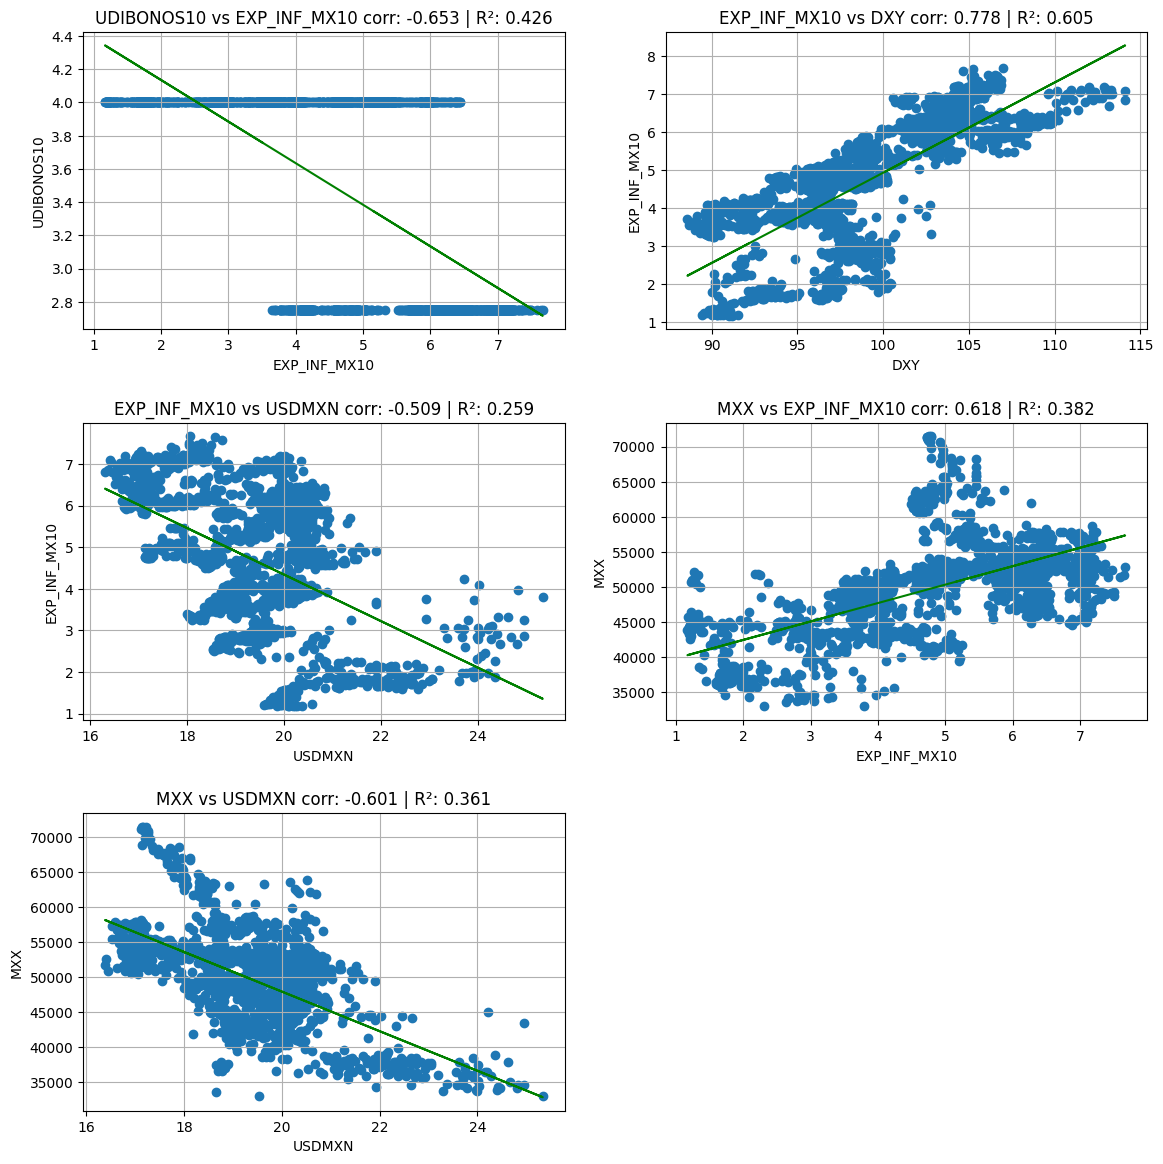

In [ ]:
results_mx10 = []
models_to_plot = []

for sec in securities_mx10:
    for bench in benchmarks_mx10:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries()
        m.compute_linear_reg(target_column='closing')
        
        results_mx10.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)

results_mx10 = pd.DataFrame(results_mx10)
results_mx10 = results_mx10.sort_values(by='correlation', ascending=False)

results_mx10


## Observaciones del periodo 2019-2021 
Bajo inflación esperada implícita de México a 10 años

,security,benchmark,beta,correlation,r2
5,MXX,EXP_INF_MX10,2649.714312,0.574762,0.330351
1,UDIBONOS10,DXY,0.079937,0.441041,0.194517
3,EXP_INF_MX10,DXY,0.052748,0.144569,0.020900
2,UDIBONOS10,USDMXN,0.012859,0.032645,0.001066
4,EXP_INF_MX10,USDMXN,-0.257454,-0.324871,0.105541
7,MXX,USDMXN,-1546.655069,-0.428623,0.183718
6,MXX,DXY,-773.056654,-0.459816,0.211431
0,UDIBONOS10,EXP_INF_MX10,-0.309626,-0.622839,0.387928


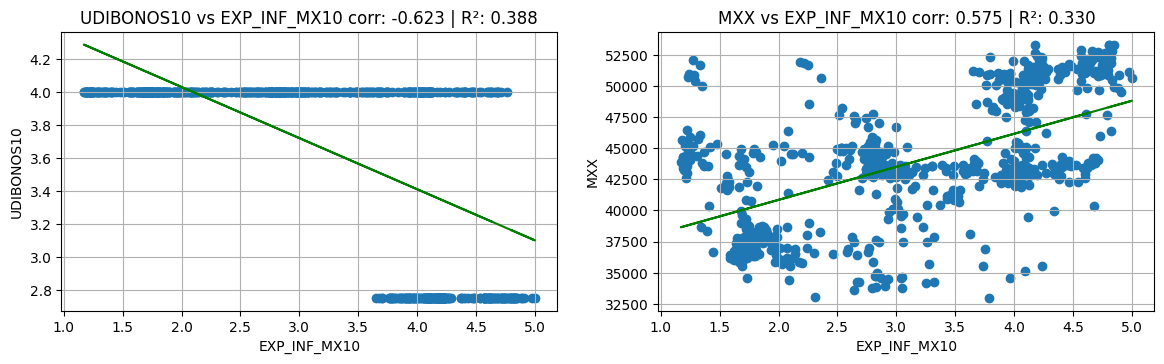

In [231]:
results_mx10 = []
models_to_plot = []

for sec in securities_mx10:
    for bench in benchmarks_mx10:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries(from_date='2019-01-01', to_date='2021-12-31')
        m.compute_linear_reg(target_column='closing')
        
        results_mx10.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)

results_mx10 = pd.DataFrame(results_mx10)
results_mx10 = results_mx10.sort_values(by='correlation', ascending=False)

results_mx10

## Observaciones del periodo de mayor estrés (abril de 2020 - diciembre 2020) 
Bajo inflación esperada implícita de México a 10 años

,security,benchmark,beta,correlation,r2
3,EXP_INF_MX10,DXY,0.107794,0.799211,0.638738
4,EXP_INF_MX10,USDMXN,0.245046,0.773251,0.597917
0,UDIBONOS10,EXP_INF_MX10,0.000000,0.000000,0.000000
1,UDIBONOS10,DXY,0.000000,0.000000,0.000000
2,UDIBONOS10,USDMXN,0.000000,0.000000,0.000000
5,MXX,EXP_INF_MX10,-3082.820922,-0.440954,0.194441
6,MXX,DXY,-476.602432,-0.503663,0.253676
7,MXX,USDMXN,-1246.737584,-0.552359,0.305100


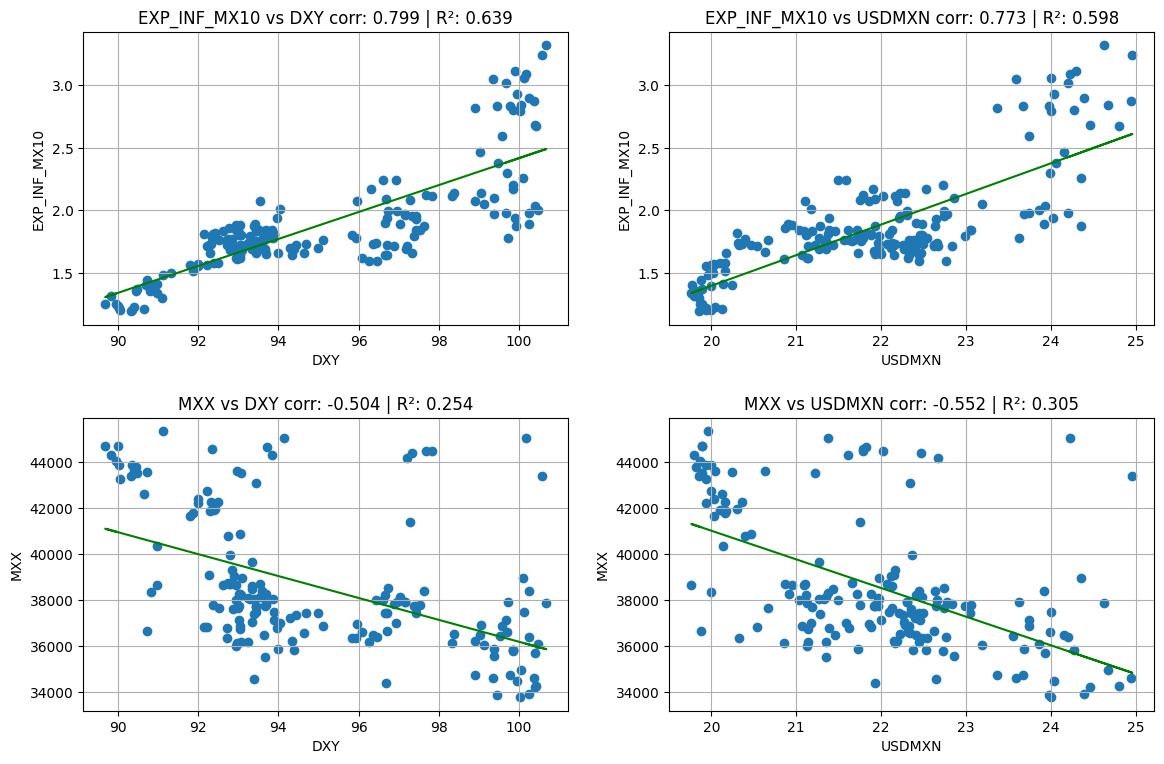

In [233]:
results_mx10 = []
models_to_plot = []

for sec in securities_mx10:
    for bench in benchmarks_mx10:
        if sec == bench:
            continue
        
        m = capm.model(sec, bench, 6)
        m.synchronise_timeseries(from_date='2020-04-01', to_date='2020-12-31')
        m.compute_linear_reg(target_column='closing')
        
        results_mx10.append({
            "security": sec,
            "benchmark": bench,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
        if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten()

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)

results_mx10 = pd.DataFrame(results_mx10)
results_mx10 = results_mx10.sort_values(by='correlation', ascending=False)

results_mx10

## Interpretación de resultados – México (Horizonte a 10 años) y contraste con 3 años

El análisis del horizonte de inflación esperada a 10 años en México permite profundizar en la dinámica estructural del mercado, ofreciendo un contraste particularmente valioso frente al comportamiento observado en el horizonte de 3 años. A diferencia de este últimon (más sensible a choques de corto plazo), el horizonte a 10 años captura componentes más persistentes y estructurales de las expectativas inflacionarias.


En el periodo amplio (2018–2026), se identifican relaciones relativamente sólidas y consistentes:

- **EXP_INF_MX10 vs DXY (corr aprox. 0.78, R² aprox. 0.60)**  
  Existe una relación positiva relevante, lo que sugiere que un fortalecimiento del dólar se asocia con mayores expectativas de inflación en México a largo plazo. Esto puede interpretarse como un reflejo de presiones externas y transmisión cambiaria hacia expectativas inflacionarias.

- **EXP_INF_MX10 vs USDMXN (corr aprox. -0.51)**  
  Relación negativa moderada, indicando que depreciaciones del peso no necesariamente se traducen linealmente en mayores expectativas inflacionarias a 10 años, lo que sugiere cierta credibilidad en la política monetaria de largo plazo.

- **UDIBONOS10 vs EXP_INF_MX10 (corr aprox. -0.65)**  
  Relación negativa clara, consistente con la lógica de tasas reales: mayores expectativas inflacionarias implican menores tasas reales observadas.

- **MXX (IPC) vs variables macro**  
  Se observan relaciones mixtas, con correlaciones moderadas, reflejando que el mercado accionario incorpora múltiples factores más allá de inflación y tipo de cambio.

Durante el periodo 2019–2021 a diferencia del horizonte de 3 años (donde las relaciones se debilitaban significativamente), en el horizonte de 10 años se observa:

- **Persistencia en relaciones clave (EXP_INF_MX10 vs DXY corr aprox. 0.80)**  
  La relación incluso se fortalece, lo que sugiere que las **expectativas de largo plazo permanecen ancladas a factores globales.**

- **EXP_INF_MX10 vs USDMXN (corr aprox. 0.77)**  
  Aumenta la sensibilidad al tipo de cambio, indicando que en contextos de incertidumbre, el canal cambiario gana relevancia incluso en horizontes largos.

- **Relaciones con MXX**  
  Se mantienen negativas y más definidas, sugiriendo que **el mercado accionario reacciona de forma más clara ante presiones macro**.

Mientras que en el horizonte de 3 años las relaciones se volvían difusas (corr aprox. 0 o inestables), aquí **no desaparecen**, sino que **se reconfiguran pero permanecen activas**.

Entonces..

El mercado de largo plazo **no pierde estructura**, incluso durante episodios de disrupción.

Durante el periodo de estrés emerge un resultado sumamente relevante:

- **EXP_INF_MX10 vs DXY (corr aprox. 0.80+)**
- **EXP_INF_MX10 vs USDMXN (corr aprox. 0.77)**
- **EXP_INF_MX10 vs UDIBONOS10 (relación negativa fuerte)**
- **MXX vs variables macro (relaciones más claras y definidas)**

En el horizonte de 10 años:
- **TODAS las variables relevantes se mantienen correlacionadas**
- El sistema **no colapsa en una sola dimensión**, sino que se vuelve **más cohesivo**


## Implicaciones para entender el mercado actual (2026)

Estos resultados son extremadamente útiles para interpretación práctica:

- Si hoy observamos movimientos en:
  - **DXY o USDMXN**
  - Podemos inferir impactos más claros en inflación esperada a 10 años que a 3 años

- Si hay incertidumbre:
  - El horizonte de 3 años mostrará ruido o cambios abruptos
  - El de 10 años mostrará **la verdadera narrativa estructural**

Si las relaciones se rompen en corto plazo pero no en largo es un ajuste de corto plazo dentro de una estructura estable

**El horizonte de 10 años revela que el mercado mexicano mantiene una estructura macro-financiera incluso en periodos de crisis, a diferencia del horizonte de 3 años donde dicha estructura puede fragmentarse temporalmente.**

**Esto confirma una idea central del proyecto:**  
Las relaciones macro-financieras no desaparecen en crisis, **cambian de forma dependiendo del horizonte temporal.**

# Motivación y estimación de la tasa real e inflación esperada a 5 años

El análisis de horizontes a 5 años responde a la necesidad de trabajar con variables financieras cuya referencia natural en mercado es sobre dicho plazo. En particular, los Credit Default Swaps (CDS) soberanos suelen cotizarse con mayor liquidez en el tramo a 5 años, por lo que resulta fundamental construir una medida consistente de inflación esperada y tasa real en ese mismo horizonte para realizar análisis econométricos coherentes.

Sin embargo, a diferencia de otros plazos como 3 o 10 años, no siempre se dispone de instrumentos indexados a la inflación (UDIBONOS) con vencimiento exacto a 5 años. Por ello, es necesario estimar la tasa real a dicho plazo a partir de la información disponible en la estructura temporal de tasas reales.

En este trabajo, la tasa real a 5 años se estimó mediante cuatro metodologías distintas:
* Interpolación Lineal
* Spline cúbico
* Modelo de Nelson-Siegel
* Modelo de Svensson

## Cálculo de la inflación esperada (breakeven)

Una vez estimada la tasa real a 5 años, la inflación esperada implícita se obtiene como:

$$
\pi^{e}_{5} = y^{nominal}_{5} - y^{real}_{5}
$$

donde:
- $$y^{nominal}_{5}$$: rendimiento de Bonos M a 5 años  
- $$y^{real}_{5}$$: tasa real estimada mediante los métodos anteriores  

Este diferencial, conocido como breakeven inflation, representa la expectativa de inflación implícita en el mercado para el horizonte de 5 años.

In [273]:
# Cargar series
udi3 = rrm.load_timeseries("UDIBONOS3", "Tasa")
udi10 = rrm.load_timeseries("UDIBONOS10", "Tasa")
bono5 = rrm.load_timeseries("BONOM5", "Cierre")

# Sincronizar
df = rrm.synchronise_timseries_df('UDIBONOS3', 'UDIBONOS10', "Tasa", "Tasa", name1="UDI3", name2="UDI10")
df = rrm.synchronise_timseries_df('UDIBONOS3','BONOM5', "Tasa", "Cierre", name1="UDI3", name2="BONO5")

# Ajustar nombres
df["UDI10"] = udi10["Tasa"]
df = df.dropna().reset_index(drop=True)

## 1. Interpolación lineal

Se asume que la tasa real evoluciona de manera lineal entre los nodos observados (3 y 10 años):

$$
y^{real}_{5} = y^{real}_{3} + \frac{5 - 3}{10 - 3} (y^{real}_{10} - y^{real}_{3})
$$

Esta aproximación es consistente con prácticas estándar en mercados de renta fija cuando la información es limitada.


In [287]:
def interp_linear(y3, y10, t=5):
    return y3 + (t - 3) / (10 - 3) * (y10 - y3)

df["real_5_linear"] = interp_linear(df["UDI3"], df["UDI10"])
df["EXP_INF_linear"] = df["BONO5"] - df["real_5_linear"]

## 2. Spline cúbico

Se ajusta una función polinómica por tramos que garantiza suavidad en la curva de tasas:

$$
S(t) = a + b(t - t_i) + c(t - t_i)^2 + d(t - t_i)^3
$$

sujeta a condiciones de continuidad en nivel, pendiente y curvatura.

Este método permite capturar curvaturas en la estructura temporal, aunque con pocos nodos tiende a aproximarse a una interpolación lineal.

In [288]:
from scipy.interpolate import CubicSpline

def spline_real_rate(y3, y10):
    x = np.array([3, 10])
    y = np.array([y3, y10])
    
    cs = CubicSpline(x, y, bc_type='natural')
    return cs(5)

df["real_5_spline"] = df.apply(lambda row: spline_real_rate(row["UDI3"], row["UDI10"]), axis=1)
df["EXP_INF_spline"] = df["BONO5"] - df["real_5_spline"]

## 3. Modelo de Nelson-Siegel

Se utiliza una parametrización funcional ampliamente empleada en la modelación de curvas de rendimiento:

$$
y(t) = \beta_0 + \beta_1 \left( \frac{1 - e^{-t/\tau}}{t/\tau} \right) + 
\beta_2 \left( \frac{1 - e^{-t/\tau}}{t/\tau} - e^{-t/\tau} \right)
$$

donde:
- $$\beta_0$$: nivel de largo plazo  
- $$\beta_1$$: pendiente  
- $$beta_2$$: curvatura  
- $$\tau$$: parámetro de decaimiento  

Este modelo permite capturar de forma parsimoniosa la forma de la curva de tasas.


In [289]:
from scipy.optimize import minimize

def nelson_siegel(t, beta0, beta1, beta2, tau):
    return beta0 + beta1 * ((1 - np.exp(-t/tau)) / (t/tau)) + \
           beta2 * (((1 - np.exp(-t/tau)) / (t/tau)) - np.exp(-t/tau))

def fit_ns(y3, y10):
    def objective(params):
        beta0, beta1, beta2, tau = params
        err = (
            (nelson_siegel(3, beta0, beta1, beta2, tau) - y3)**2 +
            (nelson_siegel(10, beta0, beta1, beta2, tau) - y10)**2
        )
        return err

    initial = [y10, -1, 1, 1]
    res = minimize(objective, initial, bounds=[(-10,10),(-10,10),(-10,10),(0.1,10)])
    return res.x

def ns_rate_5(y3, y10):
    beta0, beta1, beta2, tau = fit_ns(y3, y10)
    return nelson_siegel(5, beta0, beta1, beta2, tau)

df["real_5_ns"] = df.apply(lambda row: ns_rate_5(row["UDI3"], row["UDI10"]), axis=1)
df["EXP_INF_ns"] = df["BONO5"] - df["real_5_ns"]

## 4. Modelo de Svensson

Extensión del modelo de Nelson-Siegel que introduce mayor flexibilidad:

$$
y(t) = \beta_0 + \beta_1 f_1(t) + \beta_2 f_2(t) + \beta_3 f_3(t)
$$

donde:

$$
f_1(t) = \frac{1 - e^{-t/\tau_1}}{t/\tau_1}, \quad
f_2(t) = f_1(t) - e^{-t/\tau_1}, \quad
f_3(t) = \frac{1 - e^{-t/\tau_2}}{t/\tau_2} - e^{-t/\tau_2}
$$

Este modelo permite capturar estructuras más complejas en la curva de tasas.


In [290]:
def svensson(t, beta0, beta1, beta2, beta3, tau1, tau2):
    term1 = (1 - np.exp(-t/tau1)) / (t/tau1)
    term2 = term1 - np.exp(-t/tau1)
    term3 = ((1 - np.exp(-t/tau2)) / (t/tau2)) - np.exp(-t/tau2)
    
    return beta0 + beta1*term1 + beta2*term2 + beta3*term3

def fit_svensson(y3, y10):
    def objective(params):
        beta0, beta1, beta2, beta3, tau1, tau2 = params
        err = (
            (svensson(3, *params) - y3)**2 +
            (svensson(10, *params) - y10)**2
        )
        return err

    initial = [y10, -1, 1, 1, 1, 2]
    bounds = [(-10,10),(-10,10),(-10,10),(-10,10),(0.1,10),(0.1,10)]
    
    res = minimize(objective, initial, bounds=bounds)
    return res.x

def sv_rate_5(y3, y10):
    params = fit_svensson(y3, y10)
    return svensson(5, *params)

df["real_5_sv"] = df.apply(lambda row: sv_rate_5(row["UDI3"], row["UDI10"]), axis=1)
df["EXP_INF_sv"] = df["BONO5"] - df["real_5_sv"]

### Consideraciones metodológicas

Dado que la estimación se realiza con un número limitado de nodos (3 y 10 años), los modelos paramétricos (Nelson-Siegel y Svensson) pueden presentar problemas de sobreajuste. No obstante, su inclusión permite contrastar resultados y evaluar la sensibilidad de las estimaciones frente a distintas metodologías.

*Entonces se recomienda usar los resultados de interpolación lineal como benchmark y usar los de Nelson-Siegel como extensión metodológica.*

In [291]:
horizonte_5 = df[[
    "Fecha",
    "real_5_linear",
    "real_5_spline",
    "real_5_ns",
    "real_5_sv",
    "EXP_INF_linear",
    "EXP_INF_spline",
    "EXP_INF_ns",
    "EXP_INF_sv"
]]
print(horizonte_5)

          Fecha  real_5_linear       real_5_spline  real_5_ns  real_5_sv  \
0    2018-01-02       2.928571  2.9285714285714284   3.118386   3.099181   
1    2018-01-03       2.928571  2.9285714285714284   3.118386   3.099181   
2    2018-01-04       2.928571  2.9285714285714284   3.118386   3.099181   
3    2018-01-05       2.928571  2.9285714285714284   3.118386   3.099181   
4    2018-01-08       2.928571  2.9285714285714284   3.118386   3.099181   
...         ...            ...                 ...        ...        ...   
2031 2026-03-23       4.000000                 4.0   4.014484   4.059526   
2032 2026-03-24       4.000000                 4.0   4.014484   4.059526   
2033 2026-03-25       4.000000                 4.0   4.014484   4.059526   
2034 2026-03-26       4.000000                 4.0   4.014484   4.059526   
2035 2026-03-27       4.000000                 4.0   4.014484   4.059526   

      EXP_INF_linear EXP_INF_spline  EXP_INF_ns  EXP_INF_sv  
0           4.581429     

In [292]:
rrm.cargar_archivo(horizonte_5, 'HORIZONTE5')

Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/HORIZONTE5.csv


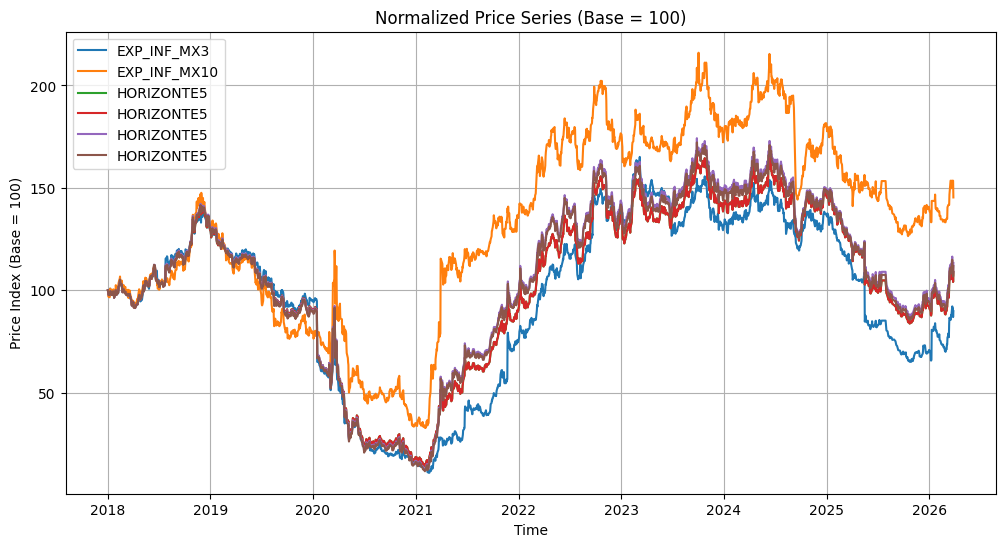

In [293]:
rics = ['EXP_INF_MX3', 'EXP_INF_MX10','HORIZONTE5','HORIZONTE5','HORIZONTE5','HORIZONTE5']
columns = ['Diferencia', 'Diferencia', 'EXP_INF_linear', 'EXP_INF_spline', 'EXP_INF_ns', 'EXP_INF_sv']
rrm.plot_normalized_timeseries(rics, columns, )


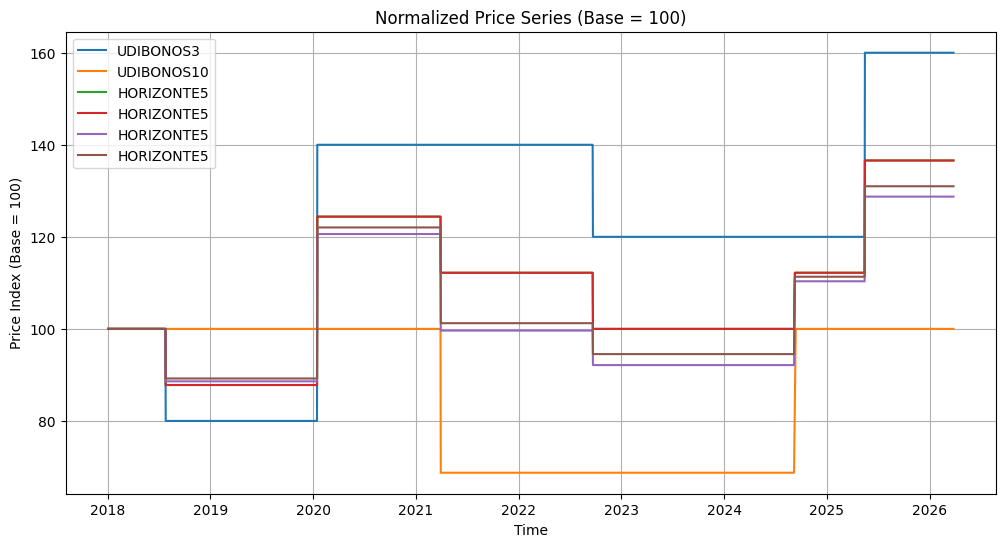

In [282]:
rics = ['UDIBONOS3', 'UDIBONOS10','HORIZONTE5','HORIZONTE5','HORIZONTE5','HORIZONTE5']
columns = ['Tasa', 'Tasa', 'real_5_linear', 'real_5_spline', 'real_5_ns', 'real_5_sv']
rrm.plot_normalized_timeseries(rics, columns)

# Motivación del uso de CDS a 5 años y enfoque econométrico

El Credit Default Swap (CDS) es un instrumento financiero derivado que permite medir el riesgo de incumplimiento de un emisor. En el caso de deuda soberana, el CDS refleja la prima que el mercado exige para asegurar la deuda de un país ante un posible evento de crédito.

El CDS a 5 años es el punto de referencia más líquido y representativo en los mercados internacionales, por lo que se utiliza comúnmente como indicador del riesgo país. Su dinámica incorpora información sobre condiciones macroeconómicas, expectativas de inflación, tasas de interés y percepción de riesgo global.

En este contexto, resulta de particular interés analizar la relación entre:

- Inflación esperada a 5 años  
- Tasa real a 5 años  
- CDS soberano a 5 años  

La motivación principal es identificar si las condiciones macrofinancieras internas, reflejadas en la inflación implícita y la tasa real, tienen poder explicativo sobre la percepción de riesgo país.

---

Realizaremos un análisis gráfico (ploteo de series) para observar la dinámica conjunta de:

- CDS 5Y  
- Inflación esperada 5Y  
- Tasa real 5Y  

Esto permitirá identificar patrones visuales, comovimientos y posibles cambios de régimen.

Posteriormente, se estimarán modelos de regresión lineal con el objetivo de cuantificar la relación entre variables.

### Interpretación esperada

Desde una perspectiva económica:

- Un aumento en la inflación esperada podría reflejar desequilibrios macroeconómicos, incrementando el riesgo país.
- Una mayor tasa real podría estar asociada a condiciones monetarias más restrictivas o mayor prima por riesgo.


El análisis permitirá determinar si estas variables contienen información relevante para explicar la evolución del CDS y, por ende, la percepción de riesgo soberano y su comportamiento en pandemia.

Este enfoque integra información de mercados de renta fija y derivados, permitiendo construir una visión más completa del entorno macrofinanciero y su impacto sobre el riesgo país en un horizonte clave de 5 años.

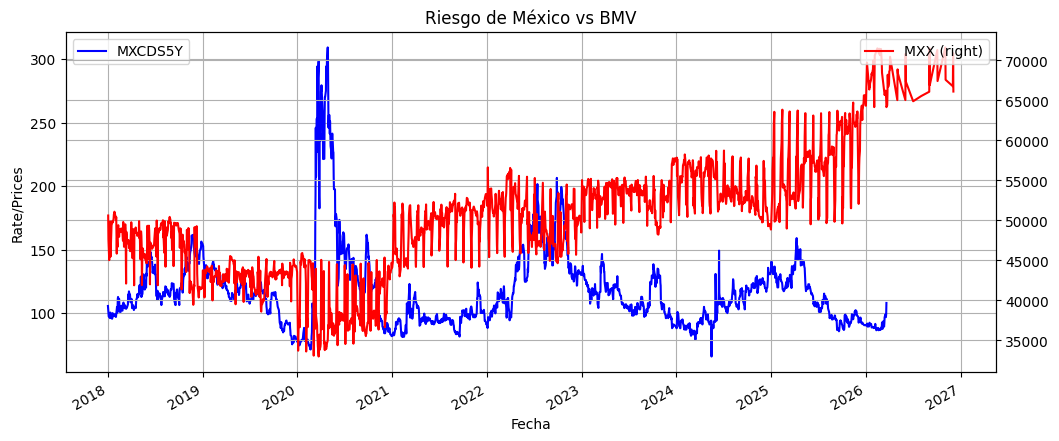

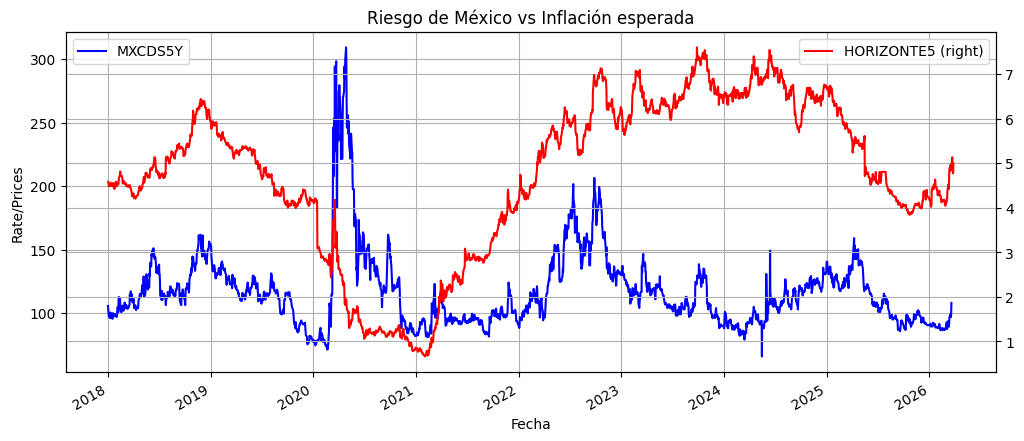

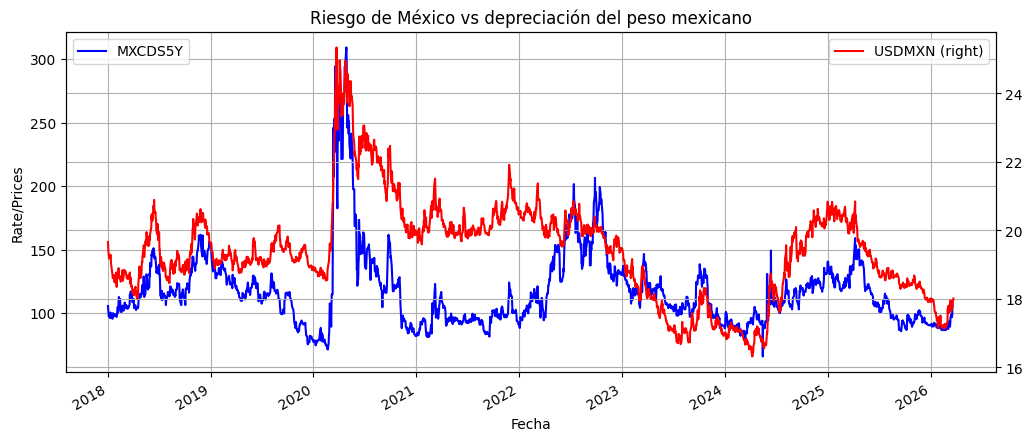

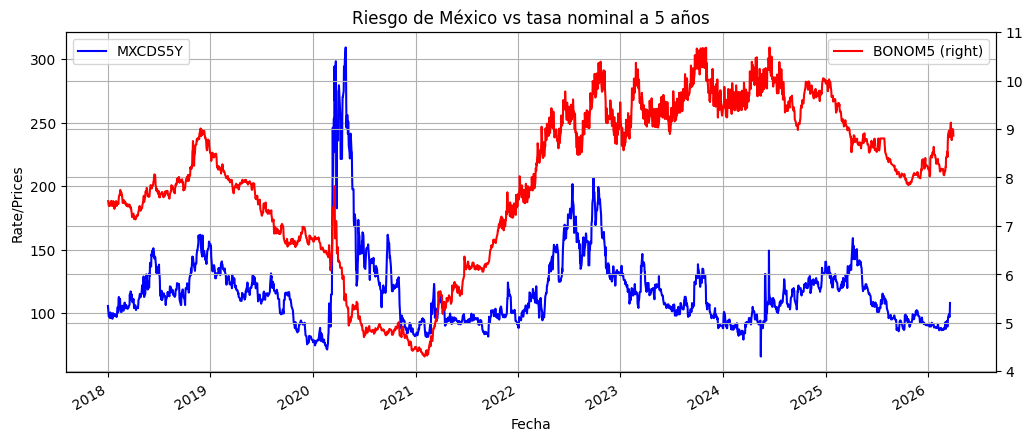

In [298]:
# 'MXCDS5Y', 'MXX', 'HORIZONTE5', 'USDMXN', 'BONOM5'
rrm.plot_two_timeseries('MXCDS5Y', 'MXX', 'Cierre', 'Cierre', titulo = 'Riesgo de México vs BMV')
rrm.plot_two_timeseries('MXCDS5Y', 'HORIZONTE5', 'Cierre', 'EXP_INF_linear', titulo = 'Riesgo de México vs Inflación esperada')
rrm.plot_two_timeseries('MXCDS5Y', 'USDMXN', 'Cierre', 'Cierre', titulo = 'Riesgo de México vs depreciación del peso mexicano')
rrm.plot_two_timeseries('MXCDS5Y', 'BONOM5', 'Cierre', 'Cierre', titulo = 'Riesgo de México vs tasa nominal a 5 años')

# Evaluación estadística - Riesgo en México vs variables macro-financieras e índices
Se realiza bajo un horizonte a 5 años

,security,benchmark,beta,correlation,r2
2,USDMXN,MXCDS5Y,0.029254,0.616108,0.379589
4,DXY,MXCDS5Y,0.051459,0.301687,0.091015
7,EXP_INF_MX3,MXCDS5Y,0.005223,0.078110,0.006101
3,BONOM5,MXCDS5Y,0.002271,0.043612,0.001902
1,HORIZONTE5,MXCDS5Y,0.002311,0.039939,0.001595
8,EXP_INF_MX10,MXCDS5Y,0.001163,0.022228,0.000494
9,GOLD,MXCDS5Y,-5.666984,-0.215314,0.046360
5,EXP_INF_USA5,MXCDS5Y,-0.005954,-0.361670,0.130805
6,EXP_INF_USA10,MXCDS5Y,-0.004332,-0.372068,0.138435
0,MXX,MXCDS5Y,-109.024613,-0.474799,0.225434


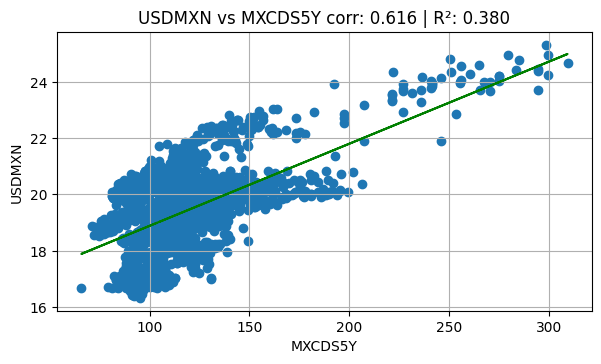

In [ ]:
securities = ['MXX', 'HORIZONTE5', 'USDMXN', 'BONOM5', 'DXY', 'EXP_INF_USA5', 'EXP_INF_USA10', 'EXP_INF_MX3', 'EXP_INF_MX10', 'GOLD']
benchmark = 'MXCDS5Y'
results = []
models_to_plot = []

for sec in securities:
    m = capm.model(sec, benchmark, 6)
    m.synchronise_timeseries()
    m.compute_linear_reg(target_column='closing')
        
    results.append({
            "security": sec,
            "benchmark": benchmark,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
    if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten() # Cuida la parte de ser un único caso el que cumple

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)

results = pd.DataFrame(results)
results = results.sort_values(by='correlation', ascending=False)

results

## Año de mayor estrés 2020 - Pandemia

,security,benchmark,beta,correlation,r2
2,USDMXN,MXCDS5Y,0.025776,0.903796,0.816848
4,DXY,MXCDS5Y,0.031223,0.602821,0.363393
8,EXP_INF_MX10,MXCDS5Y,0.004414,0.445556,0.198520
3,BONOM5,MXCDS5Y,0.001957,0.147282,0.021692
1,HORIZONTE5,MXCDS5Y,0.001212,0.081834,0.006697
7,EXP_INF_MX3,MXCDS5Y,0.000849,0.050313,0.002531
0,MXX,MXCDS5Y,-33.237764,-0.580290,0.336736
6,EXP_INF_USA10,MXCDS5Y,-0.004260,-0.859360,0.738500
5,EXP_INF_USA5,MXCDS5Y,-0.006027,-0.890608,0.793183


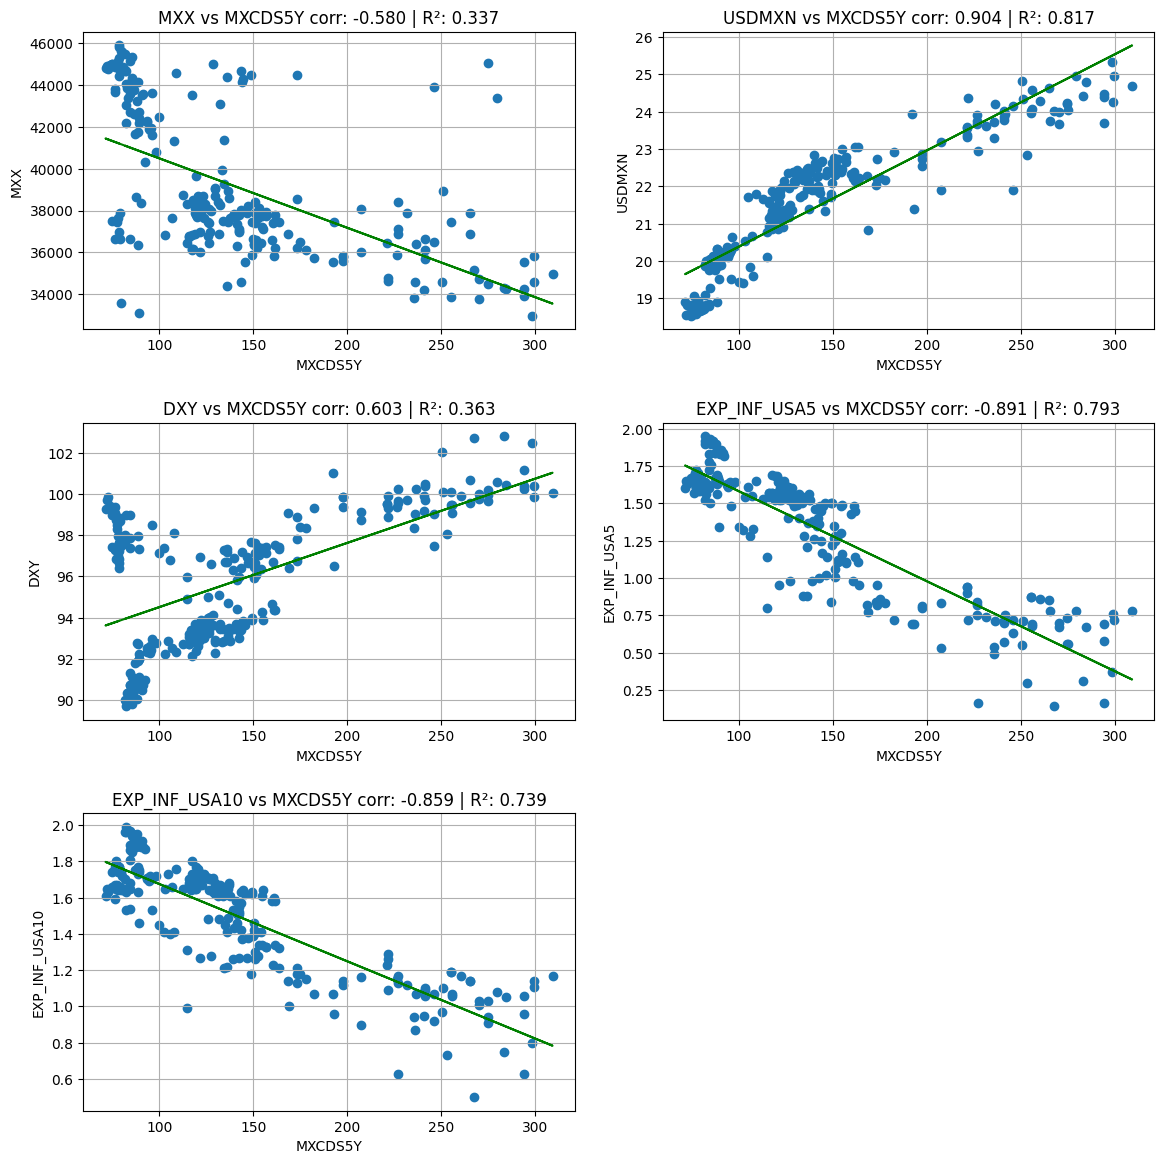

In [ ]:
securities = ['MXX', 'HORIZONTE5', 'USDMXN', 'BONOM5', 'DXY', 'EXP_INF_USA5', 'EXP_INF_USA10', 'EXP_INF_MX3', 'EXP_INF_MX10']
benchmark = 'MXCDS5Y'
results = []
models_to_plot = []

for sec in securities:
    m = capm.model(sec, benchmark, 6)
    m.synchronise_timeseries(from_date='2020-01-01', to_date='2020-12-31')
    m.compute_linear_reg(target_column='closing')
        
    results.append({
            "security": sec,
            "benchmark": benchmark,
            "beta": m.beta,
            "correlation": m.correlation,
            "r2": m.r_squared
        })
    if abs(m.correlation) >= 0.5:
            models_to_plot.append(m)

# Graficos
n = len(models_to_plot)

if n == 0:
    print("No hay modelos que cumplan el criterio para graficar")
else:
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.atleast_1d(axes).flatten() # Cuida la parte de ser un único caso el que cumple

    for i, m in enumerate(models_to_plot):
        m.plot_linear_reg(ax=axes[i])

    # eliminar ejes sobrantes
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout(pad=2.0)

results = pd.DataFrame(results)
results = results.sort_values(by='correlation', ascending=False)#

results

CONCLUSIONES

# Análisis de activos normalizados (Base 100) durante el shock de 2020

Como complemento al análisis, se construyen series normalizadas base 100 para distintos activos financieros, con el objetivo de comparar su desempeño relativo a lo largo del tiempo. Los activos considerados incluyen:

* DXY: Índice del dólar estadounidense frente a una canasta de divisas (nivel)
* TNX: Rendimiento del bono del Tesoro de EE.UU. a 10 años (yield) - Equivalente a utilizar DGS10
* US02Y: Rendimiento del bono del Tesoro a 2 años (yield)
* GOLD: Precio del oro (activo refugio)
* NASDAQC: Índice tecnológico Nasdaq Composite (equity)
* TLT: ETF de bonos del Tesoro de largo plazo - *Nominal* (precio) - Precios compuestos de T Notes a 20 años + T Bonds
* USD/MXN: Tipo de cambio peso-dólar (nivel)

**Esta herramienta permite identificar patrones diferenciados de comportamiento entre activos durante periodos normales y de crisis, aportando una visión más integral del entorno financiero.**

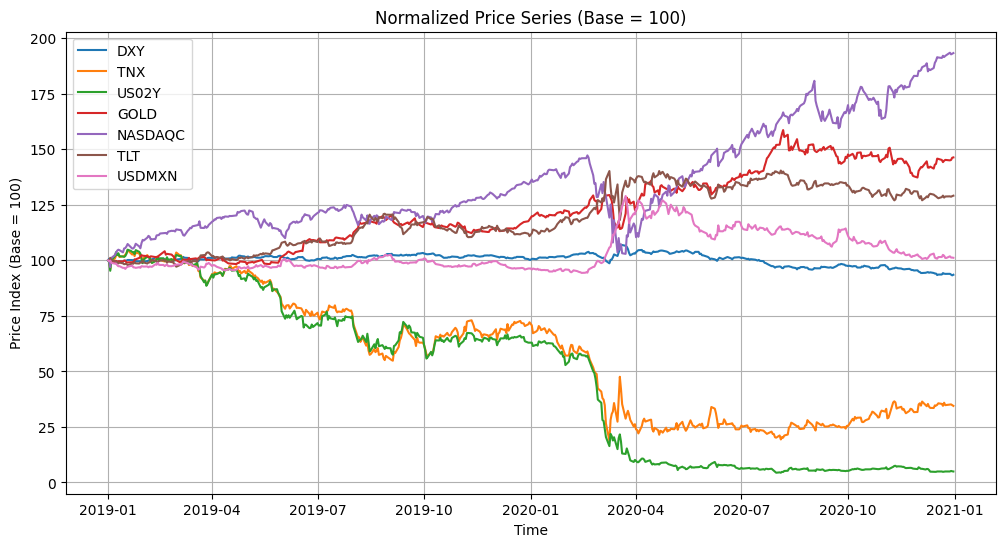

In [307]:
from Quant_Finance_Project.capm import plot_normalized_timeseries
rics = ["DXY","TNX", "US02Y", "GOLD", "NASDAQC", "TLT", 'USDMXN']

plot_normalized_timeseries(
    rics,
    from_date="2019-01-01",
    to_date='2020-12-31',
    base_value=100
)

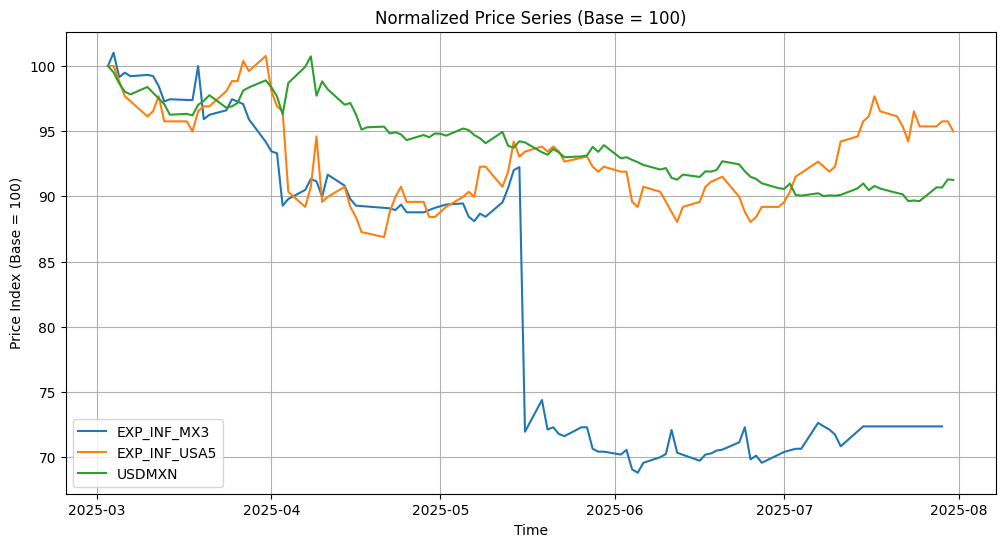

In [288]:
rics = ["EXP_INF_MX3","EXP_INF_USA5", 'USDMXN']

plot_normalized_timeseries(
    rics,
    from_date="2025-03-01",
    to_date='2025-07-31',
    base_value=100
)

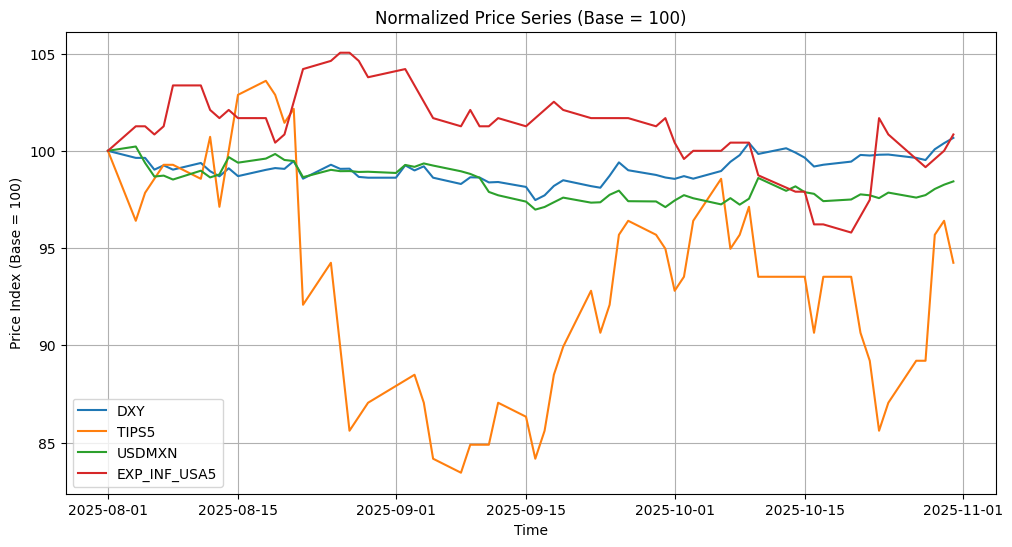

In [290]:
rics = ["DXY","TIPS5", 'USDMXN', 'EXP_INF_USA5']

plot_normalized_timeseries(
    rics,
    from_date="2025-08-01",
    to_date='2025-10-31',
    base_value=100
)

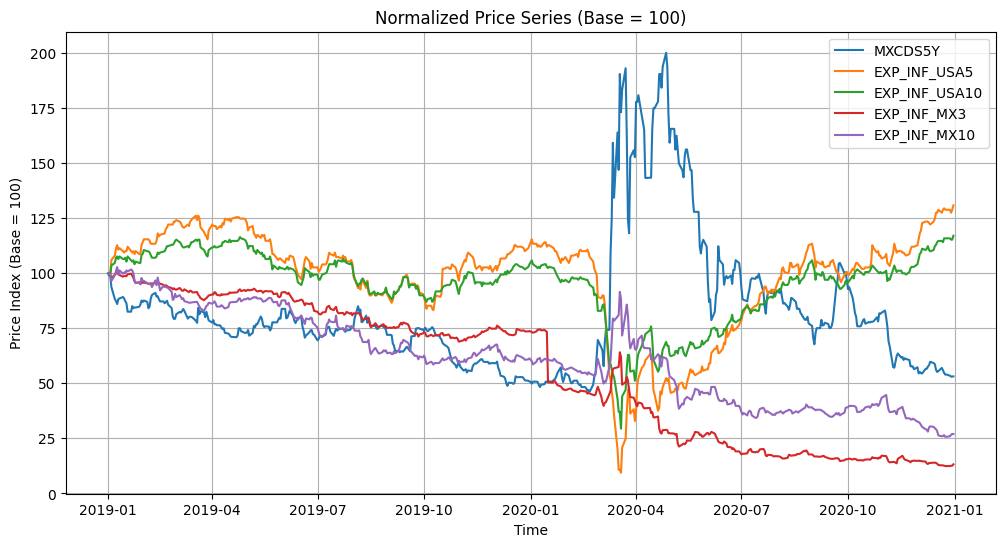

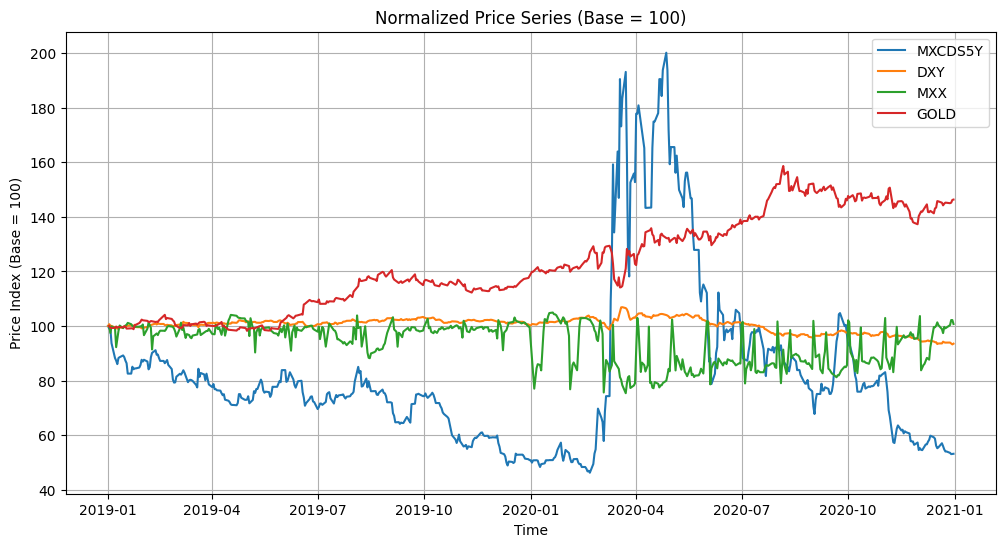

In [313]:
rics = ["MXCDS5Y", "EXP_INF_USA5", "EXP_INF_USA10", 'EXP_INF_MX3', 'EXP_INF_MX10']

plot_normalized_timeseries(
    rics,
    from_date="2019-01-01",
    to_date='2020-12-31',
    base_value=100
)

rics = ["MXCDS5Y","DXY", "MXX", "GOLD"]

plot_normalized_timeseries(
    rics,
    from_date="2019-01-01",
    to_date='2020-12-31',
    base_value=100
)

*Observemos el comportamiento de nuestros índices y variables macro, ¿Su comportamiento es el esperado antes, durante y despues del periodo de mayor estrés?*

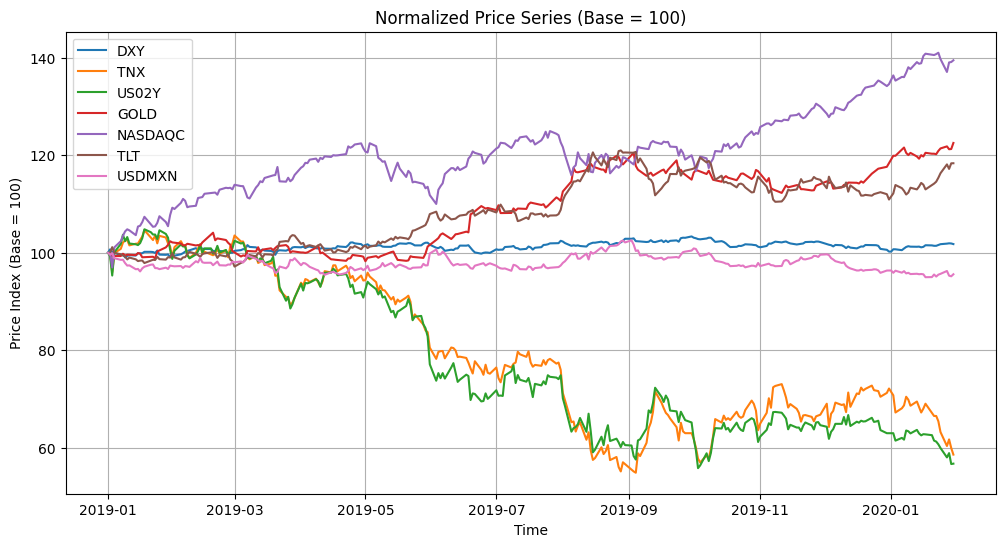

In [38]:
rics = ["DXY","TNX", "US02Y", "GOLD", "NASDAQC", "TLT", 'USDMXN']
plot_normalized_timeseries(
    rics,
    from_date="2019-01-01",
    to_date='2020-01-30',
    base_value=100
)

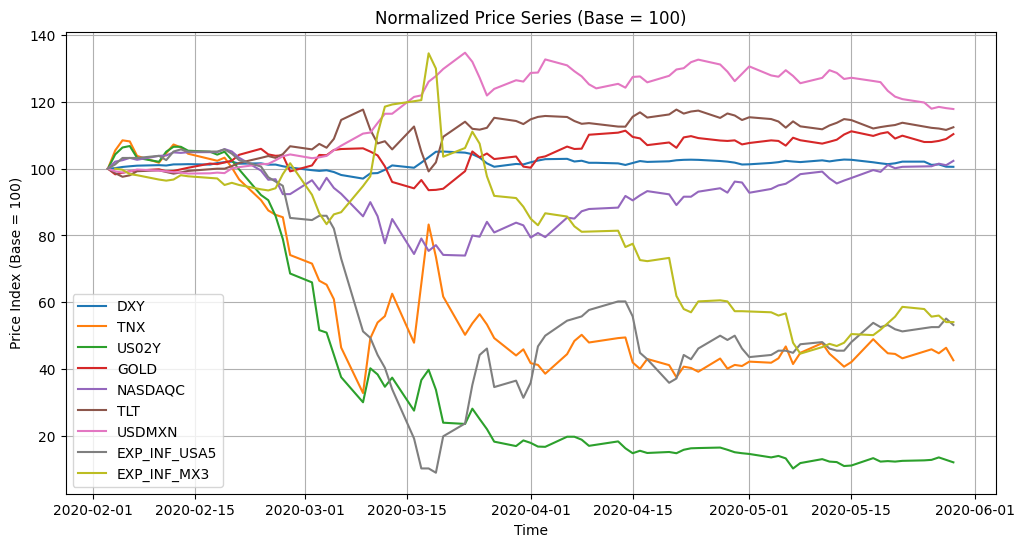

In [80]:
rics = ["DXY","TNX", "US02Y", "GOLD", "NASDAQC", "TLT", 'USDMXN', 'EXP_INF_USA5', 'EXP_INF_MX3']
plot_normalized_timeseries(
    rics,
    from_date="2020-02-01",
    to_date='2020-05-30',
    base_value=100
)

El análisis de series normalizadas permite comparar el comportamiento relativo de distintos activos financieros durante el periodo de estrés asociado a la pandemia de COVID-19, identificando dinámicas consistentes con episodios de aversión al riesgo.

### Observaciones

* **Fortalecimiento del dólar (DXY):**
  Durante el periodo de mayor incertidumbre, el dólar muestra un comportamiento relativamente estable con ligera apreciación, consistente con su rol como activo refugio global en episodios de estrés financiero.

* **Depreciación del peso mexicano (USD/MXN):**
  Se observa un incremento significativo, reflejando salida de capitales de mercados emergentes y mayor percepción de riesgo. Este comportamiento es coherente con dinámicas típicas de crisis globales.

* **Caída pronunciada en tasas de interés (TNX y US02Y):**
  Los yields de bonos del Tesoro caen de forma abrupta, lo que implica:

  * Incremento en el precio de los bonos (flight to quality)
  * Intervención monetaria agresiva por parte de la Reserva Federal
    Este punto es clave: no es debilidad, sino **demanda por activos seguros**.

* **Comportamiento del oro (GOLD):**
  Inicialmente presenta volatilidad y ligera caída, pero posteriormente se recupera, lo cual es consistente con:

  * Venta inicial por liquidez (margin calls)
  * Posterior posicionamiento como activo refugio ante expansión monetaria

* **Mercado accionario (NASDAQ):**
  Muestra una caída inicial seguida de una recuperación relativamente rápida, sugiriendo:

  * Shock de corto plazo por incertidumbre
  * Revaluación posterior impulsada por liquidez y expectativas

* **Bonos de largo plazo (TLT):**
  Presentan un aumento durante la crisis, consistente con la caída en yields. Esto refuerza la narrativa de búsqueda de seguridad por parte de inversionistas.

### Interpretación económica

El conjunto de estos movimientos es consistente con un entorno de **aversión al riesgo global**, caracterizado por:

* Salida de capital de mercados emergentes hacia activos seguros
* Caída en tasas de interés por política monetaria expansiva
* Incremento en la demanda por liquidez en dólares
* Reconfiguración temporal de portafolios hacia activos refugio

**Este comportamiento es coherente con los resultados econométricos previos, donde se identificó que las relaciones entre variables macro-financieras cambian de forma significativa bajo condiciones de estrés.**



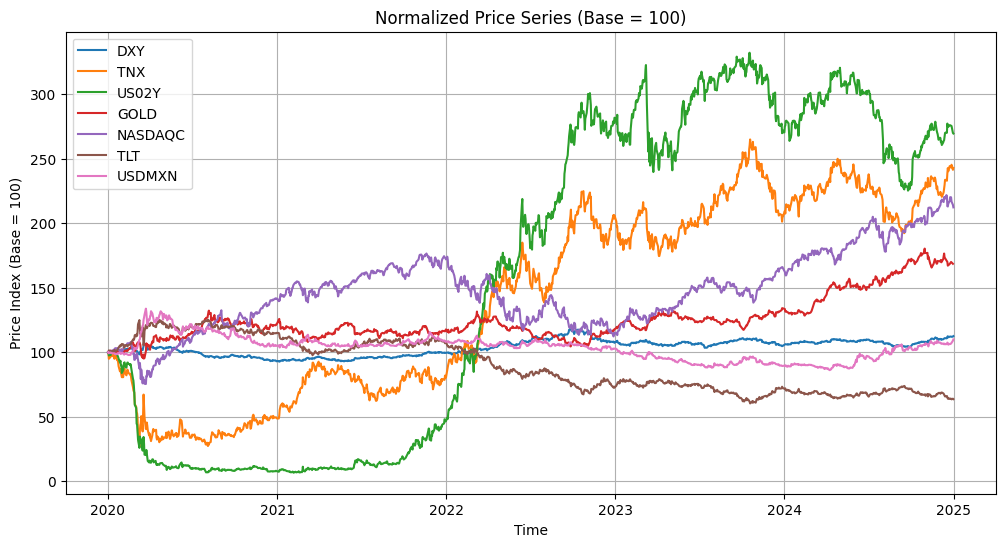

In [110]:
plot_normalized_timeseries(
    rics,
    from_date="2020-01-01",
    to_date='2024-12-31',
    base_value=100
)

## Dinámica post-crisis y persistencia de efectos en los activos

Posterior al periodo de pánico observado en marzo–abril de 2020, los mercados financieros muestran un proceso de estabilización progresiva. Sin embargo, esta estabilización no implica necesariamente un retorno a las condiciones previas, sino en muchos casos la transición hacia un nuevo régimen de mercado.

### Análisis por activo

* **DXY (índice del dólar):**
  Tras el fortalecimiento inicial impulsado por la demanda de liquidez global, el dólar muestra una estabilización e incluso ligera reversión. Esto sugiere que el shock fue principalmente de corto plazo (flight to liquidity), y no un cambio estructural en su tendencia.

* **USD/MXN:**
  Después de la depreciación abrupta del peso mexicano, el tipo de cambio muestra una corrección parcial, pero no regresa completamente a niveles previos. Esto indica que parte del movimiento refleja un ajuste más persistente en la percepción de riesgo sobre mercados emergentes.

* **TNX (yield 10 años) y US02Y (yield 2 años):**
  Los yields presentan una caída estructural durante la crisis y posteriormente una recuperación gradual, pero permanecen en niveles relativamente bajos durante un periodo prolongado. Esto refleja:

  * Política monetaria expansiva sostenida
  * Expectativas de crecimiento e inflación contenidas en el corto plazo

* **TLT (bonos de largo plazo):**
  Tras el aumento inicial (caída de yields), los precios comienzan a estabilizarse y eventualmente a corregir conforme los yields se recuperan. Esto es consistente con la normalización parcial de condiciones financieras.

* **GOLD (oro):**
  Después de la volatilidad inicial, el oro entra en una tendencia alcista sostenida, reflejando:

  * Expansión monetaria
  * Cobertura contra inflación y riesgo sistémico

* **NASDAQ (mercado accionario):**
  Presenta una recuperación fuerte y sostenida tras la caída inicial, superando niveles pre-crisis. Esto sugiere:

  * Alta sensibilidad a condiciones de liquidez
  * Revaluación de activos de riesgo en un entorno de tasas bajas

### Interpretación económica

El periodo posterior a la crisis no representa simplemente una reversión al estado previo, sino una transición hacia un entorno caracterizado por:

* Mayor liquidez global
* Tasas de interés estructuralmente más bajas (al menos en el corto/mediano plazo post-crisis)
* Mayor diferenciación entre activos de riesgo y refugio
* Persistencia de efectos en economías emergentes



## Conexión con el entorno actual - REVISAR (POR LOS PROCEDIMIENTOS DEL SIGUIENTE PUNTO, VER SI CONCUERDA)

El análisis de series normalizadas permite observar que, ante un shock extremo como el de 2020, los distintos activos financieros reaccionan de manera abrupta, reflejando un proceso de ajuste generalizado en los mercados.

Sin embargo, a diferencia de lo que podría inferirse a partir de la magnitud del movimiento inicial, la evidencia no sugiere de forma concluyente una reconfiguración estructural permanente en las relaciones entre variables. En cambio, los resultados apuntan a un proceso de desajuste temporal seguido de una fase de estabilización.

En este contexto, es posible identificar que:

* Los mercados reaccionan de forma no lineal ante episodios de estrés
* Las relaciones entre variables pueden intensificarse transitoriamente sin volverse estructurales
* La aparente estabilidad posterior refleja un proceso de absorción del shock más que un cambio definitivo en la dinámica subyacente

Este comportamiento es consistente con los hallazgos econométricos del proyecto, donde se observa que, si bien existen variaciones en la intensidad de las relaciones macro-financieras durante periodos de crisis, no siempre hay evidencia suficiente para afirmar cambios estructurales permanentes.

En este sentido, el episodio de 2020 puede interpretarse como un evento de estrés que amplifica dinámicas existentes, más que como un punto de ruptura definitivo en el funcionamiento del sistema financiero.


En conjunto, estos resultados refuerzan la idea central del proyecto:**las relaciones macro-financieras no son constantes, sino que cambian dependiendo del contexto, particularmente en episodios de alta incertidumbre. Esto justifica la necesidad de analizar los datos bajo distintos regímenes y considerar herramientas metodológicas más avanzadas en etapas posteriores del estudio.**


# exp_inflacion calculos con 10 años en usa, cambian? - HECHO 

# Que sucedió en mexico, usar sus datos - HECHO

# horizonte de mexico a 5 años - FALTAN CONCLUSIONES - SORPRESA, esta mas correlacionada con macro variables de eua como la inflación, mas que con México - DIVIDIR REAL E INFLACIÓN EN CSV DISTINTOS

# combinacion de infromacion macro financierea de eua vs mexico, como fue, como se comporto cada uno frente a la crsiis de pandemia! tasa reales, nomiales e inflacion unicamente. 

# pasar a analisis actual con los resultados previos... HAY QUE TENER CUIDADO, NUESTRO ANALISIS DE COVID NOS LLEVÓ A TENER CUIDADO CON LAS CPRRELACIONES PUES ESTAS PUEDEN CAMBIAR DE SIGNO como se vió en crisis, ejemplo EXP10MX VS USDMXN Y OTRA COSA ES... DXY NO TENDRÁ LAS MISMAS RELACIONES QUE USDMXN, SIN EMBARGO BAJO PERIODOS PUEDE LLEGAR A TENER LA MISMA - SE DICE que dxy tiene mayor influencia, el cual mueve a usdmxn PERO lo mueve al doble, ya que usdmxn a dxy no lo mueve, dxy no se relaciona con MX, dado esto... ahora si trabajar con el siguiente punto de normalización: 
Por supuesto hay realciones robustas... como la de ORO vs DOLAR o TASA REAL VS DOLAR QUE SE MANTUVIERON EN PANDEMIA Y EN PERIODOS COMPLETOS/NORMALES DESDE 2018 A 2026 decimos... estos se obtuvieron en el modelo? prueba esetadistica? ... revisar tasa real vs dolar para ver si no se rompió en los 2 horzizontes de eua - SOLO SUCEDIO EN LA DE 10 AÑOS, EN 5 AÑOS NO SUCEDIÓ, SE PERDIÓ ESA CORRELACIÓN! ENTONESSSSS ESO NOS INDICA A TENER CUIDADO CON QUE HORIZONTES USAR EN ANALISIS Y RECOMEDNACION CON NORMALIZACIÓN PERO ES RARO PORQUE TIPS5 Y TIPS 10 SE CORRELACIONANA FUERTEMENTE... PERO EN PANDEMIA QUE PASÓ - CUIDADO QUE... EL PROBLEMA ESTÁ EN QUE USAMOS DE INICIO EN 5Y RETURNS Y NO CLOSINGS.... eh ahí el problema aunque vaya, **la solución es re hacer horizonte 5 pero asegurando usar closing simplemente y dar de nuevo una interpretación Y VERIFICAR QUE ASI LO SEA PARA TODOS...**
Pero entonces... usar closing es correcto?... para nuestro analisis... en general estaríamos o pdoriamos perder la orginalidad y lo correcto de usar returns, en lugar de closing 
# usar normalizacion, tasas con tasas, precios con precios, inflacion con inflacion, mexico vs usa, hacer combinaciones LIMPIAS - FALTA COMENTARIOS

# INPC analisis para predicciones, es decir analizar sobre temporalidades ceercanas y posteriores a covid como se comporto, base enero, como se comportó mes_Act vs mes previo, var mensual

# INPC como se ve/relaciona/FUNCIONARÍA respecto a el expected... se puede a pesar de que la temporalidad base del expectes es de 5 años


# spreads entre usa y mx como el de real yield + CDS BOOM pero no hay en mexico UDIBONOS A 5 AÑOS...



# que activos se ven atractivos una vez entendida la situacion actual y el análisis de variables en covid... TRATAR DE HACER DINÁMICA LA RECOMENDACIÓN CON BASE A LO QUE SE OBSERVA / CRUCES DE LINEAS pref por lineas que benefician al dolar vs que lo debilitan Y ENTONCES... RECOMENDACIÓN, CONJUNTO DE LINEAS EN CRECIMIENTO... 

# activos selected... usar market_data, capm y protafolio - rapido, sin rollos, es la parte final que podría no intersar mucho, solo mera presentación de lo que hace el codigo y ya, sin tomar profundidad 

# re acomodaar csv de macro analysis 

# publicar 

# Aplicando resultados - Entendiendo el mercado actual.
Rescatemos los resultados mas relevantes de nuestros análisis previos de EUA y MX... en sus diferentes horizontes abarcados:
EUA:
* Normalmente (hablando de lo sucedido en 2018-2016)
*
Pueden ocurrir cambios relevantes entre las previas correlaciones en peridos 'normales' mencionadas tales como:
*
*
Tanto en un horizonte de 5 y 10 años se correlacionaron:
*

MX:
* Normalmente (hablando de lo sucedido en 2018-2016)
*
Pueden ocurrir cambios relevantes entre las previas correlaciones en peridos 'normales' mencionadas tales como:
*
*
Tanto en un horizonte de 3, 5 y 10 años se correlacionaron:
*

Con ello observamos que sucede en la actualidad

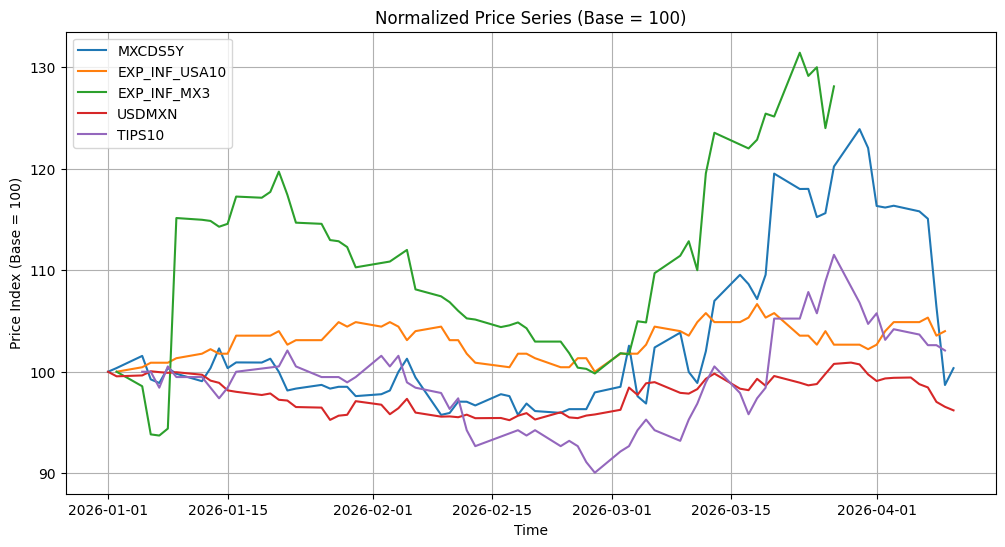

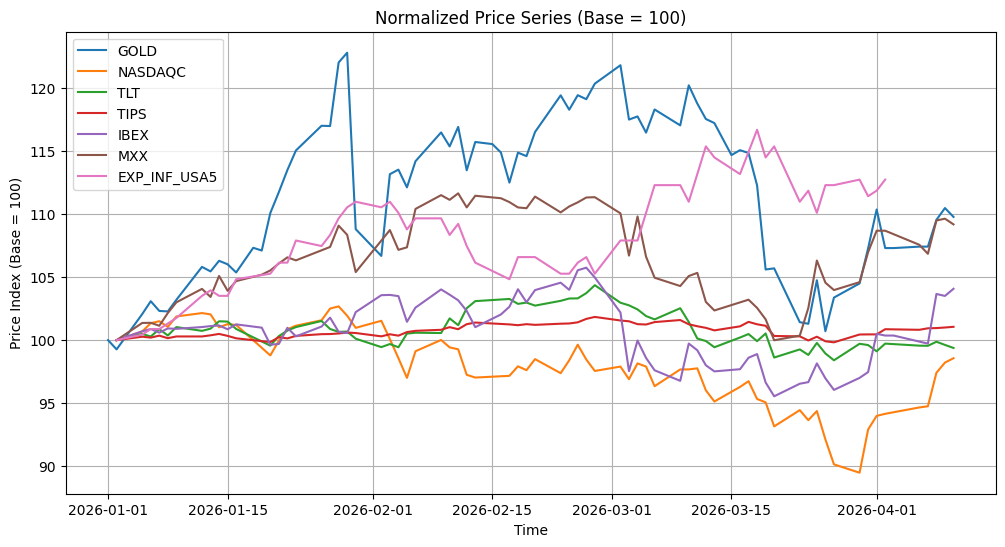

In [311]:
rics_up = ["MXCDS5Y", "EXP_INF_USA10", 'EXP_INF_MX3', 'USDMXN', 'TIPS10']

plot_normalized_timeseries(
    rics_up,
    from_date="2026-01-01",
    base_value=100
)
rics_down = ['GOLD', 'NASDAQC', 'TLT', 'TIPS', 'IBEX', 'MXX', 'EXP_INF_USA5']
plot_normalized_timeseries(
    rics_down,
    from_date="2026-01-01",
    base_value=100
)

observaciones martes trump acuerdo de paz
el dolar se vió impactado negativamente rapidamente
los riesgos por invetir en mexioc a 5 años se vieron imapctados positivamente bajando y rápidamente
el oro actuó lento, no hubo cambios grandes a comparaciond e lsoa tneriores
el nasdaq tuvo el mismo comportamiento que el oro, si creció pero no fue un boom como el reisgo por invertir en mexico
gcarso aprovechó el momento, es bien sabido que este tiene una alta correlacion visual... en cuanto el dolar se vea a la baja aprovecha y aumenta su valor rapidamente, en este caso si se observó esto
el ibex al momento si tuvo una reacción fuerte el dia de la noticia y por ende bbva su principal componente tambien, de hecho bbva matuvo la noticia positiva hasta el viernes
el mxx tambien el primer dia de la noticia

* los indices como mxx y ibex se mostraron solo el dia de la noticia muy positivamente
* empresas como bbva y gcarso mantuvieron positivamente ante la noticia hasta el viernes
* el riesgo en invertire en mexico fuertemente se vió impactado positivamente
* activos como el oro y nasdaq tomaron tambien la noticia positivamente, pero no fue un boom, el primer dia unicamente y de forma leve

* el precio de tips y el rendimiento yield de t bonds se mantuvo 'meh' (pero si siguió su tendencia esperada a la alza) ante la noticia,esto podria ser debido a que son VARIABLES MACRO, pertenecen al grupo de variables macro y al ser de largo plazo, las noticias actuales no tienen mucho impacto, sin embargo un monitoreo de su crecimiento o decrecimiento no esta de mas, ambas, cuando el dolar se ve depreciado SUBEN.

* en inflacion esperada a 10 años pasa lo mismo que el anterior punto, al ser una variable macro de largo plazo, horizonte a largo plazo... si bien afecta, pero muy poco o leve

PAARA EL PROYECTO AÑADIR ESTE ANALISIS Y HACER EL DE DECLARACION DE GUERRA A FINALES DE FEBRERO E INICIOS DE MARZO



22458236.924860477


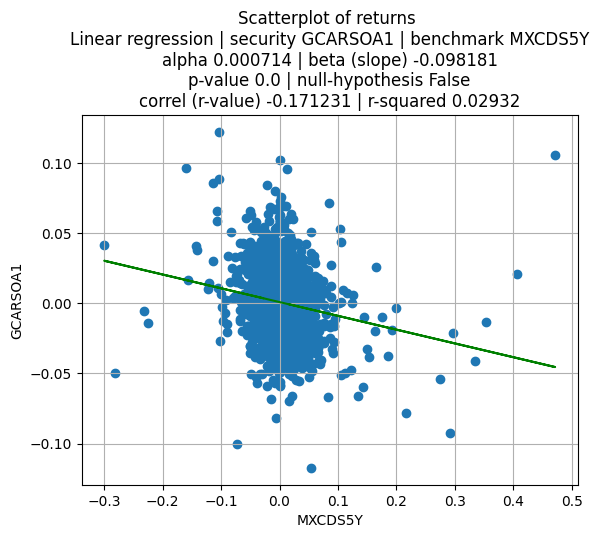

In [315]:
m = capm.model('GCARSOA1', 'MXCDS5Y', 6)
m.synchronise_timeseries()
m.compute_linear_reg(target_column='returns')
m.plot_linear_reg()
# MCO 
y_real = m.timeseries['close_y']
y_est = m.alpha + m.beta * m.timeseries['close_x']
mco = np.sum((y_real - y_est)**2)
print(mco)

544820068.4059432


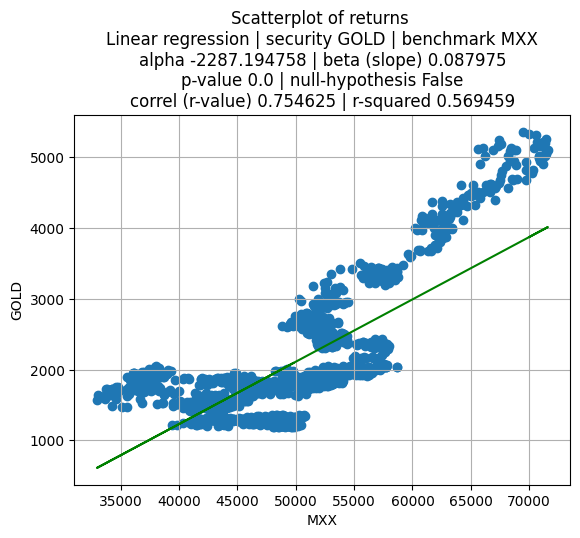

In [312]:
m = capm.model('GOLD', 'MXX', 6)
m.synchronise_timeseries()
m.compute_linear_reg(target_column='closing')
m.plot_linear_reg()
# MCO 
y_real = m.timeseries['close_y']
y_est = m.alpha + m.beta * m.timeseries['close_x']
mco = np.sum((y_real - y_est)**2)
print(mco)

0       0.38
1       0.35
2       0.34
3       0.38
4       0.38
        ... 
1964    1.52
1965    1.50
1966    1.40
1967    1.38
1968    1.42
Name: close_x, Length: 1969, dtype: float64
27773.04675129448


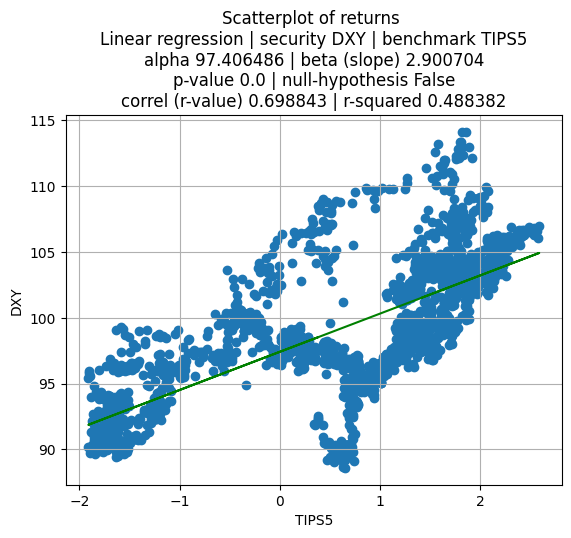

In [250]:
m = capm.model('DXY', 'TIPS5', 6) # dxy = int + b_1 * inf
m.synchronise_timeseries()
m.compute_linear_reg(target_column='closing')
m.plot_linear_reg()
# MCO 
y_real = m.timeseries['close_y']
y_est = m.alpha + m.beta * m.timeseries['close_x']
mco = np.sum((y_real - y_est)**2)
print(mco)


1859.5635191374083


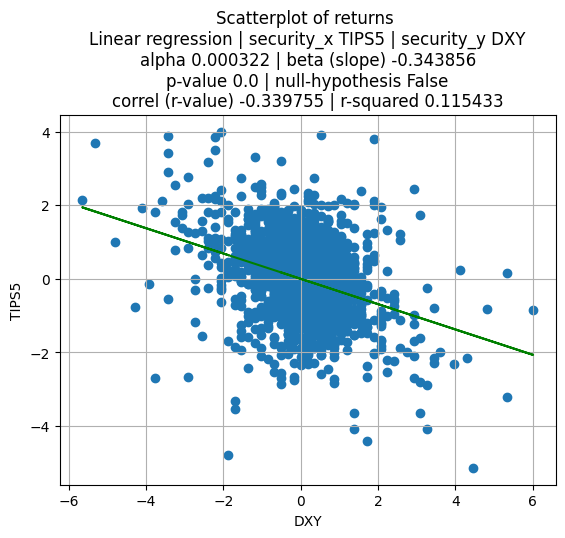

In [251]:
# MCO PERO CON NUEVA FUNCION ZSCORE
new = rrm.model('TIPS5', 'DXY', 6) # security vs benchmark
new.synchronise_timeseries()
new.compute_linear_reg()
new.plot_linear_reg()

# MCO 
y_real = new.timeseries['DXY']
y_est = new.alpha + new.beta * new.timeseries['TIPS5']
mco = np.sum((y_real - y_est)**2)
print(mco)

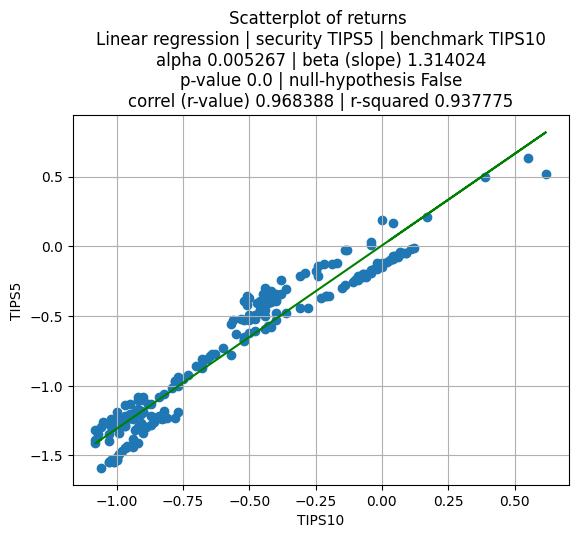

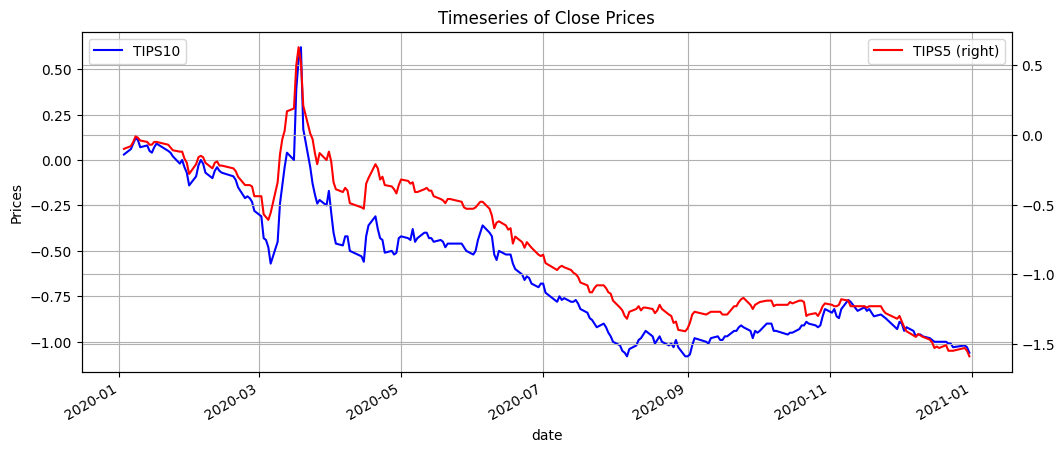

3.9625461108117106
<class 'numpy.float64'>
-0.1960918438277593
-0.9047033435598772
82.83505318939262


In [25]:
m = capm.model('TIPS5', 'TIPS10', 6)
m.synchronise_timeseries(from_date='2020-01-01', to_date='2020-12-31')
m.compute_linear_reg(target_column='closing')
m.plot_linear_reg()
m.plot_timeseries()

# MCO 
y_real = m.timeseries['close_y']
y_est = m.alpha + m.beta * m.timeseries['close_x']
mco = np.sum((y_real - y_est)**2)
print(mco)
# VS
sxx = np.sum(m.timeseries['close_x'] - np.mean(m.timeseries['close_x'])**2)
sxy = np.sum((m.timeseries['close_x'] - np.mean(m.timeseries['close_x'])) * (m.timeseries['close_y'] - np.mean(m.timeseries['close_y'])))

b_1 = sxy / sxx
print(b_1)
b_0 = np.mean(m.timeseries['close_y']) - b_1 * np.mean(m.timeseries['close_x'])
print(b_0)
y_est = b_0 + b_1 * m.timeseries['close_x']
mco_2 = np.sum((y_real - y_est)**2)
print(mco_2)

# Creando nuevas variables de análisis 
Spread entre bonos de MX y USA
INPC y CPI visto de 3 maneras... enero base, mes año t vs mes año t-1, variación mensual.

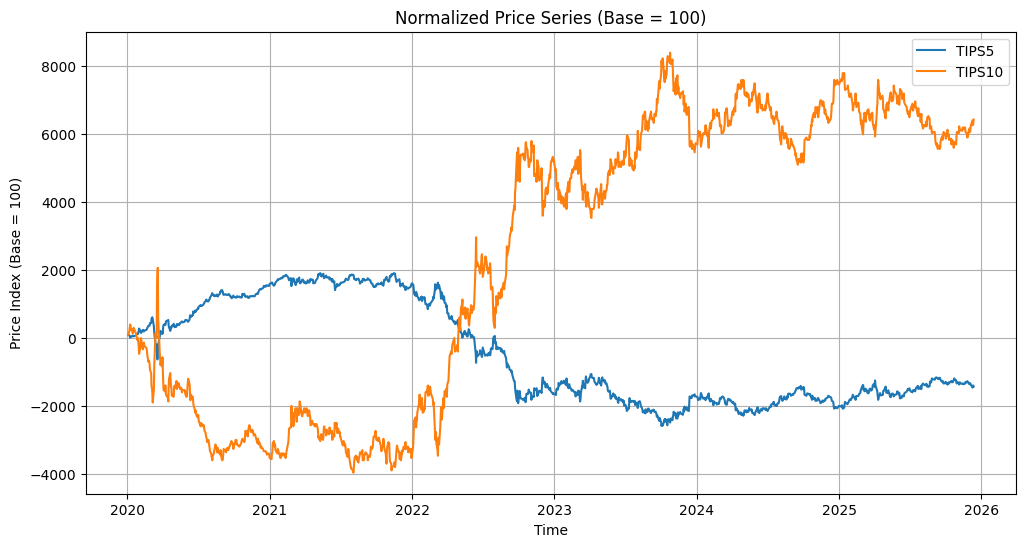

In [52]:
rics_up = ["TIPS5", "TIPS10"]

plot_normalized_timeseries(
    rics_up,
    from_date="2020-01-01",
    to_date='2025-12-12',
    base_value=100
)
# EN PANDEMIA SE COMPORTARON DIFERENTE A EPSAR DE QUE ESSTOS SUELEN TENER UNA CORRELACION CERCANA A 1 NORMALMENTE, SI TOMAMOS 2018 2016, ES CASI DE 1 

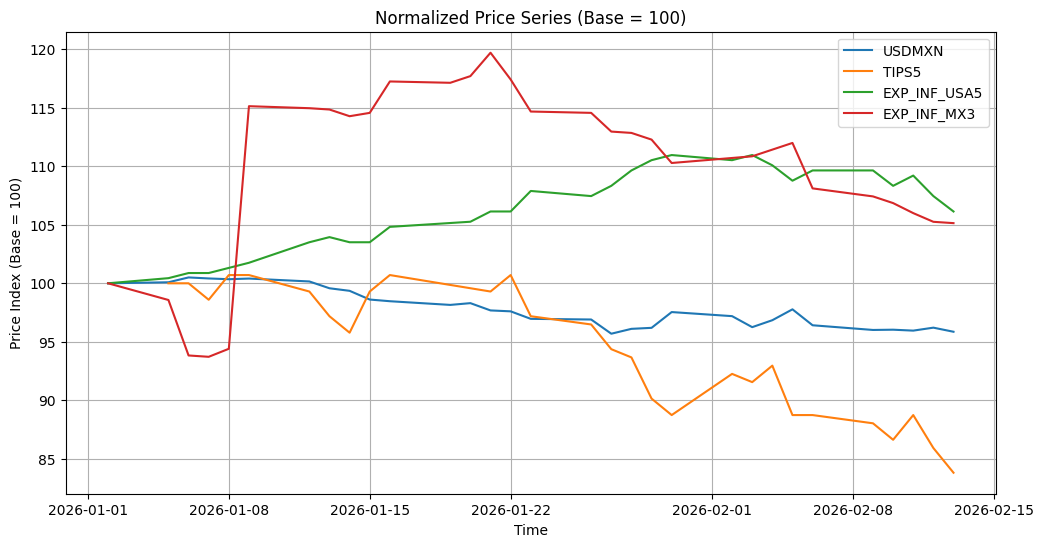

In [293]:
rics_up = ["USDMXN", "TIPS5", 'EXP_INF_USA5', 'EXP_INF_MX3']

plot_normalized_timeseries(
    rics_up,
    from_date="2026-01-02",
    to_date='2026-02-13',
    base_value=100
)

# LO CORRECTO, CAMBIAR TODO EL PROYECTO A ESTE ENFOQUE 

Lo que realmente encontraste es:
👉 co-movimiento en el tiempo, no necesariamente relación causal

🧠 Traducción simple
✔️ “se mueven juntos en ciertos periodos”
❌ “uno explica al otro de forma estable”
🔴 4. Sobre tu caso específico (lo que viste en la gráfica)
Lo puedes decir así:
✔️ Para DXY vs TIPS
“Se observa una relación positiva aparente, consistente con la intuición económica de que aumentos en tasas reales pueden estar asociados con apreciación del dólar.”
PERO:
“la presencia de clusters y posibles cambios de régimen sugiere que esta relación no es estable en el tiempo.”

Para USD/MXN vs TIPS
“Se identifica una relación negativa en niveles, consistente con episodios donde aumentos en tasas reales coinciden con fortalecimiento del dólar frente a monedas emergentes.”
PERO:
“la alta dispersión y estructura no lineal limitan la interpretación de esta relación como un vínculo estructural.”
🔥 5. La frase clave que te protege todo el proyecto
Si incluyes esto, estás blindado:
“Los resultados deben interpretarse como evidencia preliminar de co-movimientos, no como relaciones estructurales confirmadas.”

✅ 6. Conclusión final (honesta y correcta)
✔️ Sí encontraste algo real: co-movimientos
❌ No puedes afirmar: relación estable o causal
🔥 Estás en fase: descubrimiento, no confirmación

🧩 7. Insight final (muy importante)
Lo que hiciste es exactamente esto:
detectar dónde mirar… no explicar completamente lo que ves
Y eso:
👉 bien comunicado = totalmente válido académicamente



🔥 3. Ahora hagamos exactamente lo que propusiste (esto lo destruye)
Supongamos:
TIPS5 = 3
luego sube a 4
Entonces:
Caso 1: TIPS = 3
DXY
=
97.406
+
2.90
(
3
)
=
97.406
+
8.7
=
106.106
DXY=97.406+2.90(3)=97.406+8.7=106.106
Caso 2: TIPS = 4
DXY
=
97.406
+
2.90
(
4
)
=
97.406
+
11.6
=
109.006
DXY=97.406+2.90(4)=97.406+11.6=109.006
🔥 Interpretación del modelo
👉 El modelo dice:
“Si TIPS sube de 3% a 4%, el U.S. Dollar Index (DXY) sube ~3 puntos”
🚨 4. ¿Dónde está la inconsistencia?
Ahora compáralo con tu gráfica:
Hay puntos donde:
TIPS ≈ 1
DXY ≈ 110
Y otros donde:
TIPS ≈ 2
DXY ≈ 100
👉 Eso rompe completamente la relación lineal

# con respecto a lo de corto plazo, que se veía cierta linealidad y que podrian funcionar los modelos
🟡 2. La versión correcta (ajustada y profesional)
Puedes decir algo así:
“Durante periodos de estrés, como el episodio de COVID-19, se observa una relación más estrecha y aproximadamente lineal entre TIPS y el U.S. Dollar Index (DXY), consistente con un entorno dominado por shocks macroeconómicos comunes.”
🔥 Y agregas lo clave:
“Bajo estas condiciones, una regresión en niveles puede capturar co-movimientos de corto plazo; sin embargo, esta relación no es estable ni generalizable fuera de dicho régimen.”

# por cierto, usar un modelo de regesipon en el proyecto. hasta ahoria fue incorrecto, simplemente ocupabas correlacion de pearson, y ya, y linea de ajuste pero como visual, sin importancia como modelo, 

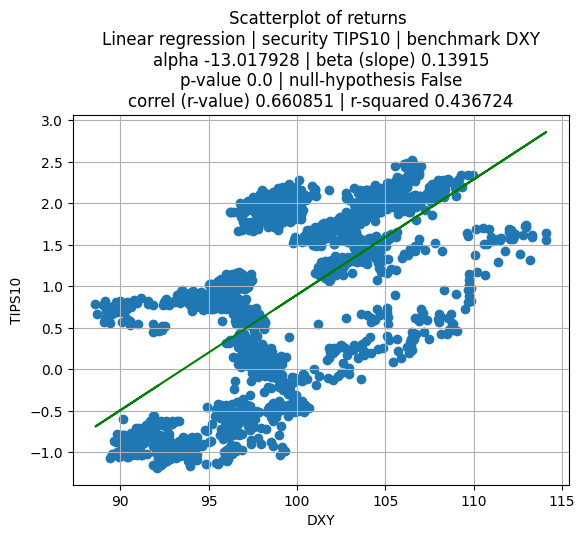

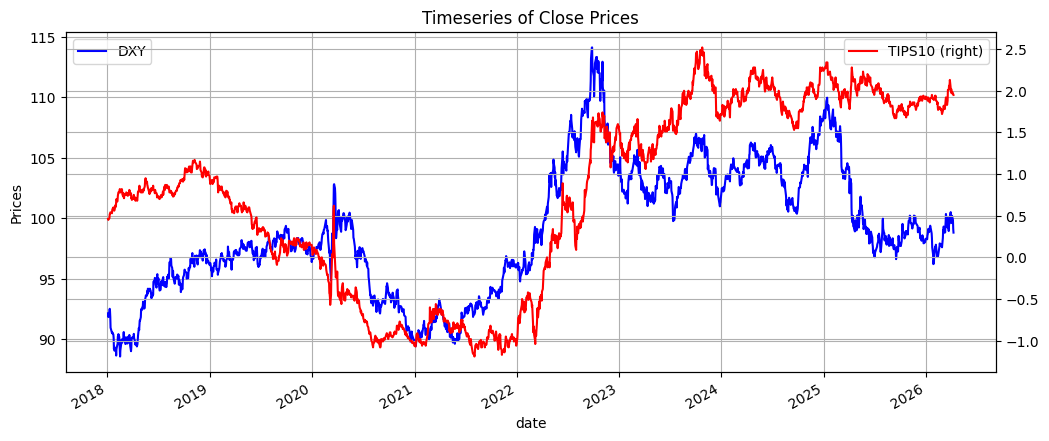

          Fecha       DXY  EXP_INF_MX10
0    2018-01-03  0.753501      0.550518
1    2018-01-04 -0.825282      0.658905
2    2018-01-05  0.252796     -0.099803
3    2018-01-08  1.068831      0.225357
4    2018-01-09  0.434853     -0.533351
...         ...       ...           ...
2020 2026-03-13  1.494309     -1.942381
2021 2026-03-17 -0.350790     -2.592702
2022 2026-03-18  1.253702      0.008584
2023 2026-03-19 -2.091279      0.008584
2024 2026-03-20  1.014024      1.417613

[2025 rows x 3 columns]
Valores Ajustados: 
 0      -0.193864
1      -0.237001
2      -0.223085
3      -0.166034
4      -0.142378
          ...   
1970    0.927685
1971    0.894289
1972    0.877591
1973    0.776011
1974    0.732875
Name: close_x, Length: 1975, dtype: float64
Residuos de Regresión lineal simple: 

Sxx:  54289.62233286076 = -660215.7627435476
Sxy:  7554.4030405063295
Syy:  2407.001270886076
MCO:  1355.8057966067904


In [320]:
model = capm.model('TIPS10', 'DXY', 6) # 'MXX', 'EXP_INF_MX10' 'TIPS5', 'TIPS10'
model.synchronise_timeseries()
model.compute_linear_reg('closing') # for capm class target_column='closing'
model.plot_linear_reg()
model.plot_timeseries()
print(modelo.timeseries)
# Definimos:
n = len(m.timeseries)
y_real = model.timeseries['close_y'] # 'close_y'
y_mean = np.mean(y_real)
b0 = model.alpha
b1 = model.beta
x = model.timeseries['close_x'] # 'close_x'
x_mean = np.mean(x)
y_predict = b0 + b1 * x
print('Valores Ajustados: \n', y_predict)
residuos = y_real - y_predict
print('Residuos de Regresión lineal simple: \n', )
sxx = np.sum((x - x_mean)*(x - x_mean))
sxx_2 = np.sum(x**2) - n * x_mean**2
print('Sxx: ', sxx, '=', sxx_2)
sxy = np.sum((x - x_mean)*(y_real - y_mean))
print('Sxy: ', sxy)
syy = np.sum((y_real - y_mean)*(y_real - y_mean))
print('Syy: ', syy)
print('MCO: ', np.sum(residuos**2))



In [321]:
# Mínimos Cuadrados Ordinarios 
b1_mco = sxy/sxx
print('Estimador B1 por MCO: ', b1_mco)
b0_mco = y_mean - b1_mco*x_mean
print('Estimador B0 por MCO: ', b0_mco)
y_hat_mco = b0_mco + b1_mco*x
residuos_mco = y_real - y_hat_mco
print('MCO: ', np.sum((residuos_mco)**2))

varianza_mco = np.sum((residuos_mco)**2)/(n-2)
print('Estimador varianza MCO: ', varianza_mco)

var_b0 = ((1/n) + (x_mean**2)/sxx)*varianza_mco
print('Varianza de b0: ', var_b0)

var_b1 = varianza_mco/sxx
print('Varianza de b1: ', var_b1)



Estimador B1 por MCO:  0.13915003855043864
Estimador B0 por MCO:  -13.01792774859536
MCO:  1355.8057965740695
Estimador varianza MCO:  0.6626616796549705
Varianza de b0:  0.11979324039204864
Varianza de b1:  1.2206046960357477e-05


In [ ]:
# INTERCEPTO = 0 PENDIENTE

In [46]:
# ERROES... NORMALES - MV

In [323]:
# INTERVALOS DE CONFIANZA

from scipy.stats import t

df = n - 2
alpha = 0.05
t_crit = t.ppf(1 - alpha/2, df)

varianza = np.sum(residuos**2)/(n-2) # Del modelo inicialmente calculado
print('Varianza del modelo de python: ', varianza, 'vs varianza mco manual: ', varianza_mco)
var_b0 = ((1/n) + x_mean**2 / sxx)*varianza
var_b1 = varianza/sxx

intervalo_b0 = (b0 + t_crit * np.sqrt(var_b0), b0 - t_crit*np.sqrt(var_b0))
print('Intervalo para b0:', intervalo_b0)
print('b0 del modelo de python: ', b0)

intervalo_b1 = (b1 + t_crit * np.sqrt(var_b1),b1+t_crit*np.sqrt(var_b1))
print('Intervalo para b1:', intervalo_b1)
print('b1 del modelo de python: ', b1)

# varianza

# mu_x = E[Y|X = x_star]
# mu_hat_x
x_star = 96  # # por ejemplo, un valor de X
y_hat_x = b0 + b1 * x_star # ¿Qué valor podría tomar TIPS5 cuando TIPS10 = 2.0?” calculas la media estimada... E[Y|X=x*] = E(b_0) + E(b_1) * x_star = b0 + b1*x
# Entonces y_hat_x = mu_hat_x PERO mu_x es DIFERENTE a Y_x real
var_mu_x = varianza * (1/n + ((x_star - x_mean)**2) / sxx)

intervalo_mean = (y_hat_x - t_crit * np.sqrt(var_mu_x),
    y_hat_x + t_crit * np.sqrt(var_mu_x))
print('¿Cuál es la media esperada  de Y (la media de Y es el valor ajustado) cuando X = ',x_star,'?”: ', y_hat_x)
print('Intervalo donde está mi media media real = mu_hat_x + error de estimación:', intervalo_mean)

# Entonces y_hat_x = mu_hat_x ENTONCES mu_hat_x + error de estiimación = mu_x + ruido real (Epsilon) = Y_x
# Y_x - INCLUYE ruido real (epsilon) por eso es más ancho

4# y_hat_x 
var_pred = varianza * (1 + 1/n + ((x_star - x_mean)**2) / sxx)

intervalo_pred = ( y_hat_x - t_crit * np.sqrt(var_pred),
    y_hat_x + t_crit * np.sqrt(var_pred))
print('Intervalo para Y_x - ¿Dónde caerá un valor real Y_x:', intervalo_pred)
print('Con 95% de confianza, un nuevo valor real de Y caerá dentro de este intervalo, dado que X = x*')
print('y_hat bajo x*: ', y_hat_x, ' con x* = ', x_star)


Varianza del modelo de python:  0.662661679670963 vs varianza mco manual:  0.6626616796549705
Intervalo para b0: (np.float64(-12.339160188526762), np.float64(-13.696695811473237))
b0 del modelo de python:  -13.017928
Intervalo para b1: (np.float64(0.14600160946944515), np.float64(0.14600160946944515))
b1 del modelo de python:  0.13915
¿Cuál es la media esperada  de Y (la media de Y es el valor ajustado) cuando X =  96 ?”:  0.3404720000000001
Intervalo donde está mi media media real = mu_hat_x + error de estimación: (np.float64(0.2998729404513839), np.float64(0.3810710595486163))
Intervalo para Y_x - ¿Dónde caerá un valor real Y_x: (np.float64(-1.2564783122425125), np.float64(1.9374223122425127))
Con 95% de confianza, un nuevo valor real de Y caerá dentro de este intervalo, dado que X = x*
y_hat bajo x*:  0.3404720000000001  con x* =  96


In [108]:
# Pruebas de hipótesis
# PRUEBA PARA B0 CON STUDENT
df = n-2
b0_prueba = 0
t_star_b0 = (b0 - b0_prueba) / np.sqrt(varianza * (1/n + (x_mean**2/sxx)))
print('T test - t* de b0: ', t_star_b0)
print('B0 predicted: ', b0)
# Región de rechazo
if abs(t_star_b0) > t.ppf(1 - alpha/2, df):
    print('Se rechaza H0 (B0 = ',b0_prueba ,') tq b0 es diferente de ', b0_prueba)
else:
    print('Se acepta H0')
if t_star_b0 > t.ppf(1 - alpha, df):
    print('Se rechaza H0 (B0 <= ',b0_prueba ,') tq b0 es > a ', b0_prueba)
elif t_star_b0 < t.ppf(1 - alpha, df):
    print('Se rechaza H0 (B0 >= ',b0_prueba ,') tq b0 es < a ', b0_prueba)


T test - t* de b0:  25.359691411954863
B0 predicted:  37436.376372
Se rechaza H0 (B0 =  0 ) tq b0 es diferente de  0
Se rechaza H0 (B0 <=  0 ) tq b0 es > a  0


In [112]:
# PRUEBA PARA B1 CON STUDENT
df = n-2
b1_prueba = 0
t_star_b1 = (b1 - b1_prueba) / np.sqrt(varianza / sxx)
print('T test - t* de b1: ', t_star_b1)
print('B1 predicted: ', b1)
# Región de rechazo
if abs(t_star_b1) > t.ppf(1 - alpha/2, df):
    print('Se rechaza H0 (B1 = ',b1_prueba ,') tq b1 es diferente de ', b1_prueba, 'ya que', abs(t_star_b1), '>',  t.ppf(1 - alpha/2, df))
if t_star_b1 > t.ppf(1 - alpha, df):
    print('Se rechaza H0 (B1 <= ',b1_prueba ,') tq b1 es > a ', b1_prueba)
elif t_star_b1 < t.ppf(1 - alpha, df):
    print('Se rechaza H0 (B1 >= ',b1_prueba ,') tq b0 es < a ', b1_prueba)

T test - t* de b1:  11.68734363835162
B1 predicted:  2603.853267
Se rechaza H0 (B1 =  0 ) tq b1 es diferente de  0 ya que 11.68734363835162 > 1.9699815295289813
Se rechaza H0 (B1 <=  0 ) tq b1 es > a  0


In [ ]:
# PRUEBA PARA B1 CON CHI SQUARE


In [113]:
# ANOVA
sc_total = np.sum((y_real - y_mean)**2)
sc_reg = np.sum((y_predict - y_mean)**2) # 1 grado
sc_reg_eq = b1 * sxy # Demostrar***
print('SC reg manual: ', sc_reg, ' vs CS reg equivalencia: ', sc_reg_eq)

sc_error = np.sum((y_real - y_predict)**2) # n-2 grado
sc_error_eq = sc_total - b1*sxy # dado que total = reg + error entonces error = total - reg 
print('SC error: ', sc_error, ' vs CS error equivalencia: ', sc_error_eq)

# Relación 
sc_total_rel = sc_reg + sc_error
print('SC total manual: ', sc_total, ' vs CS total relation: ', sc_total_rel)

SC reg manual:  35840685350.26668  vs CS reg equivalencia:  35840685354.31247
SC error:  62448445984.993385  vs CS error equivalencia:  62448445989.039185
SC total manual:  98289131343.35165  vs CS total relation:  98289131335.26007


In [117]:
# CM
# Regresión
cm_reg = sc_reg
print('CM de la regresión es: ', cm_reg, 'equivalente a su SC: ', sc_reg)

# Eror
cm_error = sc_error/(n-2)
print('CM del error es: ', cm_error)

# CON EL CM CALCULAMOS LA F PRUEBA
# qué tanto explica el modelo (señal) vs qué tanto queda como ruido
f = cm_reg/cm_error
print('Prueba F con valor: ', f)

# CON EL SIMPLE VALOR DE F NO PUEDES COMPARAR MODELOS, NECESITAS R2 TAMBIEN Y TENER ENCUENTA:

# P VALUE
# Hipótesis: H0 - todos los coeficientes (excepto intercepto) = 0
# H1: al menos uno diferente de 0
# P value mas cercano a 0 mas ridículo H0

from scipy import stats

k=1 # Número de variables explicativas, menos intercepto
df1 = k 
df2 = n - k - 1  # grados de libertad del error

p_value = 1 - stats.f.cdf(f, df1, df2)

print(p_value)





CM de la regresión es:  35840685350.26668 equivalente a su SC:  35840685350.26668
CM del error es:  262388428.50837556
Prueba F con valor:  136.59400132091812
1.1102230246251565e-16


Cuando un modelo es sospechoso revisar la suma de errores al cuadrado... con los beta dados por el modelo estos deberían de ser cercanos a 0 FALSO, y revisar intervlao de confianza de Y_x POSIBLE

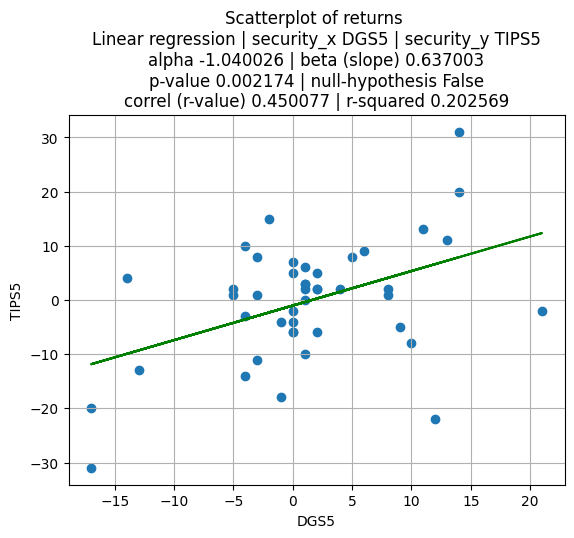

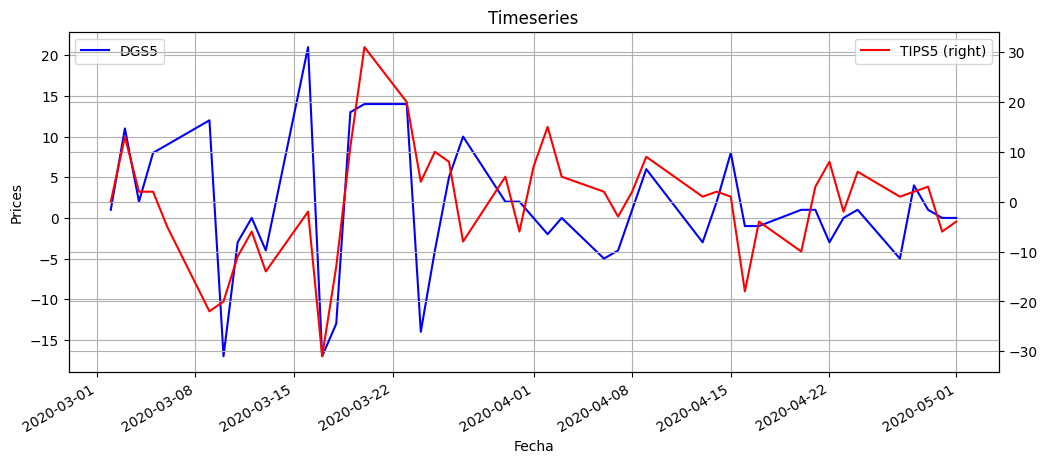

In [5]:
model = rrm.model('DGS5', 'TIPS5', 6) # 'MXX', 'EXP_INF_MX10' 'TIPS5', 'TIPS10'
model.synchronise_timeseries(from_date='2020-03-01', to_date='2020-05-01')
model.compute_linear_reg() # for capm class target_column='closing'
model.plot_linear_reg()
model.plot_timeseries()